# Lesson134 · Training at scale: budget a temporal mini-batch

Student lab · Three live functions, real measured evidence, visible full trainer.

In [ ]:
# @colab-bootstrap: install missing dependencies; report actual versions.
import importlib.util,importlib.metadata,subprocess,sys
required={'numpy':'numpy','pandas':'pandas','pyarrow':'pyarrow','torch':'torch','torch_frame':'pytorch-frame==0.2.3','torch_geometric':'torch-geometric==2.6.1','relbench':'relbench==1.1.0','pooch':'pooch'}
missing=[package for module,package in required.items() if importlib.util.find_spec(module) is None]
if missing:subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Actual notebook runtime:',sys.version)
print({k:importlib.metadata.version(k) for k in ['numpy','pandas','torch','pytorch-frame','torch-geometric','relbench']})


In [ ]:
import math,json,hashlib,importlib.metadata
from pathlib import Path
import numpy as np
import torch
torch.set_num_threads(1)

<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Where this lesson fits">
<p class="sequence-eyebrow">From Lesson 133 to this lesson</p>
<p>The layer equation is fixed. Scaling decides which query-owned occurrences reach it and measures the resulting computation.</p>
<details><summary>Quick prerequisite reminder</summary><p>Throughput is completed queries divided by elapsed time. GPU allocated memory tracks live tensors; reserved memory also includes allocator-held space. Fanout gives an expansion bound, not measured memory.</p></details>
</aside>
<!-- sequence-review:end -->

<p class="stream-lead">A graph can have millions of rows while one training step touches thousands. The hard part is controlling which thousands—and measuring the cost without changing the question.</p>

**Your win:** configure a temporal heterogeneous mini-batch, prove that its messages belong to the right prediction query, and defend a measured throughput/memory trade-off.

**Route:** 5 minutes of retrieval → 15 minutes tracing a batch → 20 minutes of live code → 10 minutes defending the measurements. The full reproduction is an author/reference experiment; executing it is optional and does not replace your answers.

[Student notebook](https://avistian.github.io/relational/labs/0134-training-at-scale.ipynb) · [Executed reference](https://avistian.github.io/relational/labs/html/0134-training-at-scale.html) · [Solution notebook](https://avistian.github.io/relational/labs/solutions/0134-training-at-scale.ipynb) · [Quick reference](https://avistian.github.io/relational/reference/training-at-scale.html) · [Reproduction commands](https://avistian.github.io/relational/labs/l134-reproduction.md)



## 1 · The layer is defined. Its input still needs a budget.

In [Lesson 133](https://avistian.github.io/relational/lessons/0133-hetero-conv-reg.html), you opened the relation-specific transforms and the sum across incoming relations. Applying that layer to the whole database at once is unnecessary for seed-query supervision. We can first select the context required by a small set of predictions, then run the same message-passing computation on the sampled coordinates. This is the bridge from correct layer arithmetic to the mission's practical question: can a relational model deliver evidence within our compute budget?



<details><summary>Check your retrieval</summary>A prediction is keyed by entity and cutoff. Two queries can refer to one entity at different times, requiring different neighborhoods; disjoint temporal sampling keeps their occurrences separate. The head's first B seed outputs receive the B query labels. Context rows provide messages but are not extra labelled examples.</details>

The primary reading is the [RelBench v1 paper, §4 and Appendix B](https://arxiv.org/html/2407.20060v1), followed by the [pinned released loader configuration](https://github.com/snap-stanford/relbench/blob/9aa346267c2e1c560bd92da07d6f4ad1ca2f0639/examples/gnn_node.py). This lesson preserves that release's inclusive node-time cutoff and uniform strategy. A stricter deployment rule is a different experiment.



## 2 · Trace one batch from query to optimizer

<figure class="stream-figure" tabindex="0">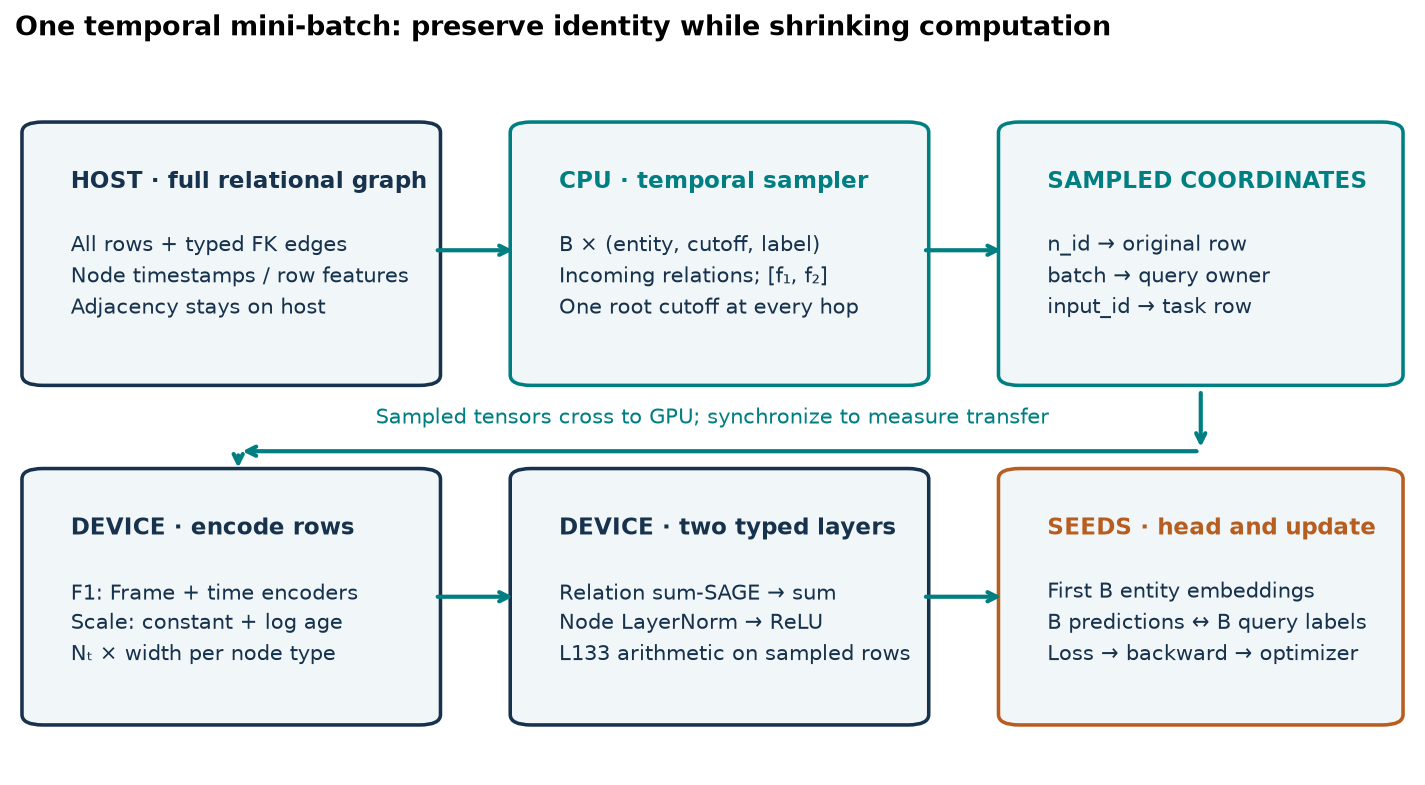<figcaption>From full host graph to query-owned sampled coordinates, encoded occurrences, typed layers and seed-only loss.</figcaption></figure>

**Diagram trace.** Follow the CPU-to-GPU handoff. Match n_id, batch and input_id to their separate identities before tracing the seed-only loss. On a narrow screen, scroll the figure sideways.

The full graph's adjacency and stored row features live on the host. A seed row contributes an **entity ID, query time, and label**. `NeighborLoader` follows incoming typed edges, filters candidates using that query's cutoff, and samples up to the fanout for each relation at each hop. `n_id` maps sampled coordinates back to database rows. `batch` identifies the query owning each occurrence; it is not a table ID. `input_id` identifies the original task row, so labels remain correct even when seeds repeat or shuffle. PyG's temporal sampler automatically uses disjoint sampling. [PyG 2.6.1 source](https://github.com/pyg-team/pytorch_geometric/blob/2.6.1/torch_geometric/sampler/neighbor_sampler.py)

The sampled features move to the device. The model encodes those rows, adds relative-time information, applies two heterogeneous layers, and predicts only the first B rows of the entity table. Backpropagation traverses this sampled computation. Increasing fanout changes the model's information and its training trajectory; it is not merely a speed switch.

**Trace:** Query 0 is `(user 7, day 5)` and query 1 is `(user 7, day 10)`. A post created on day 8 can occur only in the second context. Deduplicating user 7 across queries without preserving context ownership would mix two different prediction problems.



## 3 · Fanout multiplies along paths and across relations

For one relation and two hops, the no-collision expansion is `B × (1 + f₁ + f₁f₂)` node occurrences. A heterogeneous schema can expand through several incoming relations at every hop. You must follow the schema, not multiply a homogeneous formula by the total number of relations.

Consider `orders → users`, `items → orders`, and `users → orders`. Starting with B=2 user queries and fanouts [3,2], the typed frontiers contain 2 users, then 6 orders, then 12 items plus 12 users: **32 occurrences and at most 30 sampled edges**. Actual counts can be smaller because of degree limits, time filtering and shared nodes within a query. Occurrences across different queries remain separate.

<figure class="stream-figure" tabindex="0">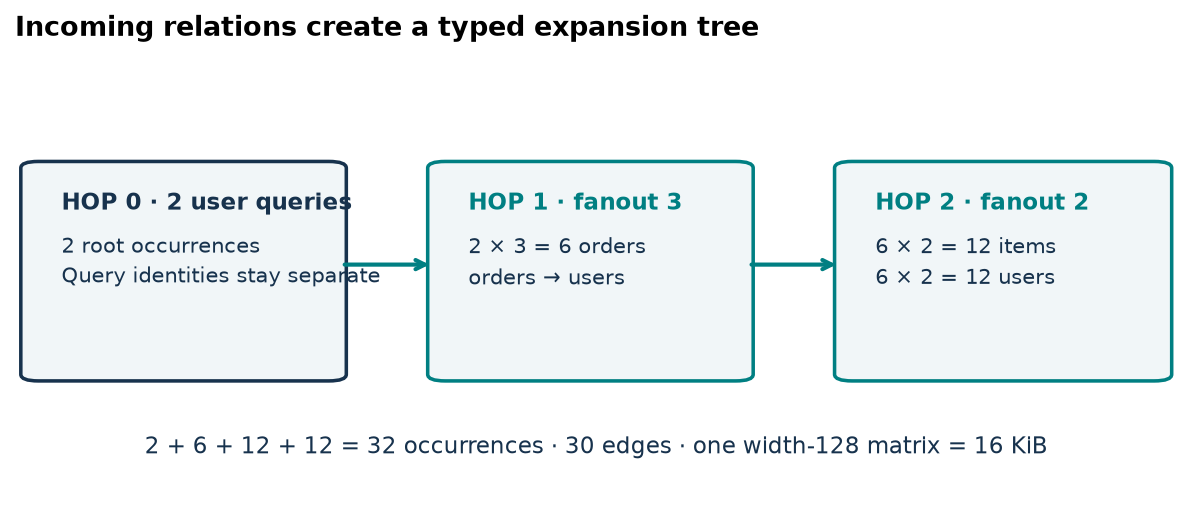<figcaption>A typed no-collision expansion counts 32 occurrences and 30 edges; it is not measured peak memory.</figcaption></figure>
Baseline B=2, fanouts=[3,2]: 32 occurrences, 30 edges, 16 KiB for one width-128 float32 matrix. With B=4 and fanouts=[2,3]: 60 occurrences, 56 edges, 30 KiB.

**TODO 1:** implement the schema-aware bound. The function below counts an incoming relation once for each receiving occurrence. It assumes finite nonnegative fanouts and directional neighbor expansion; `-1` means all neighbors and has no finite fanout-only bound.

Implement this contract in the TODO cell below.

A float32 hidden matrix costs `4 × N × width` bytes. That is one tensor, not peak GPU memory. Layer activations, relation outputs, gradients, optimizer state, indices, allocator reservations and transient workspace also count. Host adjacency, sampler CSC conversion and text preprocessing have separate costs. A lower bound on one matrix is not an OOM guarantee.



In [ ]:
def frontier_bound(schema, seed_type, batch_size, fanouts):
    raise NotImplementedError("TODO: frontier_bound")

In [ ]:
def check_bound(fn):
    schema=[('orders','by','users'),('items','in','orders'),('users','rev','orders')]
    r=fn(schema,'users',2,[3,2])
    assert r['frontiers']==[{'users':2},{'orders':6},{'items':12,'users':12}]
    assert r['node_occurrences']==32 and r['edge_occurrences']==30
    assert fn(schema,'users',2,[0,2])['node_occurrences']==2
    try:fn(schema,'users',2,[-1])
    except ValueError:pass
    else:raise AssertionError('All-neighbor sentinel cannot be a finite bound')
check_bound(frontier_bound)
print("PASS: frontier_bound")

## 4 · Sampling is an information contract

**TODO 2:** reject a dated node newer than its own root cutoff and any edge joining occurrences owned by different queries. Equality passes because the released experiment uses `node_time ≤ query_time`. A static table with no timestamp is marked explicitly; this does not establish historical availability.

Implement this contract in the TODO cell below.

Our author runs also compare sampled node times and edges to their original global identities. A batch can satisfy `time ≤ cutoff` while holding the wrong timestamp or foreign-key edge. These checks complement the learner's ownership check rather than replace it. The same learner function runs against the real F1 and scale batches.

**Units are part of the contract.** The archive and task timestamps were probed and both use nanoseconds. The operator nevertheless explicitly converts both to `datetime64[s]` before taking integer counts; it does not assume all future archives use the same raw integer unit. A four-unit regression checks seconds, milliseconds, microseconds and nanoseconds.

**Predict:** if a day-8 post belongs to query 1, should an edge from that occurrence to query 0's user pass? It must fail even though day 8 is earlier than query 1's cutoff. Both endpoints of a message must belong to one prediction context. This extends [Lesson 123's temporal graph](https://avistian.github.io/relational/lessons/0123-temporal-heterogeneous-graphs.html) contract into the sampled coordinates used by training.



In [ ]:
def audit_queries(times, owners, cutoffs, edges):
    raise NotImplementedError("TODO: audit_queries")

In [ ]:
def check_audit(fn):
    times={'u':[1,1],'v':[4,8]};owners={'u':[0,1],'v':[0,1]}
    edges=[('v','u',[[0,1],[0,1]])]
    assert fn(times,owners,[5,10],edges)['nodes']==4
    for t,o,e in [({'u':[1,1],'v':[6,8]},owners,edges),(times,owners,[('v','u',[[1],[0]])]),(times,{'u':[0,2],'v':[0,1]},edges)]:
        try:fn(t,o,[5,10],e)
        except ValueError:pass
        else:raise AssertionError('Future node or mixed query accepted')
    assert fn({'u':[5]}, {'u':[0]}, [5], [])['nodes']==1
check_audit(audit_queries)
print("PASS: audit_queries")

## 5 · Measure the pipeline you actually run

GPU operations are asynchronous. Wall-clock timing around a forward call without synchronization can measure enqueue time. The scale operator synchronizes before and after device transfer and the combined forward/backward/optimizer step. It reports loader construction, warmups and audit time separately. It uses one loader worker, no prefetch workers, and a fixed order; this is a reproducible baseline, not a claim of maximal throughput. [PyTorch CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html#asynchronous-execution)

**TODO 3:** aggregate throughput as total seed queries divided by total measured seconds. Do not average per-batch rates: small final batches and unequal durations make that biased. Return both a core rate (sample + transfer + step) and an audit-inclusive rate. Peak allocated memory measures live tensor allocations; peak reserved memory includes the CUDA caching allocator's pool. Neither is total process GPU usage.

Implement this contract in the TODO cell below.

**Predict:** if sampling takes 0.8 seconds and device work takes 0.2 seconds, making device work twice as fast changes a one-second batch to 0.9 seconds—only about an 11% throughput gain. First measure which stage dominates.



In [ ]:
def profile_summary(records):
    raise NotImplementedError("TODO: profile_summary")

In [ ]:
def check_summary(fn):
    rows=[dict(queries=2,sample_s=1.,transfer_s=0.,step_s=1.,audit_s=9.,peak_allocated_bytes=100,peak_reserved_bytes=200),dict(queries=6,sample_s=1.,transfer_s=0.,step_s=3.,audit_s=9.,peak_allocated_bytes=120,peak_reserved_bytes=256)]
    r=fn(rows)
    assert r['queries']==8 and math.isclose(r['queries_per_second'],8/6) and r['peak_allocated_bytes']==120
    assert math.isclose(r['audited_queries_per_second'],8/24)
    try:fn([])
    except ValueError:pass
    else:raise AssertionError('Empty timing accepted')
check_summary(profile_summary)
print("PASS: profile_summary")

## 6 · Two experiments, two claims

The **F1 lane** freshly executes five complete ten-epoch fits of RelBench v1 Table 7, `rel-f1/driver-position`, using the full released data and pinned model/trainer. It independently rescores every final prediction and checks selected outputs against the original model. The paper target is validation MAE 3.193 and test MAE 4.022; the predeclared descriptive tolerance is 0.2 on each mean. The full experiment's implementation is visible in the notebook appendix, including row encoders, graph construction, trainer and selection.

The **scale lane** retains all `rel-stack` rows through the released test cap and all resolvable foreign-key edges, with real `user-engagement` labels reconstructed by the original SQL on that same pinned archive. It deliberately replaces rich row encoders with constant-plus-log-age features and a width-32 two-layer heterogeneous predictor. It runs BCE training on the same label-blind set of 2,048 eligible task rows (one released training cutoff, roots created by that cutoff, ascending entity ID) under three fixed batch/fanout configurations. Two warmup batches perform updates before each measured pass. These are bounded training workloads, not complete epochs over the task or a reproduced benchmark score. Fixed initialization does not make different minibatch partitions equivalent optimization trajectories.

**F1 full selected released-protocol reproduction: COMPLETE.**

| Split | MAE mean ± sample seed SD | Published mean | Verdict |
|---|---:|---:|---|
| val | 3.181779 ± 0.014839 | 3.193 | CLOSE |
| test | 4.003968 ± 0.157440 | 4.022 | CLOSE |

All **6,295** final predictions independently rescored; **403,895** query occurrences audited across training and evaluation. Original-model replay maximum difference: 2.86e-06. [F1 evidence](https://avistian.github.io/relational/labs/evidence/l134/summary.json).

**Scale workload: COMPLETE.** Full graph: **4,247,264 nodes**, **11,625,774 directed edges**. Each measured configuration covers the same **2,048 queries** after two warmup update batches.

| Batch / fanouts | Mean sampled nodes | Core queries/s | With audit queries/s | Peak allocated MiB | Peak reserved MiB |
|---|---:|---:|---:|---:|---:|
| 64 / [8, 4] | 3066.5 | 2198.2 | 1956.7 | 25.0 | 30.0 |
| 64 / [16, 8] | 4913.3 | 2148.9 | 1891.3 | 30.6 | 36.0 |
| 128 / [16, 8] | 9687.3 | 4076.4 | 3479.6 | 42.2 | 48.0 |

Preprocessing: **17.01 s**. Peak process host RSS: **5639.8 MiB**, distinct from GPU memory. Measured on **Tesla T4**. Loader construction and warmups are retained in the raw evidence.

[Raw scale measurements](https://avistian.github.io/relational/labs/evidence/l134/scale/scale.json). The official database endpoint served bytes differing from the historical registry: the first attempt stopped before training, and the recovery pins the obtained SHA256. This scale lane uses that pinned official archive; historical database identity is NOT_ESTABLISHED. F1 archives match their expected hashes.

**Portable full-training path: PASS.** All 22 notebook code cells ran in a separate pinned GPU Python namespace, including five fresh complete F1 fits and another 6,295 independently checked predictions. These are validation runs, not replacements for the primary five-seed result. Live Colab frontend remains NOT_CHECKED. [GPU code-path evidence](https://avistian.github.io/relational/labs/_notebook_gpu_l134_results.json).

<figure class="stream-figure" tabindex="0">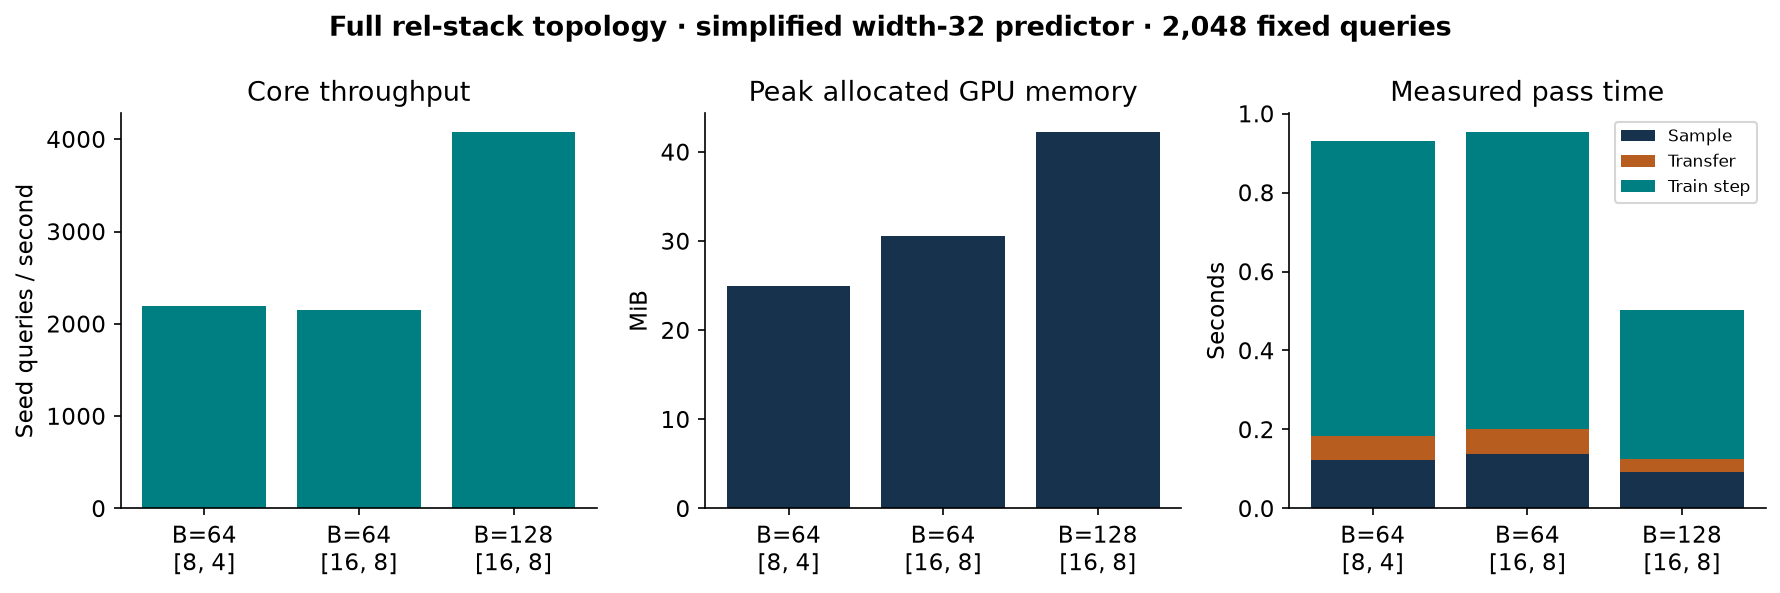<figcaption>Measured full-topology scale workload with simplified features; sampling, transfer and optimizer step are timed separately.</figcaption></figure>
<figure class="stream-figure" tabindex="0">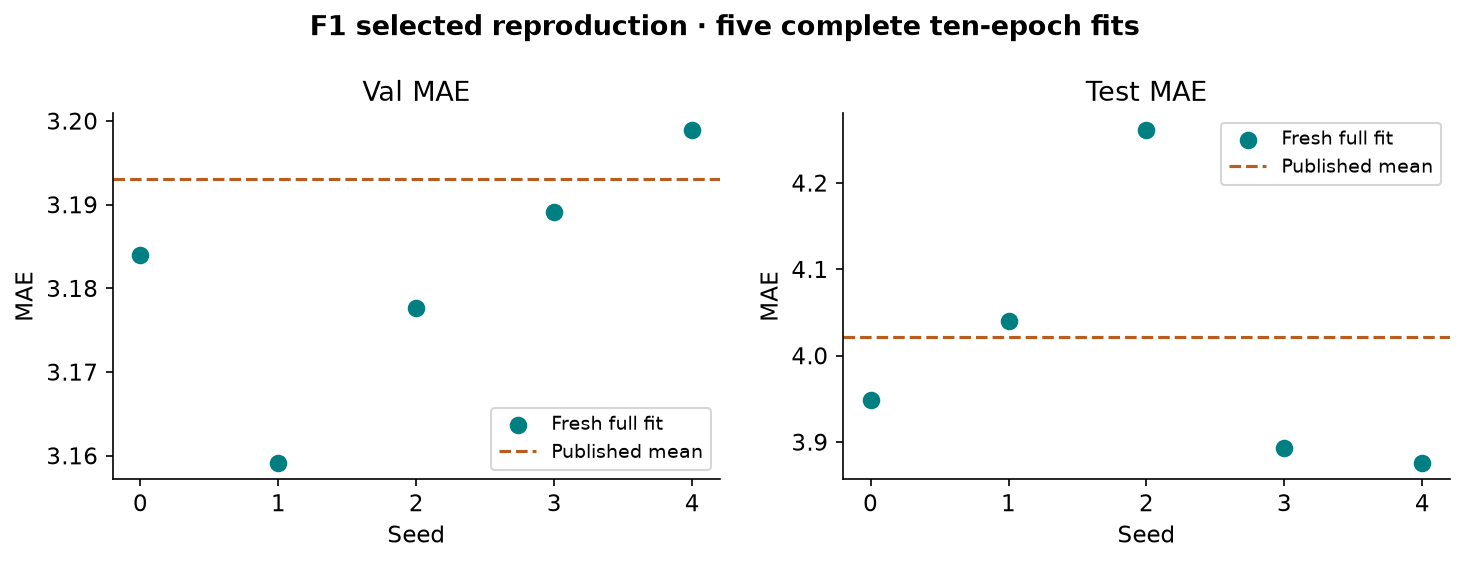<figcaption>Five fresh complete F1 runs against published means. Sample seed variability is not a confidence interval.</figcaption></figure>

**Interpret before looking at throughput:** the graph census describes database scale; sampled occurrence counts describe per-step computation. The prefix, small features, warmup updates, single measurement pass and configuration order limit generalization to other queries and full models. We report descriptive timings, not confidence intervals or a winning hyperparameter. No timing-to-accuracy claim follows.



## 7 · Make scale fit a scientific budget

Our total cap is **USD10** including seeds, retries and validation. We reserved USD2 for F1/validation, USD5 for the scale lane and USD3 for overhead/recovery. At the checked base prices, T4 + two CPU cores + 32 GiB is approximately USD0.940464/hour. The runner reserves maximum worker time before dispatch and disables automatic retries. A pilot informs whether to dispatch the full F1 set. [Current price source](https://modal.com/pricing)

A stopped or shortened run retains its actual status. It cannot be turned into a full reproduction by extrapolating its speed or quoting another lesson's scores. The release's statistics use the database through the test cap, historical seeds/runtime are unavailable, and ingestion histories are missing. We preserve those facts in the [protocol ledger](https://avistian.github.io/relational/labs/l134-reproduction.md). Whole-paper parity and historical identity remain NOT_ESTABLISHED.



## EXIT · Defend a batch, not just a score

1. For B=4 and fanouts [2,3] on the widget's schema, derive every typed frontier and the one-matrix float32 storage at width 128. Explain why it is not peak memory.
2. Draw the duplicated user-7 contexts at days 5 and 10. Mark a cross-query edge that the audit must reject, and name one real-world leakage risk the timestamp check cannot resolve.
3. From the measured table, choose a configuration for a stated memory ceiling and explain the dominant time component. Distinguish the measurements from a claim about accuracy or whole-task runtime.
4. State precisely what was fully reproduced, what was a bounded training workload, and what remains unknown. Submit your three passing functions, arithmetic and written defense.

Return after **1, 7 and 30 days**: reconstruct the relation frontier without notes, diagnose a mixed-query edge, and explain why averaging batch rates fails. Lesson 135 will turn these measured costs into a fair tuning budget.

Ask the agent follow-up questions about any step. Prepared lessons and author-run checks leave your mastery **PENDING_WRITTEN_DEFENSE**.

<!-- sequence-next:start -->
**Carry this forward.** Use the measured costs to reserve and enforce a fair tuning budget in Lesson 135. [Continue to Lesson 135](https://avistian.github.io/relational/lessons/0135-tuning-on-reg.html).
<!-- sequence-next:end -->


## Exercise your functions on a sampled temporal fixture

The same user has two cutoff-dependent contexts. Your audit must reject the cross-query mutation. Your bound must cover both contexts.

In [ ]:
schema=[('posts','author','users'),('users','rev','posts')]
bound=frontier_bound(schema,'users',2,[2,2])
actual=audit_queries({'users':[1,1],'posts':[4,8]}, {'users':[0,1],'posts':[0,1]},[5,10],[('posts','users',[[0,1],[0,1]])])
assert actual['nodes']<=bound['node_occurrences']
try:
 audit_queries({'users':[1,1],'posts':[4,8]}, {'users':[0,1],'posts':[0,1]},[5,10],[('posts','users',[[1],[0]])])
except ValueError:print('Correctly rejected mixed query')
else:raise AssertionError('Query leak')

## Rescore every author prediction and recompute measured throughput

In [ ]:
# Author evidence is replayed here; no fresh benchmark training in this default cell.
import io,base64,hashlib,json,math,statistics
from pathlib import Path
payload = {'0': {'base64': 'UEsDBC0AAAAIAAAAIQBVJuHo//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAEQcAAAAAAACdlPtTlOcZhgGPCC7LQQ5KYdld2N2PgytnEAkXNcg0gARRzsty2hJcDoIKIStFtEYJdahhNFW6IWipSSlRqqjIUFTqUCUUkThoCKGMGscaQ6g1jLXQr/9C39/ee555532e57rvD5O2JyZnWFrstXhPVVhUVVCpipSpogzBKj+ZylBeubsyryy3vLKw6H96XJ6xqkjUq4rzKorEuzo4IsJP4yfbJ/u/z6q5RFvG3ONJOrKCpiOJmBy1OD0KIvaQQHC5lI6BQA4XahnyKkefksDA9E5sZ35KcNRqYmKLSb8YQ8DsHkZj5Uy0R9H/0p5GxxDGM7cxYdIx1JlD/zF3eitFvdeX4zO+JH2vJ79CQ6PXDnoUctpj5Ej+lkePrZ6xqgCmKh1o/Y+CUNkGGhZcGdGpqduoR1+uZezfIThI3Qg968ZwkQ9dT98gtSCHYCcZY4/E938p0DVpw0cDOjqzFcz/pUKsz+FltMBcbRXdI0p8lPu4PKOg632B2S2rGP/EhbO+foxG6Cj5UUq3hyUDY+sxns/l8hYPZv9lT/fHETgNK6gNkZJ/VcWLIAGnwiykmhjkbmspmQlDW5eDeVGJqb6UshxfAtoFlIXbeOa4nIW3vXG4JnB8ow+jl9ZTUrcViSEI9Xw84+eWoH1Dx7TtKkbTogkPlTK/LYPMIQWBXT/h5l5X+u09cVA4IsSkE18s5Xq+GyV/VmMxqiIyQU5LlIaS62V0Pc8kfXE/jbt8CT/RwNy4nFtLttI1aEdTTzxWh9fhk7USn4AKpPkadnRl0n7EFm1bALVGFfpH4YydkBNjjqY9y5mDbnZYuEnoMYXgt8cLZVgBN39hhaRZweXbe3lp7c2zfiWPY6yxaEgl+Adn/KL8mfP0o/crF+pqbKgV/zK4uB35xThCJwReGDMo9E1k8pwzyV05+Oyyo3mTkYeDcQjCehr6Umi770vsSCzF90309EVyaFxN0jIfZq5L6C1czeyXnoxZZnP0WSb5fhGMmNXMKBWoNytwUR+i6XQcJqNA4d1qGkvtGPytP7JhFYYT8cyaLDiZU4rlRgvidvpz66oz8yP2TJy1p+ZKJM5rBManPXheIcX2V0YSbsg4s7CCy80is7/TMBpZzuXXFRjW6tCxhINv5fPRtBcjBToefKPlqUUD2XekRP9coLRnMSb4y2qSMhSYU5dSct6TgOWexL+ZRV+zngevw+kM2cHonSA6ojxY2mbD068DMEoFDIecSH9hJPbXpVi8FPBYL3DrjkBofi7meTtiBoNZHmQgql7DTUUA8kvJ3KuJwHjPFUmvwND4WqbdlYQGiX1EVBP7uTcVn4p9TrowoJXT+50j/ePBNF6xo26XuM8fFAjD/uhfhXOy15aEJgPthp0Exlejy84kOmgZhzdZYrpdSlyHgro/yWm9u52xd9fQFmRNTIc1the8cTbtJPuiHWXe1Zx0EWf6GxV10SJ3rv6iL0VeDnrw+Ko1tX8V57ZvA64H5AxG+LB5v4ykFh3KFfZMHisnwd+E6wdeTAZoONmUTtcqNWMHBMx92Qzt1rE8zp+VNxdj3PtMmK5KkSq24NHmz3S4L/mtaoJHrak/peXBPXsKC5x4fvsdRj/ZQot9Pg3CWsxD9jREe2M2uxB+Q0f3Bhnx61bzyjOEqdgwuj+0Z+CkjvAWDZFOAinXVDh/W8LP7NM4/pUlta+tyHfzoua4goH3vKjYsp6b59TMvf8Ot3o2MfRqBbOPYnFtsEAtcab5A39qf7ThgqWW4U/fZqF/LfOTEva2JPLQQ9xhlY6u246cfc/AxD88mcrM5eFwAEM9aiRNGuT9xZhFz08tWlFRYMOcyZnQzrew+tYO91RLpMpkpKlqXtfImXzsR+GIFyn17pjCApB9rGDGxofhPwbil+ZE5L4QmnQqnsxk0lkSTtui6PEnKpIDNbwylogZZkXNTl8+u59OdNZSwl+LfF9RM+2xhzMWjkw56olaKbJyzYXIu1rkFWL2nvOjtdML1y/0tH5tQdQJKfIvPHly2hF5hIyOfXKiRGZmjxYgO7WVzPAESoqCUZqlzFzQMxujZqWyhObzGl7+PRWPuGTiUkQfLNVzRmPFixY5ZWMqOr5z4UmPPz3X0nhx15qW79dxrCGPpgx3Dv9+FYMhNnQXlLHSqEbunEWZkxO96q3MOK2m5lI52jc3U0kKCfP+OJjDmIqTMPGHNSTliSwYJLj3hdFxRsuZZAV7D+TSfHcpNTNpeGyyYvOQls79SiZOebLQreTgcoG2ejsWanW0ZiQRuehEQkgkZ79J4cFnfiw/bUNyt5iv77oxGCuhsbkYSYCUgedpyEJd2T0VSLZpDWarDbQMJ6Kv98FhcyE+u1W0bfCmxpDLrc/3Iw9bTZw0mqPGZRwUqpm+oSH9lI6oawri/1lHpJgp/wVQSwMELQAAAAgAAAAhAAr5uJn//////////w4AFAB2YWxfdGFyZ2V0Lm5weQEAEAAYEAAAAAAAAEoEAAAAAAAAnZfNbhxVEIU7EUSRYyw7kGAP/mlPxtMz45n2/DhRjJCmV9mB2GTBClnEFgtEkI3YREj9DlmFR4CX8AMk75JFFGWJPXW+at1y2NCb0r19+9apc6tO3X753dNvv//hRvZH9qJ4dnL+01nxdV58c/q4GObF6fOz38+Of/3x+dmzk6v5J8e/nJ9czp//fPzbyeW4d3h0NOwP8z/z//0svXl99axW//x99fSqp4unqGaL56A6XTzv57Yur7LFsy47lG2brXsaT2UH1V+vrp6x72fzd2Un8jfSeCy7Kr9DWe2f5b7vwlSTynCV2v+O/K2l62q+/0I207oDfd/VfC/Mj2U3tf8DrVv29YYffzPZjtbvhbg6KY56/5pfG7dkh5q/Jx6Es4b3D3N45PxsnfzV7JcLz0Tj/RDPSN8vVezHuZjd0vxmwM/+H+bmV3xn3f84N8Vf73q8nLONb4jv+N1tPw8bHzpui4N8m4a4+iEf1hUP5wIvI63b1XwhnPgbip+bzrPNlx5vYr0ODgLufuCrLf9fOa82T32Uwqu8qqijfZ9P42l4s/kN4R372N4LXw1PHb3/TOPVj8fleYx9Z/nneZwJP/Fz3hPh/lJjcD4U733h3A7+SufHLOeDXsDnbVnqHf87Aa/W113FC+5D+Yd36qvn6xf2gvpu8sve913nbP6e7OeyufJgEOqCesQfcVPXxNfS93E9Ogm/O0GP4IM8XQm8rPk+1IGNl6/1AZuHrz3XpRQP+oBeFCGuaeBpqrg+EU70A5uHehaOeubvzSqvK3Sw1L70qfuybdmZ17PtD56mnjkndNf262jcCfvpXC44n02vU/NDPIc+Ntvy+rT35O3beYqHfiO+K9arHtCpGt0CB+vggXwY6Hw/1XnsVWl/3/e6TPqOf9/4TfuSdLgmj+CxFfrhcorX86ojv1vC90DjjbCe/BqFMXl6y+O27wvHYfPom3iqOz6PTlJPNv9INvc47X3UE/ieiU/qohAOxVlNQ5+D30mwA7+fpPW94Xpo40YnzK4E3Ycn+iR+6ePC6TpO/9gN+QFP8X5R+r2D+kj7Enkz8vNI9yV/SvdvtrkfpffR+1V63yjD+kLxs8/bOffE1D/9ED4mgU/my6Db+IVXdKnr3yX54by3/L3ZrudFmm/rwi++0ZWa/eiT5GUW7hHoMHhWxTP3X/DofC7I27bzwr0JHMYL36HX6NXA8RtP2+k6r0t0aNvrw/yg7+BGr1XX9Z5wDMM9JvT9bMn7FvpPHKkfcKMnjZ6SJ+A2v5P0PLjn101epPUPz9wnmrwAn43pv9yL0BPllfdD7j074T9tHPpLoxtmM+3DfBnG1OeW90P6Ovzx/5Pq2SDkd+n1nPjx8971euQelL5vB9zgnLkf9AQ9Ix9Sf7rf1OCgDwxcb+n39Dd7Tz7MfP/0v4T+wn2Ae9S6/8ek96ftcM6tKtUf6ZTXM/mher7sq/8CUEsDBC0AAAAIAAAAIQDPR5DA//////////8OABQAdmFsX2VudGl0eS5ucHkBABAAGBAAAAAAAADFAgAAAAAAAJ2XzW+MURTG50MN9dEWo+1QLsXbJrO0ULESsSM2FlYy0RFNRGVGbMRfYYO/VsXzW/glJxJ38+Teed97zvM85573zrfnL5+9eNXvfe596Q7nyzeL7mHrHh096Kate3u8+LSYfXh9vDic/15/Onu/nJ+sL9/NPs5P5nv3Dw6m+9P2tf33WB31/oxzvb/HSnAjeDbYD54KDoSXgqvFnHjXiueIdzN4VXE3g7eC94JD7X8leD54J7gebMGLwsfBH8HLwTPBcRC+6EDeK/qd9y9onw09N9H+5A0P3jffteDdIPy2g/C6rjl6opfjnVYcBu9NtI5P+Aa/an947CuOfd4KwnNd2II3gvBDV/S0P9Sz6x7/8Qn/yA9dXF/wH2uOTvjHPtaD9+AF323N+X03CF/7VdVdda7xaaDfPee8Eof9eR//4EPeO8rX9Qgy8N99xroTt/K3Widvn2/3K+rP+bhvkZ99JT/iocue9kU3/LUu6GX/vgfxw3Xv+vacuNTrUHN43ta+8HI/gqfP6VqB1IX71c8gOj4Joj95M+A11rr9cN9CL/vAPvCpfDUf8wbxz32FfkPcql4d33P3p7HW3Z/cb32O8Bv//T3uguaPj/Rj/G1B17XPFYN8yNf9zXPr0i/WGRM9V/Vj/KIO4M371ol+YP/RZVfr6ONzXPUxnz/fQ0D3sX/dQ6p+6L7uOiC++wT7UhctCF9/r434QFzOifNzP/P3gvyrPj7S+pZ+t17oj//mbb/tM/HYv7pnuZ+BVV1Xdcw6+ztfeNhX/HP/3tF6C9pPfOIejX746Pzxqy+svmND/e65deD+j8/EM2/0cP3a16Z17t/WofLFdezz57qjbqr7G/W0qefdB6o653l0ZH/f66v6gXcLuk58vv0/irj0Qc4F+cHT/EdC62adre9Ac55DJ9cPPhIf/nwXrBe6+P9ZC1b34V9QSwMELQAAAAgAAAAhADq5G5n//////////wwAFAB2YWxfdGltZS5ucHkBABAAGBAAAAAAAACdAgAAAAAAAKVXTUhUYRR9QkRUoLMIWr5F8hJmIebCkUAisoJKQURCRAcdnUIzZ0JEEQyKkMiNBUK1DReBoC6ljRIitolyk0hQEEmQiBChRF/EoY/DHO6baTaHeT/3u+ee+/emr7Vebb5eFgwHY1FPJt+di+rD6OyNuigZRr2DuTu59K3OwVxP5s/1xnR/PuOu57Pp2xn3/3RtKpWsSobjYcm/o0Ew8T2x1pYIgoOPDZ0XPBx5O7BXUwD3lp9Ohg6/vfixsF8RBNmZystfHX6ebNnacNg1dje/4mHzudTqqIfrNX0dWQ9XTiw/OO9h3faVi8cdLn4Y3fxZ/g+r38wOfXH48tXG4fcePrs31f7Qw5PDSzsjDh/3bd/vLYDgB7vghXMRD4XgD36b/XNH5h2+azp25pGHii/w0qknu60eb+YZlxf4cNxgh/3BucwHegLBi/mx/0Ccr/xg3cLprtfPC6DiCZ3gB5/L+XLo16famwmd3yrPEQ/GUuMD/zgOijfzVPbAEzwsf4FcnyqPOV+4PhUf5Ct0gw54D+fxObDPugGVPtyHGNGXGFk/VcdW/SqdrfhAb8538Gf/YR/3VZyQDyouKg7cr7gvAbnvKh5qLrDebNfix7qrPI47b1SfiqtXsTytPqT6j6Ujx0HNIVXPcecP84cubJ/t4D3wwX2lN8flf/mrfOB4WHtI3D2D48L9QdW9ynsVF7WHWX3Nmudq3lj9jecZ6833OU64jjjE3UetvYzzQM03lQdx9xr4oZ6zePG8Vv1F7Zusn5rbln7Ic953rD4J5HxmVDoqviqfrT2l1L0Udcn8Yd/ae7iuud8Xu6+oOBT7/aHqnOeU0lXNATUvcR9+4rli93O1z1rfn+o7VO07Vv+39iDW38oT8IAff5//DVBLAwQtAAAACAAAACEAhBCpy///////////DQAUAHRlc3RfcHJlZC5ucHkBABAAYAwAAAAAAABFCAAAAAAAAJ1We1BU1x1GsClcFrO7EVjZrS6Isix3nyBqQokfLmoNoRhhCalZWd1dyQrrCowlBC06qKhoTX1EkYhQpkMoWjVgqjWWqrEUacJYxhJKlGJLfVBFxvERidN7fnd2Nf/2zpy5532+7/s9ztmTmfNmVt6EgHUBH8Q5nCUri+NeVceluJLieHWca01xabHds3xNscPJ+hfYC0ucQn9Jgd3rFNqa2clGPp5Xr1f/3x/XPnkTYttk2HXDBk+9DbW79iI1w4a2GCOi3i1H3XoXrjbnI+OECrF/smHOejuVqNoVcOnrafzYQTt6t0lpDzb3xbGr7RySNTpoQsyQn5CgLM2G4t/lQ79HCc+/36azxscjcWxCKTKqdRg5vpzqG0qCMLPagO7TCWhu19I69TUFMg47qN68bgXcSVMwdC8EqS+5cPivGqQ+iUbZnjSkVKX7eTDMrR+pwHhaJEk4959Ews8wM7zJSVLCyQrrZ/jZmvFPVDSH9fV1cDj8qQ4ZG/VouWxD1yo5ivO8UDfbkB/F4+SZSBi7rXTe3nQzrmzV49mtEFhuxWBZWyGOfGejs5JiRJ1Ze/AzLwbrXiaujLMrKh4BW+3Yzcejbq+FbMHmHq6UE3aG6ZpXRXh2N5gxucxB9bR7dhRUhmHR1go0fmfEwEoJ1bPPOQiPvMyAvjEDHHNXoe2VMJTm6sEHJKIm1UDrV2Tm4V9RkTSX2aV6rpL09dnhmk2Od8yFqGzOw6RpHLpHjLjUoYP39/PQ8sdwDLpyEfFNBPqfWFE3Md7Pp7toJZKk09F8MQ3NP10IR7uSOPjskvlzuZ8j87PuOSJuVnf3cZB46rElvQDnW0w4Ps2FI+FmzDMbUZNpQOcOCe1Revk9HHldjwj3LPQt0aP3G458T7FFtOeD92SoveD1cxleyBPHxhwlevOCYW3JxGOrFhcbpVgx04RnPRp8u8SF4GQNtkfMx5g7Brb6ReQTMx+JGjO9fRzcN/OpzXRskhdBajCi574e+ioDhq3bRE0nTaJ6j0vUe7IynzhfWSvDnNs8fpVrRbZ1BuFjpScxCJWf6InDO5tliAhfiqYpPGKmaKG5KMPwcSvK9sXj9poJSF6yCJ1/mA/PLTeOTUsknEy3M884zJsaSnXSU8Dpw6zZbKD/WIKoN8PGyoZ2A8pSHGi6LI5XaEyEgenJtEzWGXDyUQi4RyvJPzi7EpkDdj9un8bsf7E4EJ3jPDxfxSLrtJb2aVFPxu5FudB3BuLs5/NJi7eD7fhLwx54Nj33BV8eaoyTIthqJCzHBRuXvWmi+oEuhYh3WE/tmxtXQTGkg+L1MAy8ZsOpGWIeWtQvnuvD58PGzu1oiMP+ozqM2/Ro1BrwoJpHS3s8uL4c9GfJMdiUgE5jNCouAMu+Lodtejo6hLimtR+KeTBqug6tn4s+7bM1K/lVPCTDov2/TJEg+3Q+Rov0SBl2km599UooDnFiDnpBt/P3tHiLDyLM+vs6VJ9/A1eSdXgYPQOjDe9isTQIBkUgSjsN5HOLLWH+eGH/liyJP6+xP7O9dSeH1Ps7yC9YYWPMliw3M7v65m9/VcRWvU+JZ5n5MBeKGhYckqDi6xAEP6rFwAM3zn4xATMTtIi5YUL/nAQ0bYlEyng28d7+JE+Yl4v+30rBKUMwbzCE9gw4Img2ovBzVRyIx4FNWgxZo6FCOmw20U8Zzuzrenx7xwzPj4oI2y5HIoLne77nv4wv4+K7d1hhbTb/gZLzc/PdW6eqbJhokROfl86Jec4zQ7xD9KUq2PYId4QQb8ENOjz+oRnHpDrIk4sw1JiAeRtcftwsb3BhUYh9aoX6fDjZyZfXH55cDalXhuqtTgHvSpi/isakyHQxviLDCEfvQBE6So0ojzCgIEv0oanhRgzdfX737raHkg5MD4f5Fepn/DoDODz8QlzD9mL9hbdlSKvhvhejTINRdSLG+3hY509HbReP47/J9ft/8awinB0qRNkveCRtTMDEikC//7m288TnkkPE09TrRgWnhndnDJ0x8JNA3BX88K56IRZcXY2B2Wbil5odRvO9An5+uhzaKhNqWlWYKWBlxdKg8uelwHrRHzPff25ztnasT0o82fxTf1OKueEpD5XAq1bgxc5/K1BBthv5mQdb+lfjwKduqDbzGJuVS+MHQnmy6SnvFNQOODEaHkRxMqnW4D+rbpDDYpMZUXNlfsxNlcJd+qGT4pXxab4SivKnHNV3JRfA22qE5okRj58aULNPj4wLqwhHza8VOLtTtEXv6MuEWX+Qo1jxaXrsRDz5jasnCrtKHH5/kR5y4qFZLrxhcvBYHYlrI05MbQny4xztCSXsTI+Wf0ZhIMdEeNbdDkWszIRLIQac9xbB9mcjMruNGPnYhU2/5IhD4y09OiIlGLGJPj71mpIwjH4g6se08ulaHiy8hSxGwvxijszevwoqM4fHDikGf5yH8qNOWlsrt2JsQSTte/XOFKxbq0Wb8K7rPsqjK9WEslNaDFzVoPL6+8h+YxruZqVhaO0M3OyyQJq2EPI70Vj2j3TK+0yv/cMm4lz1saj3lv8+523drCKM9EZrF+P3So6Mxi6tFzidFXMoaxdIlWh9TYK9FhPU1eLdWXeQp/vJGuJBZ34Cknj38zfNUh59rqVY1pWAth+k0nxWLI2xsNwMxP6PVoi+LpRn3enoHTMRZpaDWC5iWjCcvjcA63c8LcBIvJn4ZH7G+X3b2yvz21W+QcQsGRPjo2abkv7Vs0V/9NmF5TD3l8Jb5ozIu/OGDtya5ShTiTakOG91o9agxd+vB8KyQwsuKBqjgYux+IEWlS1S7LYFo6MkHv8DUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQBVJuHoEQcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFPBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAHZCwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAHeDgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAIQQqctFCAAAYAwAAA0AAAAAAAAAAAAAAIABuREAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAE9GgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIABmCAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAa4kAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAIEoAAAAAA==', 'sha256': 'cf58ffdddc6d27449dfeda2e61558ebe4a471604c83c2831e7b157f9ec80a37d', 'result': {'seed': 0, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.185605608150811, 'scores': {'val': 3.1839533664420516, 'test': 3.9491340807864543}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142990}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139774}}, 'trace': [{'epoch': 1, 'train_mae': 8.994080174102026, 'val_mae': 4.29306236246704, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.835616318408265, 'val_mae': 4.345783511272016, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.523647839633087, 'val_mae': 3.7657291288764463, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.3995998880454685, 'val_mae': 3.722455593993366, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.247953610949335, 'val_mae': 3.2542807299372507, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 4.966923860260485, 'val_mae': 3.2492727924364764, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.88401705758389, 'val_mae': 3.4685804858873426, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.845381613915261, 'val_mae': 3.2187149895137357, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.775468495329418, 'val_mae': 3.202406826414262, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.718338249546401, 'val_mae': 3.185605608150811, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 33.352524530000004, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '5e1046f2006f4a8368fc1c05ebfdaa4161a415f883ba242728d8618846beeb51', 'total_seconds': 57.144099272999995}}, '1': {'base64': 'UEsDBC0AAAAIAAAAIQBu87+r//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAKgcAAAAAAACdlPlX0wcWxaVuVcIaFNCyhhAhQQgxkpAA3w8BWWRTQEAlEdk3WYWiUkW0aqsi1WnFjlOFSl2qjnVrT4uKOioqbnNcpmAtHnetVBE7apWh/8K839794d533r3nro9Ljk1IMxtSNWShLCu7IrNcFugq0+dMkilcZTkl5ZXlGfNMJeVZ2X/hUzKKKrIH8Yq8jNLswX3CJK1W4aVwrXX9v2f0QsGS7fkz+TPpv4K6dRYrPQJhWzQtDlqmPLLFuD2C9TVh9GXOQ9Y3DdWtAsoXRXPXxhp3mzUsnDiFxvgSTIskfPBrAkXx43h40kD1sRkM9Bhx2pbHtjAXwusc8U3WcSgnhBMHkxn7k478zRnMD1fiPELB2dnZ1FubuPNhAOuuSUj8ZDJOpkhejQlgwRIf9viZWDBiCuqBYD5d60uywo+jIV6seTWDH8zy0EUriOiGJ+d1vNdox9SpJkJvy2m8UsrT/XmEBARikVVGSLMfzp1VBLkr6M8OxEY0inRPF+LLgsnbbkSVIiKpvFNo+UxP1L0C+qr7hPY9jtxIiKOx1AMfxCQoQ5hrUHPTlMftsfFYxzlyy9bA3z2NFC/zI+hYCW8q9NinBOP31siovSNxSPVmr0MwN8+pOK3V8bZpFvtVBkZapXPnQLcw65gRcdUYbkpjaVxrxdOv57Lz4GSmZnkx3d+TR08VrIh247xfFksPuBH9wpF8HQRpNDQkTSB+iR6P7kp6GzJZY7uEgOV6th5ewOMLSprrZ+L+2pKcZTMo/0bF+jIbFj8uYdgDFckeebw7bs5/5ofjVqfAS5TIPjMPepzDaF9uz6tdTnRkWfPMHCpbJIzYnk2Fx29C4zwl2afK6cpR0j/Ki4fvXgkzds7meZgzL1PD6F8bwtWNTpzbPZIXqslULUnn64+SSNSoOPrRHOqbU5lgLyfi97l0JUnYLyom7XAMMjHstU7HdW04dUlRiPdU8Lfq6fS2CBzfoUE/YIls6jiu1niRr04gamQBixcbcFUG8t1dP84FqLBMqUObmMikaRpauxaiK7HlCy8D+S8nYRpIxcfnpDA/rRyR4ykhviCAK2YSflRZ4XLPmeWjgvnRQU3MYfngD8VUxpRieubJ6vlWnB4SRK1vEL1/VNAZVMlXy43U5jwQut7LZPdFJbsiTexaGsa9+oWET7emffRkfN06hOFfVFM0cyKFK7qFTVa+dNeoWXUpm9rzc9h7K4LoQ7O5OFagN1DGs2oHNIO+2jQP6hwbh11bMZrsMvqlwQz46rjiqOf79Saklq5oxgnUfZxLiTgQyWCmZq1Op9MQz4CLO03fBzJjgYSGXC1OfRbMeVLD6xo/nvRbcrhMwokIHzRnxMQdCSV3nxjz0+6YpXph2OXP3otxpAzm5cKQ5ew7WYTuw2qcMnOY6j8Mq9h7Qlp1Kcte+JN7zRsHzWx2P3Vm4Mkr4dJSc2pPq+htLeRthwUvAitpz7ViUZaWx6el6I8G0PuVmqG1cupFlwRz90LqxgejavAn4rIf1THebL1oxGW1BK1VJWPkNbxZ6cTYQ37E1lSjOx9Ic4Geu5G5JO4y0nVWS5HVDeHE8So+32DHwD+TWPMpRD/3p3OkgtZAEQ/bprDttiOy4VLalhVyc0Ms+3pySE6Vs9vXA3tPby4f8SaiwUhHmwb7MGt6D4Vy9c8YNnY5EL/JyK0vffngHwp2b5IhMSvm9NssLH65J7QfNeNFt5LwbyfiKpay6opA+rZAAs4XUvNzDPTacSt+JovvnRGizRREtYVRN9J80OtQ0h1nE7tcyU6jDRk+M7l1V4X4spFx+6VUPV/EmkM+rJQVsrlUjWeTAsFdz853ReyI1iIfuC+UvG/JKakrn2xNodpgzeuOc8LRxAx6TCoslvpzSh9Al6+G3+on0HZNS1SPinduakQWAv17xJzYoiNU7s/jdQWMmhWL9l926IbKcCsNYktyGf/e/kgwmGkZXpnDGbvhNH7sQeJPfjRJ57Nw8EanszlM22DgjzfO9B2eQroogMVHNLRsVdK5zoS7/QXBylOEzlvJwR1iLnvKqZqtZssPk1F2p/Hl0jQ6VsXyeCAS+/yx1I0oIqRnkLepGJd2HaLxmdyXZ9J/X02LcQ7N4jeC6bKUcct09K0c7Ov9BjZbZKDztWXDPAVNL/IoDJKz6cAY2kvM2bG9hBNzlVy+mEa7ScnLlJlU7BUxfto8vnkQyXcGEzc36vFqS+TxA1scHe24ESflSrwNHU9ikH6rpux3D3Z6FZMeOYzomizWFvwiyIsEWj/3J6HeleRffbieG8zRsbZcl5hYOzGFoGBHRsxLoCF1Dp2lAWxWjCIqZzSiPG86k11QtRTR+FRCj0ca8hVyUuYPdtx1KUNvGnhzJY23jpMYGp5CqFpP4nUPDCGFlNyoZUeYJa3vJ3Lxs+FE3VlAv1MAPz8ycrhYxUe7Ksj3l/A/UEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAFYdgkj//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAdwgAAAAAAACdVnlUk1cehSooiJKglOBIIWAIjGxJCEtIwneFoGwelyJCZAkhBBAXRGsro9Yq4lpUOlrcqXbQ6rh0bKlnKrZjrdvBDalV2+koOsgAIipOrQOZvN9novPv5Jx33v7evfd33+9L7aSM9MlZjg7vOFRKC00VxvlSlZ9UXRQpDfGTFs2dv2C+YU7e3PmFJjaeZCirMFnHK4oN80zWflB0VERIcIjfEr//++fa9G4d9saNRseZXKy9mYt803JcPZyHhd4xEO4pwTnzagy5YsBhsxSqv+XB191IpTbTiGVbt9O8VGDE4vtedAZb+/qc5PQA53w5Co2ZCaidIMTNxlwcL5wL/6GB0ITp6S7VMj+cdjDh+lItzJMN1A6/1M0Ne2s8WhGN24viad+mnWLUqHKpbQrLxrqF/tAv7OeGmUzYWK7CqbYIPHCeiL/uS7PzYJhdxYFgPJtcJ6B7IInwM8wMr6RGRDhZYeMMP9tTOURKa9hYwzYLd+WeFn37FXiYbkBOgQjrPyzFi4ASLNmhQXyvH55sn073SdYnwbMpCiMXWLhKTonmxaUIVuXRXRpnXiPWnyovg8zfm7gyzl0+cdjgZsLsRAV8hkykWLC1rm6jCTvDtLxTQnjOO6gxWWCgtsajAKPyhXjkWwc3XSKCugXUPl65ivAobnFoEShR32LAtDtCiM9r0SPTYdxH0bR/vUaPpW/40VoWl4JLY0lfWxzeG+mNXz8oxvkjhUhaYeEO7E5A9T+V6KlOx2y5GPLj2Sj0DEDGaD0WzNHa+dz4xoiq5ggYFiZhoksaPDskxMEWlzV3RHaOzGeDfuZxs/a1+474R+02uF8zItMtFk4ueRC6q3Du/njc3shhaYSAzvDNNGFWqRJleh06RkRDL3Mg71V15lE86waJkPJwtp3LY7OWOK7YI0Hd+33c6d+moGWrAorN/mifloTwMUrMSzbD0B6Hnohk1PTLsahhEnmifxWvMdPbxiHiRgH1mY6fXzfghCYGbhuiIQ+0niPcQGse/iig9s8uoHVVgmLi7D5MhG0pcmwXZ+EDRznhYyX6m04O5Vri4FMdgBl9mbjcrsQgkwJX68dC7joT4motDOc6OLEsDY5PJyB5lxnrPeMIJ9PNOOwNjLLwGjI9GU4b5tQhsVT//hMP4sOwsdI9OBa6pJlobY2k+W8DIgkD05Np+XdzPLycHPCTJZv88TxNgipngx23TWNWd9Z0cr5Najj+OQRt9XF0zrq8t1Bfm40n07u4z58lkhZOJw0IkmzHxj2vvGDLQ+kbvTDQz2PVrFLh69QEauv2+xNe9xkx1H/rQAl+ECpQluyB5LUmZGXwucxdo6Z7bfhs2Ni9n0pk2O8cj7PFwKl3ohGVFI9Zt9T4o0sO0q3e6MmNxJb2UKz5KhntLvOQ45+CfTV83ph0gs+DFx7EwmAKpLYt1qyEGpU4e01LYxW7hOj/sgAZvTJYFs0k3VqiJChfZ+HYWa/rtq4sDsNX9nAM80RDPHTfTUW1QyRyT8tw3z0fDbsfcA6KHs70Swx57vLiV++F1Y2RQnteYzWLvVuqA5zerSZfsMLmWCxZbmZxta1vvpBD2L79twTitcX4JfpN0rDvnhDZJyzc8A+rUFNXhCmTO7nyfhWO1usQqlUiONQfgy7OIN6dZ96GqSkfh66/icGNv3GHlBaOnekWoYfTCrGda0utGrVT4xDcHYaL4am4c4z3KcPZL1VCk6/CpdFlhG1upBpf5P6vfxlfxsX23WGF9dn6A2P6ORs323fro++tOeyEJ/GZLvelM/rS9cT31CYpvrbm4kEr5dj8Qzym9iRBszkWGxfNgslXi61Fr3zD8oayIQABq7OgO+JD3rLl9c6SMiw57AX5fDMeHy/CsffCcbA0heLi4+pBOBQFZdClxaCtMhaPxvEeyo9XoT7Dy+55nwELx3RgegzbL6Jxxu/MlwOcWxa/h51F/t7hBR/xAPf6G2UaHBPqcGRvFEbpFbj9TA73p3q7/zN7SzB5bjGyXOJx8oUGB+secsUv/TdyhJb4ZN4Sod16/qHWEjwNDsXUnWHEdY68nWM+NE5LhXK7EXWrY4mfvl1A69dZ8Y+07j25KxHBN/h3wUrKfQlhvmPltPaZhXO28rsgtXCsz9psL7fMi3iy9REt/DfuVqEWm1/yYvfruvzQYo3dFI/ZmDamGN5brP8R7ijQGTST5vsT1HxMPf3ROjoXbVavUm6WxMF21/hrDvgqWIewPJEdc0K7CneT8um9Mj6G7wRYtpR/W6muOZidFY2L8vF4djwSjpEK9O4zEo5P3xdDrC6lcyJ2exHmcdcG6K3YNM2cqSbfyLaMRblDDunL1g8OMmB4rQh7jTkol/mj+rERR1rv2jXpfjCY3jjToydQghMuCYRnht4DV90TsHNwNBz/Y8Sc5igM8YmCz085aAvivzNnPgOOLRcicQ//pp9ESgnDwXAx4WZa2XS99EiHxkVKMMw2jzDsknITThZauGaRCIcaCnBqgOe8fGUm1DF+dO4nHWJ4rtGiviAJZqvf1kTpMDw7BmvmaVD19gL0Zsgg7kiBU28YHojT4P0oBS1d4eg5m0p5n7z6h/EUG2OoI/HboBbYeRtuSwgj02sc50W1d5OI5rYOlaCtoZ9yKOv/Tj0WV2Ue8IlJRLhjFHFsDtTS9+nYF6WouKGF9nuzPS5Vi5Uw/ToDn3VpcHRBKq1nJeEvoYj9+F+cX2Mh5VxWthiScfRJImFmOUhmzUVMC4aT1bKXuenju0W4EsJ77ewYR7u3b/5JZPdf254Bwmweyr/l8M38f6LwZbwfbXFhOczxioUrj+F532iJwIgyI15U8DFkZ1T+WIQjZjXO3O3ilu9VYcemENQmpOO5IBJ9k/xwL+A5F3pIhf8CUEsDBC0AAAAIAAAAIQBIy/9d//////////8PABQAdGVzdF90YXJnZXQubnB5AQAQAEAYAAAAAAAAGgYAAAAAAACdmLtuXFUUhgcTkDUKkR1fg40zPp6LxzNjzy1OhJB8KjoQTQqqyCK2KBBBNqJBSOcdqOAR4CXmAeBdKABBRMHY6//WsFaUhtMs7X32Xvfr/v7jpx998ukbtW9q33aeX1x/dtV5v9H54PJJp9/oXL64+vrq/MtnL66eX9zsf3j+xfXFfP/68/OvLubrw8enw3633/iu8b+/eu32G5U//3TzHZa3y9nIYNU2WDsWPBIclNwzyL1hOndP8G3BfvnjDzffJMGe/S/HOrcifppan2gNH/ALfx3haZWT2++kfHr77Tv/tp5o3Swvb79Hgn1B8MNHV/tF1MOM/4+cX8PfSfd3xWe//PWXm28qOBKf8Lea7u8ITqN+5xA9GGw4nXhvKL7va10XbCQ9oz+dq7ArdoRu9zX7Y/HNPey+LrgtiJ8sJ7uxvxHlrZC7ndZ10XtH8rXjvbk97P+B6Gzq3Fh6H0vv+IvoluKjRL4VQdmjYr/hfmnwQPQO033ssi66hdbYoyW8+He+h77XdE77Ho+nzl+Qo/bbmUHwbrn/GX/467vCJ7vN9WtynLh9TG8T8b+rtexbYWfhnWOOdJ8IFsKLndErfBDHR8JPfOBfdf2fpnzQdbwGpa+qp3MDQcUXdqlaiX4hSPzAZ9K72+cf02+FfYC1dG7FzxsfL3WviHm26sX7+OE8b5qfCv8M/1bczvVveror+w8SviPdP9CavIefLOs+5x5qjZ9Bb1UQvIrrEv8T3rlesSP4bX8/8QGePcETv29r8hf1p9C6kfI5dPGH5ejnc7ymF+LzNNUP8hP+ST7U/Qo7wIfovOJHnBsKz6roPpDcW9GO7hfYH//FbzhHHSAejoX3b8X3nYjH8w7yoSfwPBDEvunePL+ZfoauN1sXqc60PA5NLuoM9Qw/xC6bgqeelyOfwIHkpE5yfxzjxfPNlugcp3qS+xXBCj1MdJ56h/2aHkfkOZMn5ekqxxn+gj0L7W/HeKJfoq+qFSmfIddyhK/EYUt6xJ7YnTgCIv+O6Cz6mUhvJLnxF/I+fQL8Ysdd79tMPz3xM039FfytON5o1+N0TvXoP31X7IceRv/x/kX9Bfb1fE1+59wiT1DX7Pwgnne7wnehfezbcr4M/qF4JO9NnU/6RluDFz03Pe+aPNjxvUivluVRH1ei5yWdF163+zDKCX6nQx0ZeNzbGr3gJ+R76ENPenG/ID/CF/6F/uXPPlcwL+j8bOz9B/nQ4GPv48j/oa91fNChvp04Hbv3lvS94/XAzhHP6LkX+XM5tmNf4vm/nuRBj+QL8h1xPIj75dj9w+Q69HMmdz3qqVrUKfRl/8G/pHNtn4NC3+b9dc5ryH/vlTpreN5MdFfF357nAfpc2ydv0P+rH6xSnXA/xG+Jd/xq0RfbvZHXCduHzl7CA13yKXME9WEr4Uev2BX5fz+L+sG/8RPZsRqmOZH+uhfru+eb+z7HBL7Jt1WepxbxGv3lz7No58U8bOcXfQz9CHWdOcj+57q87/mD+QL/jP15of95TqLupvcB7//ot4nDRV9rEHzoQX23923wjZ13I71Znivb8VxtlPoR5WHvI7lPfYdeygvE42zhR3YfP4GvoceJ7XN+Sf/7iZ91nZ/EOuH1G3mom/hJ1jdzCXWWvEgeAh96GaT/wCLx1/R8amvmzg3PH+Td0D+ir+okzXtNf7+xe7y7MCeMfR/56LMNH3If+3/bz+8n9AHrUT6/t6jLRo/5lLn4ZZqv0VsheCfi8/wvPXkewV6sC5ePfjb64YbXA94zeDeL7zzC63Wo63gM/zj1VaduJ1sv8lv042bKL697T0KP+T1mmPa7sns76XnT/T7q967kQR9j9zP60VAXyqHLy1wY+hzP//gtcpEvqAP03c30nzyEHYnDNdHdcHmY3+I8QH1rJ79edwi/4MEviBM7R183cnymp2Z6B4NP6hn3C8Gp1wVbU19bvja68Elewu5HsZ65Pok76iN1sYj/PQ6B1F/8jLz5l+yFvOndwPWQ+wjmPerKfpobed/a9Lkv9Fee1/Gfbc9r6De8w1Xojzhsx3jyOWMtvQ+o/6+l+uN+Sjw0/V3uX1BLAwQtAAAACAAAACEAZcZ71P//////////DwAUAHRlc3RfZW50aXR5Lm5weQEAEABAGAAAAAAAANUDAAAAAAAAnZhNa1NBFIZvW6EqYi1S3ChmISataXvTpN+J/dSd4saFKyk2RUGspOJG/BVu1F9rlXmEPPAScTYnZ2bunJn3PefMmXx7/vLZi1dT1efqS/N0ePFm1NxpNPvvtprtRvPsfPRpdPLh9fnodPi7/+nJ+4vhZf/F25OPw0u9tblRtxfbja+N/27Xj2aqP62Iqll+7BX5uMiVIufLvH7RO0X2irxRxteLXkuuFbmh77thH70J39HY17UiZ4tcKvNWtb871fi5rhS9XfRbRV+eGe+/JzvYnZI97DxQPzrjtLlq3O7NIn9Kmo912YPP6Wpc1sK5Kbw7wrUW/rbT1Twa9m4X+aMat/O9yIdFcl7wNy/Gmbag9RbDudAZZz7j8Los3uHDPOwFO0cBJ/AxHvQPisRft8Wf+3fEf8Kb7xg3jtgHb/BnXcfLknBq6/zmlWa792XP9tHhwfwkXpDOP44X9mse+4EH+mm7RQdn447u+GPdlfB98nPyXkvxadzNC/iZR9qh7F8N+3BeAmfj3wv4DQIP+xqvAy7zkptaZ1b9znf4o+OV9cGBfNIWjuR78js8gJdxNJ6Msy/Ws9/63OC5K/+j7co/9wPO4Ga84GdTkvnej9cDB/yzI/xpvv/wwwPh7Di3Dm74IXxhj/04jxhv/OKwyCcT8oLrIeYZV/Rp9bMf45vyAPzgt77HfF7jZ9w4L3jhx45z5yv8Fj9mf477u9Idf87H2HO/4zrhyjxwMn7J32h1wMl5E78BZ3BzvIPrI/kpkv2ne5743da46zV054Otovck+Y64pG5e03rMS7glP2SftGPdz45X+1uq91xHhPQX6+lUz6W6mgau4Mk+U93m/pR/++LF752uxl1Pmze/txI/rucSv6lumVQHoBvv9M5iP8ST63XX5XOS5s3xAh6pfkh5yLjtCX/8Af/w/K7m205P57Q/p3sUPzAP5BvXL87/xs9xQHw6/8H/YjgvPC1Icg7WJR+m+sb8pXuW/RhXv7NSvbQl3XFuXrph/Vr4mC/XHyuBB6T5a2n99D8C+HKf4Bc+F431kp87j3G/mh/fWylvpLzpeijV5c5/3Cv/+r4Bp0n5xXnJ91bCcxD8g/MbN+Ni3NK73e8Z+lMeXw3+l/KL88qx8E3vbhqwwCP4Ytf4er/pnrEOz9SZvgfS/wDup953HDtfmL/Ed0f+5fhC93e0OqyLXePg/HAgXnwvO16cb6hn+T+mJX8hrxMPrEted37/+24o/dRB1EX4xUC66ybHR8rnxjnFa3qHWDd/jpcNrev5jmPHYR34Al/wA/f0/wyN738BUEsDBC0AAAAIAAAAIQDti0pI//////////8NABQAdGVzdF90aW1lLm5weQEAEABAGAAAAAAAAJQDAAAAAAAAtVhLSFRhGL1CYhYJaSU9FoOLxmTobQ9xES4Ug0qFgqKSaZyoCJWZsaBoEyGimygoc2HQqjch4abCVRZCQrRLlEEiFxEUmQsX1W1x8HK4h++fsWZzmLnzP+4533e+7/9vHjx8oOlogXfBuxxtS6YTqWhNJFp7dk80Fome7khlUvH21o5UW/Lv7/Xx8+mk/3v6TLwz6X+v3L1ra2xTLHIlkvdnmec9XPIu27LK8zbOzXftC8F7M5XLNwew5G7Jz/dlnnc13f98IIC/2kYbe3y8dGR2qiuAcw0VmYSPqb1Nxc0+ntvweEcsBD+v+Ph2rY+nfhedLArg1LfqH7OlnndsOtEzHYItr0eGXvk4Pvy14VEA6/ouFmV8rGn/sO1QCA63FrypDUG8n5p39E5jqtvHivKZZ9mVCzi4dHX9uI/r5usmXoTgrS+dnQ9CsHRysPC2j1U7+7oLSxe+8/xYH3op3aDTwNi16mIfbzzJtn5ahE6uuuy/v36yP8AP+Ld0wLjtzVuOV4Xg07oT38sDCJ4svi3egWp+6MDPmX/WgfMFOqx5OTQ2V7aA0AXx1nu9tnckgKwXI3RjnYBKH9Yp1/zgeSzdwCcQ8WzpZI3n37Ef1/zIVyelF+vD+cR5BH2A8Bv2HejEyLqo8awL+xUj4p7jH+P4OdZTfCteFb/5+pKqB+xDyo/AI6/HcQ4+FuvzvI7l4+znln8oH3Hl1/J7rotAqw4A8T7YH/cDqs5jXujBvqDiGetYcWrxDbT4Vf0N88h5y/wxcryy/7CvcNwqnjh+Oc+BahzWt+KX8x6Yq28yXxZviDvwhn1w3WR/cK1n+B/zyPHmyodr/rr6pNUfcBwqflX/gPeDTopH1dcpfoGu8cnr8Dh+bp17XPXi/oB9mXV0rWucz666KV+28oXzBIg4w75Un6jyg31H6Qdk3Xidf9V/W3VTnXNd+3Clo2veWf4P5Hql4ovrN8+PPFT9oVUvuE/EvKwX66T6Q9d+m32QETwwuurFeaXyifsc7m/AP/uQ1ccA+RxqnWuYR0aOb8Uj82bd36j+TfkT9+uc59yP4rmqI+w7jKpugGd1zud7MOXzqm678ppr363i0vX8g/fCPtX5KN/67Xpfxucm1sX6v9q/yhflN5au/ytP1LmVdcB+EV/c1/F413s09nPFP/6H+Tk/1HlK9U+u9yxWnrnWBUsn9hvrPlrdE3PdZp04r1S+hNeFP1BLAQItAy0AAAAIAAAAIQBu87+rKgcAAEwIAAAMAAAAAAAAAAAAAACAAQAAAAB2YWxfcHJlZC5ucHlQSwECLQMtAAAACAAAACEACvm4mUoEAAAYEAAADgAAAAAAAAAAAAAAgAFoBwAAdmFsX3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAz0eQwMUCAAAYEAAADgAAAAAAAAAAAAAAgAHyCwAAdmFsX2VudGl0eS5ucHlQSwECLQMtAAAACAAAACEAOrkbmZ0CAAAYEAAADAAAAAAAAAAAAAAAgAH3DgAAdmFsX3RpbWUubnB5UEsBAi0DLQAAAAgAAAAhAFYdgkh3CAAAYAwAAA0AAAAAAAAAAAAAAIAB0hEAAHRlc3RfcHJlZC5ucHlQSwECLQMtAAAACAAAACEASMv/XRoGAABAGAAADwAAAAAAAAAAAAAAgAGIGgAAdGVzdF90YXJnZXQubnB5UEsBAi0DLQAAAAgAAAAhAGXGe9TVAwAAQBgAAA8AAAAAAAAAAAAAAIAB4yAAAHRlc3RfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQDti0pIlAMAAEAYAAANAAAAAAAAAAAAAACAAfkkAAB0ZXN0X3RpbWUubnB5UEsFBgAAAAAIAAgA3AEAAMwoAAAAAA==', 'sha256': '3dbf2c8e538c25c424b388d1a568b43dac4d7c30a04e30e44b67e106ac7d4527', 'result': {'seed': 1, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.158395729816669, 'scores': {'val': 3.1591650134018443, 'test': 4.040231293377123}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 142994}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139753}}, 'trace': [{'epoch': 1, 'train_mae': 9.060797489298825, 'val_mae': 4.321933805074546, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.880951043024937, 'val_mae': 4.390046112554904, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.565745366622534, 'val_mae': 3.8179534466169476, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.425248081566071, 'val_mae': 3.739039653734756, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.381350543952285, 'val_mae': 3.6659257644164063, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.207401060152739, 'val_mae': 3.230406783784957, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.989390875146994, 'val_mae': 3.209969206690868, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.88134299158874, 'val_mae': 3.1743863759394397, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.813338300005535, 'val_mae': 3.3230215303246466, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.7643784070421225, 'val_mae': 3.158395729816669, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 32.098305128999996, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '05b8a702ecfb5c069fc056d1355393162fb046216f34d12bb26a6166eff52beb', 'total_seconds': 55.97145367}}, '2': {'base64': 'UEsDBC0AAAAIAAAAIQDiPNwW//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAPwcAAAAAAACdlPlbD/gWxytLWnS1aKG9b+Wr79I3SbvPi4q5Kr5tWhSlSENp1Tw0CuPar+022S7XkO5YhqsxjFRoLA3dVJcGN3SzG0Ukqdzv/Rfu+eU85/085znPOef9fu8Ijw6bFaetVaC13DU1LXd+jquvvav/Ak9Xmb3rgqycvJzkzLlZOalp/8NDkhfnpmnw3PTkpWmaepynj49MKrMvsv+/Q9/sq15Rn6XGoOqxmHcrgp1NSrZODEQ4K6lq06EoLYDXD/2wrk0mZnIwsvcJSMICCVo0IHS7NjP9rg9JkmV0fTOa9CXTsbxrSJSHPyNeJfDsRTEPq+IYVTCcppF6+BSq8NH14kZSENmhMr7tVJN53Yl4A0cKLObQYVRCrbcrlekm1NVL0S8OwLtBk5sdMNUq4bDan/tfmaJ11onZUnNMd40hOGQGtk9jua+24ViNN68OKun3Gs4MnRIOvB2J+kAaw7XicQxXcikumY6VrvTfyMJ+mhOz/L24f6JbjNltSdk2DwyGlZC4/J2oDbwm9n3nRVNSIpF17aLrvj5nboegv9cCj5s61O7zZdKS8VxTxbD9YxBPw3S4k+7PP4eW0DtmPGXrFjDlgZKo1ypCd88iVHQL9R57FNUTSB8tYdURBa1nIpjd6oMkPwabln+Ju5rZDW3aSFMCSC3tFaNUsVg6yzm/0hH31ebk6tmwOMGI1k0x6Dw04fBlbUS4D1JbGUceWLF0ihzJrjTMYqOxKy1ie74Sm+psSuoc2VEZxdUNH4TR+iBUcgmWyR+F7+Binpx0IcUwnmfyXnGpxhcfmT1l5iHUmZpzKNoTzwPavJ9txLFqbXaZ+TLw0py+CwkUnGoW4o4zx6IWMkNfgiTagdbO52L7nmg61hgTN9eHpiUT2VZjwQvFO1FaIqMoKoa7T8KoPivlxu05qC+p2VJrh31OBDN26nHycBJmQZMJeTeJxt4IOr18KfzGj1JVJq3jgqjM82V9iJzp7dpsrDRilbE1rVWQd3sJfzrlT1ugG66PHOnJdWbsslX4/RpKfZ+U+tTl6Pz4SdDjjeIXBX01EdjJasXpiwtpPHhZTDnhzpEEc2Z69op1qSOp+4OK77YoKF5qzc3WoQwapFK/0JBDusPwT5Ez9LKSOYp0FIcXUqvh2FrN7y5qeG6gcKBjoBh9qT+79+YQWqpN2nslOfuviMjTWej02hGS0SIWHB9Hm5DS+DieOk3f1jcBlH+MZrfKF1nVGBJm6aHf6E1ZhgetK0eg45CK2bCFNJeq0Buu4sa/NZzaUEL71JFUXpGj+2oumY/dObBMSZNuJDf3BzNYM5YTFe7Utdlg6enBmtV9YnlzHtqZtkgP9IqG30xJv2NNwcZBoY4NwOGoFolSC/Ru2RNYZYPWnSCu7tSmc/8qGjNSSFq5iM6XMcxN6RT9ExtEcmgyP0xzxPKKI6+PRhF00ZjsO8/FXx/2ClXEOK4emcfgih4R7pnJW+tP4u5TBdc+29HRqWJFrBtuKS6cq74idhsnUXrfhxsFCkYYSen3tSLrQzGLSiy4lz2fzMg8VIVWVBiP4cS+aA6auLHuS3faq6LIGFvC61Z35gVfF/ErU0kp+yQ8DGbyNG4S9m/k6LxzovQ/PaLpJz9qXQwIqzHV8D0RZQ+Eds3g0AQH2mINMXk2lvfttjT3FpO/V8qkiAExUBrAZ9U01iYYUqOt8ZE91kyPlPBAZkvi4/mcz45iU1WzcDn1XJR7ODFingsFrbaMWORNUpmKDTvzSGr3JVdfm56TkRRs+kWU/92OTWf9kcl7RPcOH66/jaBisoS/WX4Ws8+rGdIiY41m94+GlrzZnE/GTmscf0hgiIcj2w1dqFoqJ748lh6lnIC9TeJt+HvRHm3Mk4pIKvz6heHtOvGzRzRn8mXM/+yM42YlhcFuxNx2YJPck0AHBUWfpOi+8GN01yeR3SjlbbeU8ugEvieYF0eGU1Fqw9QaGT2BC8j9tkUMsVGgbxfBn4//Lkz8NDewskPyj/lMvDIayZB43vZ4cjDckiaJP/29Kry2quhe78Drl8X82HxNfN/SLWZl26Lq6xe/NVvw+Ig7NRfH4z4thG231EzVncmT01PRHqqH7vMEGhvG0liTTGuXkozEKKIuqHm0xA36i7lh+1AYudrh90cP6hdZcHKUDykFEZRbDYh7Gk0pxsdSsdaZDb8PinM/fRCr12dT/9SJZI3OLLudMFer+Utzn4hfkUTllADSYyKR7J2AscaX4i5oQf6A+Lp6DFMadHhkGkTgB3uCLG25Vr6KGaO7xKyRat5tbBBlTyax4ImENqk15wxcWPPlRDZYfRSXNP5d2Kpm4QU97E5ORdIcSW6cnEu/vhNn+j4IkyJXUgaHctwlgXArXVKWfcGZYkdMjATV06yJS52CmWIm4wfd6DGfxtdbJlGoZ4VzwRxaji3j5y+02DIzjHsdb0T3zAwszWR81i3h3EEnwo5m4zLZhv8CUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAPlRvkP//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAhQgAAAAAAACdVnlUk1ceTYKOVpG2oICYjKwSQhKoyB6dd5WK4lGRrSwJJAQQRUGBcURQFjeOKwIOesDdukxdWkWlajtUPUqtPVIXwA0Zj0sPIiABxIAwee9rUuffyTnvfG9/997ffb+XsnmRc0Nj+LwVvFzXpOQsbaZrgL2rImWKq9TeNSUjMztTk56QkZmUTPtnapZkJRv6s1I1y5INbbGvj6fUTWq/2v7//o06uvIA8loFyLcqRH1bARbOKMfjrgK09UrRf7ES97vLMKezAGv1IrwbKMAaHVf2VRbi5Q8H2fjOpcV4Nchne9C5H49FSbqJ9bfueMZTwCpET74fVoiWyAoMuyDEBo9IdtbGdBt82VuAScVy1BvatH6loZHE7vPH1qcS1DybArru8lQ7VI2fzeoBQ18i1NsOD4fayW1ePEbfcUeVlSM+5Ctx44zSxINiLpOJQHm+nKWAcKqC4aeYKd51iwUMJy20n+Kna8I7RWwO7Ws5pSPngn2QHeiCqN/jkNcpQJI6EdU/xCEpV45PhtlgjUU4O+/3nEDwAqSY+6STVMe44cFOLVreFbCzlsk5jWh7oFiDx7Z8xpVyvhAixa2TccheY4+ZJ2JZLOjczyMEDDvFNLdEyPAsPeeO5l4tV1cXwnfHAOn9eQ9iL/rDNZur35i/juHJq/PFkQ2uSKrVIOtDH2kP8oVdfiDOD7mz9aHDI+AlsmZzaVyWOAmZvsY42Or5GBAnYpoyDhZpXcRyYQDq1koQnjcHo0aPw6WUCPBrx+Evq8ORKZaZ+OhOKxH+lRCtgljwjqlQ/kTIOBjjcqxEYOJIffbTgg8MN603b+0m2sKDuJehhn2dGJ/J4hF/wQ3pWf4oqvGDuWaA0D3qoxNwYrgLasIUqLdwx+BVHaHe8xcUsni6QYDqsakmLtdtPBjHbWNFuBXZRvz+EYrnJQ5QmlvirsFr3z2TIvW7eKQkuuM4lGi5+1e07dYwT0y5yelK9TZyKA8uYm2qo9BXg1N2btjuJIddtwzXKg6yOYKFg4TWc+S+bN7JTCXj7D5aAFWnI+bxozCmX8zw0RK0qpGsyPRlHM5ftsLI++FwO+wEl2YHvI0ei1N1kfAJ8sIlUQNZ95sa+2coIVmZiNo4d4aT6vZyXQ/Zda+HaUj1pDiNmG+qZeyb8IWe8aHYaAnZKMPsVjXG2Uxi44pYKcNA9aRapuz1QY9WR6p/Dmb+SHkqxPCeAhNuo8b0O8rmIXHqkMHxtAMu/OLF9nEstkL6rnAIZjeRmjexTIvDkwsxtOQQrD3NTF4w5qGmTAE6QzwZlrMdnpheE8DqtrU2DG/drxyPbwVa3PFxhvxvA2TwRyWmR3C5LPrNZHauEZ8RGz23c70rbj3wgYXeD6XeUoQe9cZXE71glReFEwZPJ15xQOpuJxycoEJFexrqRsbjyohAtpan4vLgcjMPFKVzdWOsaVl+VQphpy/rK895R3psVXBIcMaMME63tQoRxm7XEbrXx7pdr5Xhyv4mQjHrF/jAVhGGecVOWCFxhPR9Aa7aNZIn0iYyf6oH89zlDL3pvtCv1aF+Ysxr9EtjX7JbR0ortjNf0ELHaCxpbqZxNc7fWzWLYVvTIUTJaxUSdFyeqp04QGzK3pKwkANo9dKgz+8BkeyUIvt6IKpvG/zxyhrVPQsY7/oXC6DeEIPczTxY3mknnhs6WK4Pyw1CZZidiet5vgyXL7sj6IkzNs1WIfhHzqcUZxuR4+IBCRbnpzBsgioJsl20/+NfypdyMb47tNA2nf9NaxcxcjO+W5ldSpiP4PhMeW7D9nBu4GLRu0wE6YR47P/MBRtfeOPpbAUc1rtjW5YWAVZyhObEm3DTvHF3ywTYVoajPWcs85Yxr6d9UOHSdh6ONRr22qzCmQaDdz7VsLj4mA0QisN860JYnnJD+xEPdNzlfLNhoidqF/359pZmcvGiejzcwvVTfs0Vb8my69wauhftP9nKh1VHF/n4jlINHAoCMf+dO27+3QkWUmcsDo42+T/DoGXKRC3OiD1R8okcryc3EMotiOadRVMYn+VmnFb1UhVKc12wM3oS42p27QGhPnz0dTzEe5IRy5egx8Cv6FAfMeK3iDSD5EEAknVC9Bqw0nInVmTKSzPX68gOA78AXx2LOa3TtfoQAeNJ5/9LLGI8HO97Y+8fvOj51/u42NUVJMFfqMGmcDWuDTgjKDqGjX8z5MViWnZ6PBT3ZmGltonQexLtJofxrN1V3eRCVyDK/8Mzaf7poBjN25TsvlI+v67Tk0r7fkLrNXvj8CbLFRVif1hulKPHygWlhzQMh6TRFmfrVWwf1XgBw1y+v4uEG+6KUVPFWRmeGnzzXCsEXgeb/BI6MwbOOTyE8SPwMMwam7LiYb+7yaRJ94g+hp3q0RIlxKp9fgxb5cgPpMglAOMrZGiOSERqqSvyj4hxR6bBYHI/e2fMr/kiNVtPTg9wdzr4pYhheDbKluGmWhl1PSAKxJZ3hrfcgJl54A+v955NwIjfusjaVB56g2LRnh7D1sbeDsNQmjXbN0Q/HiFvJ2PV0QBMWiJDxmF/PHpp+F/iIwc601C1y95wZ5Qo1jti6XkVjq9W4rbWCa+84/H1ZC731Df4s9jU/NTN9K6N0Zt4n5okYhipXjHTzbj/CXf5bOzGZiGeNHM5lLY9WibAfHo/OfPvQEzrkzCOvlY+7H06J07C6TEeeHxUbYrLokQnzCmPgsTPG/XXQth8Wq46G/DtaCKrm5Us59KyN80Q48ZAhpnmIJqLqBYUp/E/AO2/1a+Gxys3xueXpG5i9LbqON/kv9x/djHMg/kihnvqHu6ejPyeu3PGuLww5LD303TkfRDXH/m5E/Lmq1H1nrsDdA/FeTUOnDFoXfSIWFZ5oSxSCOI7F2O+cMIbB0vMbG0jz/lS/BdQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAOI83BY/BwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAX0HAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAQcMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAQwPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEA+VG+Q4UIAABgDAAADQAAAAAAAAAAAAAAgAHnEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAasaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAEGIQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABHCUAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAA7ygAAAAA', 'sha256': '9dcb4dc7d74e9f95f260f5057cc5935c34a85f32c8fac345fd2eb8769b8aacb6', 'result': {'seed': 2, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.1756690714625253, 'scores': {'val': 3.1777016753742675, 'test': 4.261246596344731}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 142994}, 'test': {'queries': 760, 'max_original_logit_error': 2.86102294921875e-06, 'sampled_nodes': 139827}}, 'trace': [{'epoch': 1, 'train_mae': 8.87621337705597, 'val_mae': 4.245928003187569, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.82601204728434, 'val_mae': 4.355369676680428, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.5564328515096175, 'val_mae': 3.8217494396344773, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.414024307090261, 'val_mae': 3.7155431653152085, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.362100356027902, 'val_mae': 3.441230598225463, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.023061719689932, 'val_mae': 3.2396337490043563, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 4.8894013109646055, 'val_mae': 3.3377191811143043, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.858658570371889, 'val_mae': 3.264961566682967, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.8046003770591525, 'val_mae': 3.236972338562419, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.729085845338183, 'val_mae': 3.1756690714625253, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 32.702828358000005, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '151b241438b611856263aa5ae38ee75502f8c2b491a3daf9c92f8f9ff29672da', 'total_seconds': 53.40049814}}, '3': {'base64': 'UEsDBC0AAAAIAAAAIQCtSp3///////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAASwcAAAAAAACdlftfDngWx6PSxdP9JqqnPKUr0XVjyvct5Va6KKmUUroYeZ6KpRs7zIoXr3WbdrswMchc1kiM0dioNYiGdmbdRbpH1IRKkvaZf2HPb+dzfjiv83p9Pu9zcGlkcGj0OJU/q+TZJ6/JTsqyn21t/0mKh72LtX2KPGtDVuL6VfKs5DV/6IGJ67LXKPXstETFGmXv4OHj4+LoYl1g/X+Xtg2tYtQhjM6CByK4YgkGSVL6TN0Yn2WN77teYXRpFjvrplNYsIrswnn0xiZQtnY2ZpE94rH5ZgyueDDWuJnOo1qM5PtRoKvCpaseRLWGcTZaQaVLDAmPPgp3S1WOetjTbO3E/sIQhuus2fn1Mn5pmYi6hT6fesRz6Z2C8VU2rAxX42GeCTnj3DjuZcTDemO0XBWU6XgiNdEldIcubgkaFO+X4D8/gJL1UcRekPAmcjr1ETJMc96IPH0FWhWaNG1Nx+V1HOdP2hJnmUTHd0b4jSloxRAOyCCqRQQUa9Lt5sDIITnlk9uE9/XLwqjImT2PVyD+/UAUnhsVo7v8mPKlNqnSIdFQ5ITFQStORsSS/YUvcaUDYvGgN6Yjcs5/ZUOMcudno9PIf+qA3f1wcuraRHaWLjaP7BhKm8Sye1ao2wSRsXgGeXPDGLG6KY6dldPV0yMW7fClp71dNBYuw/6GOTMsDHl6XpOGVxICulT5oTWSTjNVmv8yKNYcdsHptg3LiiRc9JuKX+tajmVE4G+1mcN50zj4n0xMNuowqhlM3ts2cScqkNvNZuyrbBXHbyWhsWgyLwYi0LnbIQIme7KtxpBuiS+GGZrMrZhOZsfvYmHyOCo/HxK+zp78vlOb1R2rmDXphtjZrEvXP+XIMg2YmmZA0Z4mcfheCC/eqRJd78x6D1vKTDVROf5MDDhb0VMWzubcefSlT8E2aDl9wwswTTbGsjqaTd8MiwHzVdwt8qX7xHR8bEIpcHYkJMOD3EE5c3L98A9x5FSCNXYdb4V26aiYwUS+q1yIj1cSH13mMDJTyoUEXcYK9LgYlkdtVyBn9puTZJlDQUuXKNvuRFSiOfLocNIuVotGn1Q0rl0UJmV2LE7UYJtmp3gqH4fPHgcOWckYypmI07kPQntHPLPC1Wn70CfqDWQ4L7djS8pacmbKuaj0y+OJDcKxU0GsmxYDDgpGcSTsjJzn+16IPP+pHPqyRsgbU4mLlxATVC9mTDDHu30SPz6M4tM+OQ8rZtL8KJi62+5EXdBhSc874V7hhE+BA1rPVDkWkE7543QOlk+jv9oB/zmOOKplcaX3o9AIdUTamkjVXmvuTbGhZU8w151m8/69Nq8mSFGJ0uHGUQv2nugS8yenU9lvDFadYui3Cdg46XIs+KUIXutJVsUbMRSihVmdOTVHjCnJ/xOTDPpF+50NnH2fguxMJr/WLeNkQYtYe6BejGxczS4dCWPGegx3hqBqosZ+pyahodcuAgeMeDwcz7Gp7WJkQjquDztE+Twr7hjoU1pkR6WfCSMBpmgl14qwwBhav3VlcpMlZt0muNZI0F8jx2irOpFhKQzmZ7G91ox/fWXAFwmFHHeX4uDtwNvIaGS6WejGK+8f+1nUbFLgHdIt5LELOLvVGROZOd0njQgvbRX9l1wJThoWVW2qLEqMQ11tLtVBKzhXYEhf4Jjonq3HoL0Ob1LkOKQZoXW9V1wZ8+DzA59wRTmP3ClnYakh1yWW7Fc1YkwzneC9Edjn3RQbFzYJz0AdFnyjzwQLPfRO2zL3iS2hT9JoOO/Nb7Ln4sc7S7HcVyOqzbRw/cydy0c6xKl4Vw7Lw3FTMsgj5KXYdGQxLiW2dCnkpN7X5LFRNttWaJPYGI36aWNuYYl0w1TaO+Ioe23DaNENcXn3M3E0UZXq+4toWdEtKrJrxNbacEK8LJi7TcmMlTJq35iSYmXIvHmOSF5YIK0wYUqhG+UHekTpeSn3f7HB62UMOoV+WJwbFi1lBuxTl/FTdTrVXjeF00c7SvxXIJ3bIgxSldnaMwUj2yTuntYg0nAlSQfsMHHRRD16Jucu25BULGNLuRn5agrct9eKsaVtYtw+CZvCnov+a9oY6FvTUGXOf/MXk9GyhIG/BdAR68PaoA8iuTeO/l1G5I5Lo3SdHYk/KLkoC2fnXlu+L1VgvO2OWLzeUJlPGcU/aRBTbI/Gr8sYPqH03DQzNFJjqNpjTK5al9C27BRHrq5jlcSUCr/l/P17HdbrhnFEpVvMUFtNs9Qb1Y3BdCxwxK1mCdeW94q7OT3iULYeQ+lvRUfibHanmuLtaU5fVSavbraKj8WRSq/fEFv3utIXbcDh3RNpWGVCsoM93yo6hbPyP72WBXGie0jsV51Dyq6ljDe1RhrRKmLd20XaKX0a3/aJ5gXxNDT0i5Ynfnx91ZASfW8yvSZyMM0Tx01LCG2x5IHZUkoK7PAJlOBzbyU6tzYwY/4r8Y9cf2Kb2sW8LVnIlRzKaJLTs1LC4JZM/vqzhP8BUEsDBC0AAAAIAAAAIQAK+biZ//////////8OABQAdmFsX3RhcmdldC5ucHkBABAAGBAAAAAAAABKBAAAAAAAAJ2XzW4cVRCFOxFEkWMsO5BgD/5pT8bTM+OZ9vw4UYyQplfZgdhkwQpZxBYLRJCN2ERI/Q5ZhUeAl/ADJO+SRRRliT11vmrdctjQm9K9ffvWqXOrTt1++d3Tb7//4Ub2R/aieHZy/tNZ8XVefHP6uBjmxenzs9/Pjn/98fnZs5Or+SfHv5yfXM6f/3z828nluHd4dDTsD/M/8//9LL15ffWsVv/8ffX0qqeLp6hmi+egOl087+e2Lq+yxbMuO5Rtm617Gk9lB9Vfr66ese9n83dlJ/I30ngsuyq/Q1ntn+W+78JUk8pwldr/jvytpetqvv9CNtO6A33f1XwvzI9lN7X/A61b9vWGH38z2Y7W74W4OimOev+aXxu3ZIeavycehLOG9w9zeOT8bJ381eyXC89E4/0Qz0jfL1Xsx7mY3dL8ZsDP/h/m5ld8Z93/ODfFX+96vJyzjW+I7/jdbT8PGx86bouDfJuGuPohH9YVD+cCLyOt29V8IZz4G4qfm86zzZceb2K9Dg4C7n7gqy3/XzmvNk99lMKrvKqoo32fT+NpeLP5DeEd+9jeC18NTx29/0zj1Y/H5XmMfWf553mcCT/xc94T4f5SY3A+FO994dwO/krnxyzng17A521Z6h3/OwGv1tddxQvuQ/mHd+qr5+sX9oL6bvLL3vdd52z+nuznsrnyYBDqgnrEH3FT18TX0vdxPToJvztBj+CDPF0JvKz5PtSBjZev9QGbh68916UUD/qAXhQhrmngaaq4PhFO9AObh3oWjnrm780qryt0sNS+9Kn7sm3Zmdez7Q+epp45J3TX9uto3An76VwuOJ9Nr1PzQzyHPjbb8vq09+Tt23mKh34jvivWqx7QqRrdAgfr4IF8GOh8P9V57FVpf9/3ukz6jn/f+E37knS4Jo/gsRX64XKK1/OqI79bwvdA442wnvwahTF5esvjtu8Lx2Hz6Jt4qjs+j05STzb/SDb3OO191BP4nolP6qIQDsVZTUOfg99JsAO/n6T1veF6aONGJ8yuBN2HJ/okfunjwuk6Tv/YDfkBT/F+Ufq9g/pI+xJ5M/LzSPclf0r3b7a5H6X30ftVet8ow/pC8bPP2zn3xNQ//RA+JoFP5sug2/iFV3Sp698l+eG8t/y92a7nRZpv68IvvtGVmv3ok+RlFu4R6DB4VsUz91/w6HwuyNu288K9CRzGC9+h1+jVwPEbT9vpOq9LdGjb68P8oO/gRq9V1/WecAzDPSb0/WzJ+xb6TxypH3CjJ42ekifgNr+T9Dy459dNXqT1D8/cJ5q8AJ+N6b/ci9AT5ZX3Q+49O+E/bRz6S6MbZjPtw3wZxtTnlvdD+jr88f+T6tkg5Hfp9Zz48fPe9XrkHpS+bwfc4Jy5H/QEPSMfUn+639TgoA8MXG/p9/Q3e08+zHz/9L+E/sJ9gHvUuv/HpPen7XDOrSrVH+mU1zP5oXq+7Kv/AlBLAwQtAAAACAAAACEAz0eQwP//////////DgAUAHZhbF9lbnRpdHkubnB5AQAQABgQAAAAAAAAxQIAAAAAAACdl81vjFEUxudDDfXRFqPtUC7F2yaztFCxErEjNhZWMtERTURlRmzEX2GDv1bF81v4JScSd/Pk3nnfe87zPOee98635y+fvXjV733ufekO58s3i+5h6x4dPeimrXt7vPi0mH14fbw4nP9efzp7v5yfrC/fzT7OT+Z79w8OpvvT9rX991gd9f6Mc72/x0pwI3g22A+eCg6El4KrxZx414rniHczeFVxN4O3gveCQ+1/JXg+eCe4HmzBi8LHwR/By8EzwXEQvuhA3iv6nfcvaJ8NPTfR/uQND94337Xg3SD8toPwuq45eqKX451WHAbvTbSOT/gGv2p/eOwrjn3eCsJzXdiCN4LwQ1f0tD/Us+se//EJ/8gPXVxf8B9rjk74xz7Wg/fgBd9tzfl9Nwhf+1XVXXWu8Wmg3z3nvBKH/Xkf/+BD3jvK1/UIMvDffca6E7fyt1onb59v9yvqz/m4b5GffSU/4qHLnvZFN/y1Luhl/74H8cN17/r2nLjU61BzeN7WvvByP4Knz+lagdSF+9XPIDo+CaI/eTPgNda6/XDfQi/7wD7wqXw1H/MG8c99hX5D3KpeHd9z96ex1t2f3G99jvAb//097oLmj4/0Y/xtQde1zxWDfMjX/c1z69Iv1hkTPVf1Y/yiDuDN+9aJfmD/0WVX6+jjc1z1MZ8/30NA97F/3UOqfui+7jogvvsE+1IXLQhff6+N+EBczonzcz/z94L8qz4+0vqWfrde6I//5m2/7TPx2L+6Z7mfgVVdV3XMOvs7X3jYV/xz/97RegvaT3ziHo1++Oj88asvrL5jQ/3uuXXg/o/PxDNv9HD92temde7f1qHyxXXs8+e6o26q+xv1tKnn3QeqOud5dGR/3+ur+oF3C7pOfL79P4q49EHOBfnB0/xHQutmna3vQHOeQyfXDz4SH/58F6wXuvj/WQtW9+FfUEsDBC0AAAAIAAAAIQA6uRuZ//////////8MABQAdmFsX3RpbWUubnB5AQAQABgQAAAAAAAAnQIAAAAAAAClV01IVGEUfUJEVKCzCFq+RfISZiHmwpFAIrKCSkFEQkQHHZ1CM2dCRBEMipDIjQVCtQ0XgaAupY0SIraJcpNIUBBJkIgQoURfxKGPwxzum2k2h3k/97vnnvv3pq+1Xm2+XhYMB2NRTybfnYvqw+jsjbooGUa9g7k7ufStzsFcT+bP9cZ0fz7jruez6dsZ9/90bSqVrEqG42HJv6NBMPE9sdaWCIKDjw2dFzwceTuwV1MA95afToYOv734sbBfEQTZmcrLXx1+nmzZ2nDYNXY3v+Jh87nU6qiH6zV9HVkPV04sPzjvYd32lYvHHS5+GN38Wf4Pq9/MDn1x+PLVxuH3Hj67N9X+0MOTw0s7Iw4f923f7y2A4Ae74IVzEQ+F4A9+m/1zR+Ydvms6duaRh4ov8NKpJ7utHm/mGZcX+HDcYIf9wbnMB3oCwYv5sf9AnK/8YN3C6a7Xzwug4gmd4Aefy/ly6Nen2psJnd8qzxEPxlLjA/84Doo381T2wBM8LH+BXJ8qjzlfuD4VH+QrdIMOeA/n8Tmwz7oBlT7chxjRlxhZP1XHVv0qna34QG/Od/Bn/2Ef91WckA8qLioO3K+4LwG57yoeai6w3mzX4se6qzyOO29Un4qrV7E8rT6k+o+lI8dBzSFVz3HnD/OHLmyf7eA98MF9pTfH5X/5q3zgeFh7SNw9g+PC/UHVvcp7FRe1h1l9zZrnat5Y/Y3nGevN9zlOuI44xN1Hrb2M80DNN5UHcfca+KGes3jxvFb9Re2brJ+a25Z+yHPed6w+CeR8ZlQ6Kr4qn609pdS9FHXJ/GHf2nu4rrnfF7uvqDgU+/2h6pznlNJVzQE1L3EffuK5Yvdztc9a35/qO1TtO1b/t/Yg1t/KE/CAH3+f/w1QSwMELQAAAAgAAAAhAPyWbmL//////////w0AFAB0ZXN0X3ByZWQubnB5AQAQAGAMAAAAAAAAkQgAAAAAAACdVnlUk1cedYkgfAgjOIOYkAWEBJLY0kqpouVdKVqnwyIhIgMhEIJLQVkiIqPUIqKdsT0WVJDiWneLpR3HltFWbIsLRcGOdV9oEpEqJGgdOpU6dfLeRzLOv5Nz3nnve+u993ff72VjgjY+KW34sGXDVsiNuaacYvlUqXza/MlylVQ+v6B4aXH2En1BsTGX9s/MzjflOvpNC7MLcx3fiqiXnleFqaTl0v/753nqQAW2BPWTHEMh2ksL4Odfiu6RhWgziqGrMsEzoBT2W4UYX8NhQ10hgmv4Itlaguub17Jxo2N873d9bA8699mxiGgLicgVIufPaoy4bCGvflmAKttSbM3jMKkvkZ21p9MdqpFFaF8oQ+mMQr698xyxnVDiXUkgzl4KBl3X7OuJQcNM1q4+FQd7tgd8FV0k/bQeXKEYszZ64OfUJOiPpLh4UMzTT3OgPK9fDkeUZzjDTzFTvNWD/YTipIX2U/x0zYN1HJtD+xK8reSLwVCEWsXYYE+HwmYnJYeMuDd3LtTzgzD7wGgIuAR2Xv0LajyVixDiayaTWn6DFw/n4HBfATsrchSvEf1+MG4+Hrb3EcqVcnZ7WQyJNhPKb3zgL0hmsaBzP1xrIxQ7xdRfwDE8SU9k0PboWFudW4QR3WYSkV+BOkkYahdZWfvRrnKGZ8kfFbi9XIrKJxkw3jGTAxfkqNynRlm0kK0fr0qEqd+dzaVxGSfhmL7OOETetZMj7kas8NNC5+B07aIK42KEKF8Wg5KeUShZm4jtA27IvJgAnzVSOPmcfUWPifvGgLs7BzKzBv423j/OuOSW2omTI/XZT3N53LTtM99Krjxchq8bdWiIkuFYsg7zpssQ+3cFvO8osGiKmdA9Ysp0aNRIsSFtEj57aQLMEiuh3tsfVcji+f7SPlL5wOjisjsuiHEcqedQHX2bfL97Dq7dEkLTJsBJPyWCpk/ANlUWpsZKMLB9DsYOeGPDiRTmida1FoaP6u3k4HbUxL6pjnsnZ2JllhT1k8TIihSidUUZm9P9npXQducqOZuniUtlnHePtJPIEYEwObRpHvRn+Gi5UX2BpN0JZRxM7QKEbNZgTIIIDfFCbCoZBXNLCs4nheC5/E5Sla5Fi78Gn/82E2kLghhOqlvLO2ZyxofXkOpJcTox19eJWb3AndebYqOl66YQY45mYFOPhI1ffF7IMFA9qZaV6+WI3G0h54NnMX94T+BwI7fQhdupMa2bjnWQu5eDkPqzL95tDWH77DW6IVCQgJVN50lTczLTYvSTQiz+sQoR/TaXF5x5KMNgI7tbRQxL63Uhvt6mYO2J9aMZ3mUj+DHFsExEPRRDVGMlr/fMxdld/B17GM+f68TnxEbPXVXvh742Kdp8Hfllqwgei0Ox2TwROm8tpu8ZhQPrhajz9YIZiYj+qQDPJaZA0MTnjVMreR8n/kWI9CFPu2LtKPrWQHzuqWB9w6RWEl6WgUNbxSi38rqppRy2JFkI3etZ3aruSaGt7CAU878fTcQCZTJq3wnEvwTjcSWyEF991EE4YyfprgtknvNY/N/7QuvhDVbizGu0prF/v9hCrkSbmC9ooWM0ljQ307g656f/wmPb4M3htaepGBDZmYabUy1kpdlMlAnF+MBkQJ6ygyyZLcYJsQql5ROQfc8daS1/YLxlm3VY91UKehf1kR3zusjC4V0s14fnxWHNMQ8X19gKCS5elWBHsTeaHd4ePMj7lOLMWiTCvikyVBzMZNhmHJVh4Inuf/xL+dqHeBiHONmHOJvfMBMnN+e7ZQpLxZkJNsbnppsH22PbFzzfzHgOSn06elrEqBTKcb9WhcSdQiyJMKD5Rxk2abJcuGneeFzrCXycgOBMN+YtZ14/tz8X92b3kub4LFQ+ysSNci881mtYXP7Ze4dQHKfWZGJenAz2a2LUdvG+Of57Id440+d6e6vazCxeVI/V7Txmym9whZmUC/k19qF368VFveSbPAt59o5SDb6tUaP7TAAO//o7XEgPxLeNKS7/xxcbcHeBAXujgrBylxQtpg5Cualp3rkfikYHn4iQ+8To2P/1vxlQ4zUOR/ePYVx7jncQ6sMjmzQ48LEj33woZfz+evJ7Np/iXzG3n0RuC8OO0Y786sBKS4A/xzBfc3D6NJj3Y9JEC7k2FHO6NvuDPkJ50vklUv6N+8QUCrGDl4eDFz2/0XM0i11BtQE+d7LR9lo2ohoCYZ2lZeOvhIQi1hHTxJmeqPKbBf24C4Tek6dNQjjPkhVZyE4uDBkVfS7MV5Uy+PySwe4r5ZO32kKmx/J3K3p1BtLTpKjrVaCqW4ScKRKk9mYwHFMvu+PRg1SGP73Uxu5e6ssWonLcFaemMTtlWOPwjUnD4eChmUxfOr+kwgCV/gdy6V4i8s+5IcQrC/3J51yaiEO7GXaqB5fLIW5/GMMWorQSnVcY6rcKcfWiDma9BNc7JZCM1UG3xcLemeqbcsSuu02maGcxPbZP5RiGW2t4/ahWTl3Xm9W4UCYGxUzxqoe83piehRaZw1tzbGTeci2e3tWztffz46EcdGf7th/yRPOfQpD2gxL3Jwcg57QSR5qFGNkog0hahLD8sahuSELgJW8U/WMOhiekYN5Jb9jKNCzvs/+RT8NYbJY+5t/WaQ/MLt5xCZ4MI9XrI30/i9cLRXZCxwYCOQj8+BxKvzdGc3j0qpW0h6vR6XgzKMfv9oSy92ltjQFHBTJk/JrtiktFihipHRq0KOSoQgybT0tebQA2CjrJm216lnNpadiejLcCwhlmX0cOormIakFxOv8D0P62YB3ebJUxPq1v8z6nmFeZ7K64vifiMZvP8vfjVCRff9JkY/yccaE5bHiGmXxWz/v0+D4x3n5Lhxmn+RjSPbTSbFz6VIrlXufJ9bAQlN3yR8HBRJRpRPjSKsDD6C4yLUCK/wBQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhAK1Knf9LBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAYkHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAARMMAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAARgPAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEA/JZuYpEIAABgDAAADQAAAAAAAAAAAAAAgAHzEQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAcMaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAEeIQAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABNCUAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAABykAAAAA', 'sha256': 'f36e562591ba6bf0bd6dfbd62448b3aaa92888835828873325c799e347fd2b8b', 'result': {'seed': 3, 'epochs': 10, 'selected_epoch': 10, 'selection_mae': 3.1912219240574653, 'scores': {'val': 3.189158460467994, 'test': 3.8931173949074322}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 143038}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139765}}, 'trace': [{'epoch': 1, 'train_mae': 9.033591874538612, 'val_mae': 4.301965969088242, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 5.874930667378159, 'val_mae': 4.328837357000582, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.51972383232736, 'val_mae': 3.8676985835583113, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.41244586055013, 'val_mae': 3.6944868545175478, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.378964573716727, 'val_mae': 3.63861064847183, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.359927424580943, 'val_mae': 3.3408121339623422, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.081729149508122, 'val_mae': 3.348573549317772, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.9062153723965105, 'val_mae': 3.2703156339381643, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.857611552990476, 'val_mae': 3.2682958400321147, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.825163340034316, 'val_mae': 3.1912219240574653, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 33.695643581000006, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': 'a6c4a62912e29dc14cf873bbebcc3f4f496f68a0b31952c90167fdc1c7f8c902', 'total_seconds': 57.88836504700001}}, '4': {'base64': 'UEsDBC0AAAAIAAAAIQAUcdKs//////////8MABQAdmFsX3ByZWQubnB5AQAQAEwIAAAAAAAAEwcAAAAAAACdlftbDIgaxzltpZKMmmamyzZjmpmamZpmSolSH6JNTdeTiuieQrnE0m2tS5HTBa09HJb2yXGPY7dOpbAsYpHTIyy7cquz7B6y6LgdnDn/wnl/e78/vM/zvt/LWx+daIxNGT7s02GlquycoqwlqglSVVCun0orVeUuXLJ0SUZh2sIl2Tn/w6dlLCjKMeFFeRmLcky9h19goNZTKy2X/t9lfa1FyD5RBPMDbelVTKR1tY64NzrG3pUjGGlPrYU/nZ3+yJnHV5nTeTm0gHJDGLotIswGliLvD8E2dA365+7Y/iuQnOliwhbpufY0mq7caB48SEdc5Y7vexd2HdPge9WTrPFpNDV5IxHO4o2/By1FUp6lZXOwdAaFx3x4+b2EkFAlZ4PGs6hXwrlINSmuRhb2BnLRJpT745y4u1PFw+lKbL6IwPgqB/M7ChK0nuheqHlUNRqbf0ZRs0zDvsAV/KlzGftv6tmcupihtWMJPFVJrlqBao6cypv2HHSTcKpFy7vuSLATczvRhuJODRGz8mjcpcZ+tyNay0Ce+CoRiiT4r1YwdN6Di7k5GKWTGdEjIyjcn2XH46l7p2Fp7QpaluvxTdaT/PeZWA23wahS4h6goX6/kqx7KjLbgnhZ6MX1u+E0TLWixTmKX/rsMNsYzDcLxGjOxfBIqGDhzy40D7rR4OrG8rkuFKZmc/0/Duz1l2Jho6b7iBrZJSVPY70Jb1vJ19NTKP7LBlZ2Gngtr8LcTEnF76Fc+5uIrvRPGNrkzOUro1E0ZpAxXYNsVgYf7B358vJ4Hg+qiAuezLXNcs4GT+LX+I+JOS8gsUnMlhw/+qYqMY8s4KMfbGkwzS19sIbq60rmt0m5tNWOph0xRP3ixGKNAV2IF4GmPdSXhfBQTVXzZNK7Q9mm0uB0aBq6nZ/w134nZi/J5m2tSTOyfH4MD+dksQGPrGjiYj0RuYWSYrEa+cUomk4rcbzhSdFaEeavR/NhnYy5dhHEOIaRFuePcYyWdSkKjNOUPNq3kRLleGLPqHmrXEXQATGu93W4LVCQroxB7GDJjVWlHLlhyfv1HpxWSTgudyKkTkKCegLmN5UcQEaLjTM2u/KIc/BEWG1HV5oP7Sv0rN9ahjxrDVnLoij/eCRDg3HYrnendZ8RuUxPYuZnlFcKaGxSct7Rih3Oy+nfIydNY0eBSEpbj5L85GwijEYOPQnm6pVIttjpoVhFwhwBAhOnzQGe5Nx2ZehSKZfnlpF0VU+T1IBNhoHG4ERqksV4VY6jv3ce48+6053rjd/ESdQdN/B+ihM2MVoqVjmzNFTNjEcinEd8SlyCinkNEiz/7Up3ipxdcS6439LRukpCx0t37LfKOfezgeMDvpz9QUCTLJf8d8voCa+gZOCPZNVaEWBlTequhVQXKrDIdudmSgwXciQ8Me32PEOE/qUnF+3nIikQU1NawusaMXvbTZ5PcGGznQfyBhUXqj5GJ3BENHI+Q++13BbISD+sIEml4HhlJI9HOOKXX85geCUfJrkw7YQ3V1pr0YzzQpJk4OtnafQK4snY7Ue9nxUhjmvZMFOCRWEAoaM0DLR4EHFUwcynDswf6UfaLQfO9IqYbT2XETPCaW3Pp3GDE6+andjyTkFImxMdf45k8LSW5E0ifBN9uBoSQEq/EGebKIZ56aiIc+f0r5589GMxaQ4zGeywwizInJ6HcgJM3H93aCwzB9W0T5AzZ1sK2zcE8ypMwMDuKdzfaMGpbRJWdwRQ1iskx8pAnVcCR565oQkX8zw2jHYvPV3TIklsk/DFlAqEoVKck/LYEurD7W0yLOu8CRgqoH6Mju++seZitZiyqRL+MDSRmi4Rp3ItSXKJofErFRUrlZxKVGJv8sthb1deS9TMeyHDucuT4e5e5AtcCOgZx417Uo4W5uGbGojFBQfMZGpCNuv4fUwZmadHYve5zuTH2Uw9YUlBh5ziNRqKRy2n4ZATXSuzWNrrTU+mmL5qAxv3KBA89kDY6s5PydH4zLGmL0GMyqQrqxJnxo4yZcorGXX1Hkw5k8Zj5wjeZsXRbu/LQJKA3QcL+DbMk8i+YqpK9cTbxZCgi2dxnw+pZaZc3WQGkXL2VqvoMGm4qNCP396kIL8joMDOhXWrMpn6woU7+xywrxWSbx3L9w9Meb09i357EUPeMVScdyTBt5Bvb8FPplsn1RroUhnI7BZTr3HlpIsHbVoHgsf5s/2AL3l9bhT3zyLT1pLo7Bnc3mFBTZHpF96SU/JBzo09Ur6s9sJoJiY8M56x5iGk5jnie8SfY5Gh6Ae1/FYhxFgi5PATV9ZkmfzRXEDtSTcEzalErBDzj2FB7FVKkLVq+fxoOOdWq9iZkU7XDiXW+xV8tnMetjvWIzwhQHXPwIe+EXhpKnnQrqc8Npo2VyU3OitxOSrjv1BLAwQtAAAACAAAACEACvm4mf//////////DgAUAHZhbF90YXJnZXQubnB5AQAQABgQAAAAAAAASgQAAAAAAACdl81uHFUQhTsRRJFjLDuQYA/+aU/G0zPjmfb8OFGMkKZX2YHYZMEKWcQWC0SQjdhESP0OWYVHgJfwAyTvkkUUZYk9db5q3XLY0JvSvX371qlzq07dfvnd02+//+FG9kf2onh2cv7TWfF1Xnxz+rgY5sXp87Pfz45//fH52bOTq/knx7+cn1zOn/98/NvJ5bh3eHQ07A/zP/P//Sy9eX31rFb//H319Kqni6eoZovnoDpdPO/nti6vssWzLjuUbZutexpPZQfVX6+unrHvZ/N3ZSfyN9J4LLsqv0NZ7Z/lvu/CVJPKcJXa/478raXrar7/QjbTugN939V8L8yPZTe1/wOtW/b1hh9/M9mO1u+FuDopjnr/ml8bt2SHmr8nHoSzhvcPc3jk/Gyd/NXslwvPROP9EM9I3y9V7Me5mN3S/GbAz/4f5uZXfGfd/zg3xV/verycs41viO/43W0/DxsfOm6Lg3ybhrj6IR/WFQ/nAi8jrdvVfCGc+BuKn5vOs82XHm9ivQ4OAu5+4Kst/185rzZPfZTCq7yqqKN9n0/jaXiz+Q3hHfvY3gtfDU8dvf9M49WPx+V5jH1n+ed5nAk/8XPeE+H+UmNwPhTvfeHcDv5K58cs54NewOdtWeod/zsBr9bXXcUL7kP5h3fqq+frF/aC+m7yy973Xeds/p7s57K58mAQ6oJ6xB9xU9fE19L3cT06Cb87QY/ggzxdCbys+T7UgY2Xr/UBm4evPdelFA/6gF4UIa5p4GmquD4RTvQDm4d6Fo565u/NKq8rdLDUvvSp+7Jt2ZnXs+0PnqaeOSd01/braNwJ++lcLjifTa9T80M8hz422/L6tPfk7dt5iod+I74r1qse0Kka3QIH6+CBfBjofD/VeexVaX/f97pM+o5/3/hN+5J0uCaP4LEV+uFyitfzqiO/W8L3QOONsJ78GoUxeXrL47bvC8dh8+ibeKo7Po9OUk82/0g29zjtfdQT+J6JT+qiEA7FWU1Dn4PfSbADv5+k9b3hemjjRifMrgTdhyf6JH7p48LpOk7/2A35AU/xflH6vYP6SPsSeTPy80j3JX9K92+2uR+l99H7VXrfKMP6QvGzz9s598TUP/0QPiaBT+bLoNv4hVd0qevfJfnhvLf8vdmu50Wab+vCL77RlZr96JPkZRbuEegweFbFM/df8Oh8LsjbtvPCvQkcxgvfodfo1cDxG0/b6TqvS3Ro2+vD/KDv4EavVdf1nnAMwz0m9P1syfsW+k8cqR9woyeNnpIn4Da/k/Q8uOfXTV6k9Q/P3CeavACfjem/3IvQE+WV90PuPTvhP20c+kujG2Yz7cN8GcbU55b3Q/o6/PH/k+rZIOR36fWc+PHz3vV65B6Uvm8H3OCcuR/0BD0jH1J/ut/U4KAPDFxv6ff0N3tPPsx8//S/hP7CfYB71Lr/x6T3p+1wzq0q1R/plNcz+aF6vuyr/wJQSwMELQAAAAgAAAAhAM9HkMD//////////w4AFAB2YWxfZW50aXR5Lm5weQEAEAAYEAAAAAAAAMUCAAAAAAAAnZfNb4xRFMbnQw310Raj7VAuxdsms7RQsRKxIzYWVjLREU1EZUZsxF9hg79WxfNb+CUnEnfz5N5533vO8zznnvfOt+cvn7141e997n3pDufLN4vuYeseHT3opq17e7z4tJh9eH28OJz/Xn86e7+cn6wv380+zk/me/cPDqb70/a1/fdYHfX+jHO9v8dKcCN4NtgPngoOhJeCq8WceNeK54h3M3hVcTeDt4L3gkPtfyV4PngnuB5swYvCx8EfwcvBM8FxEL7oQN4r+p33L2ifDT030f7kDQ/eN9+14N0g/LaD8LquOXqil+OdVhwG7020jk/4Br9qf3jsK4593grCc13YgjeC8ENX9LQ/1LPrHv/xCf/ID11cX/Afa45O+Mc+1oP34AXfbc35fTcIX/tV1V11rvFpoN8957wSh/15H//gQ947ytf1CDLw333GuhO38rdaJ2+fb/cr6s/5uG+Rn30lP+Khy572RTf8tS7oZf++B/HDde/69py41OtQc3je1r7wcj+Cp8/pWoHUhfvVzyA6PgmiP3kz4DXWuv1w30Iv+8A+8Kl8NR/zBvHPfYV+Q9yqXh3fc/ensdbdn9xvfY7wG//9Pe6C5o+P9GP8bUHXtc8Vg3zI1/3Nc+vSL9YZEz1X9WP8og7gzfvWiX5g/9FlV+vo43Nc9TGfP99DQPexf91Dqn7ovu46IL77BPtSFy0IX3+vjfhAXM6J83M/8/eC/Ks+PtL6ln63XuiP/+Ztv+0z8di/ume5n4FVXVd1zDr7O1942Ff8c//e0XoL2k984h6Nfvjo/PGrL6y+Y0P97rl14P6Pz8Qzb/Rw/drXpnXu39ah8sV17PPnuqNuqvsb9bSp590HqjrneXRkf9/rq/qBdwu6Tny+/T+KuPRBzgX5wdP8R0LrZp2t70BznkMn1w8+Eh/+fBesF7r4/1kLVvfhX1BLAwQtAAAACAAAACEAOrkbmf//////////DAAUAHZhbF90aW1lLm5weQEAEAAYEAAAAAAAAJ0CAAAAAAAApVdNSFRhFH1CRFSgswhavkXyEmYh5sKRQCKygkpBREJEBx2dQjNnQkQRDIqQyI0FQrUNF4GgLqWNEiK2iXKTSFAQSZCIEKFEX8Shj8Mc7ptpNod5P/e7557796avtV5tvl4WDAdjUU8m352L6sPo7I26KBlGvYO5O7n0rc7BXE/mz/XGdH8+467ns+nbGff/dG0qlaxKhuNhyb+jQTDxPbHWlgiCg48NnRc8HHk7sFdTAPeWn06GDr+9+LGwXxEE2ZnKy18dfp5s2dpw2DV2N7/iYfO51Oqoh+s1fR1ZD1dOLD8472Hd9pWLxx0ufhjd/Fn+D6vfzA59cfjy1cbh9x4+uzfV/tDDk8NLOyMOH/dt3+8tgOAHu+CFcxEPheAPfpv9c0fmHb5rOnbmkYeKL/DSqSe7rR5v5hmXF/hw3GCH/cG5zAd6AsGL+bH/QJyv/GDdwumu188LoOIJneAHn8v5cujXp9qbCZ3fKs8RD8ZS4wP/OA6KN/NU9sATPCx/gVyfKo85X7g+FR/kK3SDDngP5/E5sM+6AZU+3IcY0ZcYWT9Vx1b9Kp2t+EBvznfwZ/9hH/dVnJAPKi4qDtyvuC8Bue8qHmousN5s1+LHuqs8jjtvVJ+Kq1exPK0+pPqPpSPHQc0hVc9x5w/zhy5sn+3gPfDBfaU3x+V/+at84HhYe0jcPYPjwv1B1b3KexUXtYdZfc2a52reWP2N5xnrzfc5TriOOMTdR629jPNAzTeVB3H3GvihnrN48bxW/UXtm6yfmtuWfshz3nesPgnkfGZUOiq+Kp+tPaXUvRR1yfxh39p7uK653xe7r6g4FPv9oeqc55TSVc0BNS9xH37iuWL3c7XPWt+f6jtU7TtW/7f2INbfyhPwgB9/n/8NUEsDBC0AAAAIAAAAIQA0J9Wc//////////8NABQAdGVzdF9wcmVkLm5weQEAEABgDAAAAAAAAEsIAAAAAAAAnVZrUBRXGvWxaEQZBg3OdDeuiI+Z6Qe4gYEyavSIMbLiABJQfICDgLrCjHEExAQtlARNxNeoiVJqjBoiStRV1yU+CdmsYlxfIEWIinGxogmJxFCoa5bt+7UzMX+3q271ffW955zv3O+225Y0OT6la5e8Lm+aMjJdcxaZXg42jcqKMMnBpiznosWL7I4056KMTNY/wZ7tylT7XfPsCzPVtjkqcrhskYMLg//vx9fvD6V4fELA4JDXIT+ZhFOmtUiw2bDpOxEJWW/AFJ+Ojr9PRf1GAe6iOMwboJW9511wL9lA4621Sag087QGm/v82CyDHvOHKkgbJqGb8UU0tcZCPFmALXYBrs/iaK+HZTzyt0/HGV5BYISN6sbXdLAfssA0WkLIUgt9d0/d43Gf6VQvKUvByFd5JD7UYc/wHMyYIeHpp0NQXfgSqg5HenkwzE/LBDCe3/+iYIygEH6GmeHtIQiEkxXWz/Czb24UCTSH9WUm6/HhCQmPz0uoaE7Fv9YLqD+3FNW2VExZoSD8HI8RVTbab/MRCR3LLKi94o/VuiFoi1mMBXHxtNfBGE1n1t60LRdJUzTejLN7gYKWpgXofWMItvIRFAs2t2ceT9gZJmu0QHhM/RT85cFsqq8bpK7bbkBc8Rp8GaGAyzNSfXPmSsJTkyBjQJsEv9vpKJ1tgHuuhOslEpYqEn1fNDEeU7N5msvi0muKQPp64tDrEI9rMUuQeGQGWh74o/GyCGORBWWVI9D+Nw7Lv7UhYCsH65o4RIWEevlEv56NXo9C8OKVcCTIkWj6XPOPJy4T9/FejsxnVRf6E25WX3haj7o3V4NLt8NZL8NwPhWNatxeHS4jup+Mj8ZxtMa08gysuaHq7Svj+BciPhiqJ++dvhNP8WwoMSLpnQIvl2MFocTxla4CSsbr8HFtPHrGipiz2Ig0u4i0SxZcD3KAWyKhKiQCXzcNwtWUKPLE/kwNH9Pbw6GnmEltpmNhRjrqy2Xc3BwG830Zb+zQ9D8/zkj1QqNM86rGpBLn3h9yaL4iYvTYZLzVMJjwsRJ9sw9KEszE4SeZQ+vhBKwaKKHWJmJuHod1P09BqI+IvlF9UFUWic5PrXB+YIf9mkw4mW4//KDH4e4BVGd6MpwezO8/tNB73b1A4sOwsTLpBQvuuNKQVS3ReHWkhoHpybSMDZThMuphKNTO3zcDBRgeJHpxezRm76SnvVEfH4q3pGEwfCbSOpP3G2H9hw3LzvoiNcBKWuzQJyBw5AbMlgWvFzx5aPolHtWcSFj+2VPG2fEK1Xe+LRDexnPa2L38LITYJJy6a4B0YSbyT2tnbK6PRPt68HmwsX2/yDdj+7+HIOykBdtazOgwSNjaX0SUJRGrLTxmCSIGxQxG95pwXAgoxuraSIyt0eIXuVzzcVSohEl3tbon1qyYgsyYM0GLf43TgNET7OjiI6MzQ9NtR38BSpie1npet6ZTMna36AjzgGMmFGfFQ+ku4dYOC3zWxyJqnh+Wz/JDTnYoee64g/OeF/a2qufek9fYm8XeslCP76emki9YYWMsliw3s7h65vvYNGydawXUdMzC+CBNw1sL+mPnOX80rUhFQ7IDjRY/TD+qoKBOQmKpjBtf8SjlNN4/38pB+9UZSI8Q0FKoQ+2vOlpzpTwNh7f+lufMkaGY4ZaR5DsUmQ4rKhXNpwznSjWmHTMVvDYig7A1/yrD12r/nX8ZX8bFc++wwtpsfkWK3svNc2/dvDgL+3ODiE/Lf7Q8t71XCmH75VsBARFpcG+V0HBFQr88Cca3ZVzt4cSxuwomhzq8uFneaHLzGOO2IeYFjuLkyevOk7kof2qE0ZmDovXZKPtkMHyaIigunQuNhGNcdgbaD6uaNcto6xJEvtnZaUF2DO/1/FfP4sX0KF2oxYDxG/jUH7vLNK+xtVj/gKNGmLvpf3dGmQb7zTLmWkVszByEFUMlpPZN9vo/eK8D+i0OHMgJw59bJJTG6InbEnXMHCQRn+a+Rlr/TKULa9os6PeyGWfUPQbe8yMftpRYsfJIGtZ/LRO/QAPnxV9/nYNhlYyCHzWsrFRMEwjzNZXTmPf1uK/y67ZMT21WZ9/mH+eJJ5vf+pKA+SqPg19KXl5sf+suLXYTyp3oWOxA2O0cRL0i4cndZBqPbRQpppdkHuvPp2DAPh2dk+wK0bsXV6dHeYOao+t+0/zOZRkxG1PhUs8r42PcY4Tfcu0OXVVvR9taGbr3ZEzbJOHzyxJO/jGdcOSFCgj9Jo3WmX+CJ8y367Sz4tG0dX4oLKpvjrXyKBib4vXL+LvqHTeRQ/GgOBRv4CA25CC8XefFaToSQNiZHpWJAvgSTWv3RQ6neig42KlgxbbZuKjmGZ1LxpXoVLQVcsTB9VcJk4MNGPXdNNKjeZdAGPYmC4T7zHN+6a/+CzSsEAkzw7vkmddLIxxIfOQPyz0e1vszUWbNpW9LKybD/SNH6w58l8ce9R/x3RQRPz1RsCtGhFu9I0yPFOwOLkZa+jA0HghH9W4Tbu0LR0yreldVDoX/GCu2q3mf6RWoass4H6zVE7+wS5yX97412n8Z06u+SPPYyH0cjVW5BERn6WkN1v5TsIALNQaEbZGQvUMhjgdzJbqfrk13oquveu+Pc3jjUu2QMCo/ERU9BmPI0hE0n5UbsWYkH/LHxI+zyeustL+n3lVxCmFmOYjlIro/VZyefwDWn2RMx/4nGh9rs97r7ZzRgjeua1M0zGkR2vnIvMDT+7+rNT964sJyGCboceSsxruX+g9cVpCO6Gf5i61RZ3VgTjcZj6f2gXOxiJFhJhwttyH3gAj/q0a0bdLh9jsK/gdQSwMELQAAAAgAAAAhAEjL/13//////////w8AFAB0ZXN0X3RhcmdldC5ucHkBABAAQBgAAAAAAAAaBgAAAAAAAJ2Yu25cVRSGBxOQNQqRHV+DjTM+novHM2PPLU6EkHwqOhBNCqrIIrYoEEE2okFI5x2o4BHgJeYB4F0oAEFEwdjr/9awVpSG0yztffZe9+v+/uOnH33y6Ru1b2rfdp5fXH921Xm/0fng8kmn3+hcvrj6+ur8y2cvrp5f3Ox/eP7F9cV8//rz868u5uvDx6fDfrff+K7xv7967fYblT//dPMdlrfL2chg1TZYOxY8EhyU3DPIvWE6d0/wbcF++eMPN98kwZ79L8c6tyJ+mlqfaA0f8At/HeFplZPb76R8evvtO/+2nmjdLC9vv0eCfUHww0dX+0XUw4z/j5xfw99J93fFZ7/89Zebbyo4Ep/wt5ru7whOo37nED0YbDideG8ovu9rXRdsJD2jP52rsCt2hG73Nftj8c097L4uuC2Inywnu7G/EeWtkLud1nXRe0fyteO9uT3s/4HobOrcWHofS+/4i+iW4qNEvhVB2aNiv+F+afBA9A7TfeyyLrqF1tijJbz4d76Hvtd0Tvsej6fOX5Cj9tuZQfBuuf8Zf/jru8Inu831a3KcuH1MbxPxv6u17FthZ+GdY450nwgWwoud0St8EMdHwk984F91/Z+mfNB1vAalr6qncwNBxRd2qVqJfiFI/MBn0rvb5x/Tb4V9gLV0bsXPGx8vda+Iebbqxfv44Txvmp8K/wz/VtzO9W96uiv7DxK+I90/0Jq8h58s6z7nHmqNn0FvVRC8iusS/xPeuV6xI/htfz/xAZ49wRO/b2vyF/Wn0LqR8jl08Yfl6OdzvKYX4vM01Q/yE/5JPtT9CjvAh+i84kecGwrPqug+kNxb0Y7uF9gf/8VvOEcdIB6OhfdvxfediMfzDvKhJ/A8EMS+6d48v5l+hq43WxepzrQ8Dk0u6gz1DD/ELpuCp56XI5/AgeSkTnJ/HOPF882W6BynepL7FcEKPUx0nnqH/ZoeR+Q5kyfl6SrHGf6CPQvtb8d4ol+ir6oVKZ8h13KEr8RhS3rEntidOAIi/47oLPqZSG8kufEX8j59Avxix13v20w/PfEzTf0V/K043mjX43RO9eg/fVfshx5G//H+Rf0F9vV8TX7n3CJPUNfs/CCed7vCd6F97Ntyvgz+oXgk702dT/pGW4MXPTc975o82PG9SK+W5VEfV6LnJZ0XXrf7MMoJfqdDHRl43NsaveAn5HvoQ096cb8gP8IX/oX+5c8+VzAv6Pxs7P0H+dDgY+/jyP+hr3V80KG+nTgdu/eW9L3j9cDOEc/ouRf5czm2Y1/i+b+e5EGP5AvyHXE8iPvl2P3D5Dr0cyZ3PeqpWtQp9GX/wb+kc22fg0Lf5v11zmvIf++VOmt43kx0V8XfnucB+lzbJ2/Q/6sfrFKdcD/Eb4l3/GrRF9u9kdcJ24fOXsIDXfIpcwT1YSvhR6/YFfl/P4v6wb/xE9mxGqY5kf66F+u755v7PscEvsm3VZ6nFvEa/eXPs2jnxTxs5xd9DP0IdZ05yP7nurzv+YP5Av+M/Xmh/3lOou6m9wHv/+i3icNFX2sQfOhBfbf3bfCNnXcjvVmeK9vxXG2U+hHlYe8juU99h17KC8TjbOFHdh8/ga+hx4ntc35J//uJn3Wdn8Q64fUbeaib+EnWN3MJdZa8SB4CH3oZpP/AIvHX9Hxqa+bODc8f5N3QP6Kv6iTNe01/v7F7vLswJ4x9H/nosw0fch/7f9vP7yf0AetRPr+3qMtGj/mUufhlmq/RWyF4J+Lz/C89eR7BXqwLl49+NvrhhtcD3jN4N4vvPMLrdajreAz/OPVVp24nWy/yW/TjZsovr3tPQo/5PWaY9ruyezvpedP9Pur3ruRBH2P3M/rRUBfKocvLXBj6HM//+C1ykS+oA/TdzfSfPIQdicM10d1weZjf4jxAfWsnv153CL/gwS+IEztHXzdyfKanZnoHg0/qGfcLwanXBVtTX1u+NrrwSV7C7kexnrk+iTvqI3WxiP89DoHUX/yMvPmX7IW86d3A9ZD7COY96sp+mht539r0uS/0V57X8Z9tz2voN7zDVeiPOGzHePI5Yy29D6j/r6X6435KPDT9Xe5fUEsDBC0AAAAIAAAAIQBlxnvU//////////8PABQAdGVzdF9lbnRpdHkubnB5AQAQAEAYAAAAAAAA1QMAAAAAAACdmE1rU0EUhm9boSpiLVLcKGYhJq1pe9Ok34n91J3ixoUrKTZFQayk4kb8FW7UX2uVeYQ88BJxNidnZu6cmfc958yZfHv+8tmLV1PV5+pL83R48WbU3Gk0+++2mu1G8+x89Gl08uH1+eh0+Lv/6cn7i+Fl/8Xbk4/DS721uVG3F9uNr43/btePZqo/rYiqWX7sFfm4yJUi58u8ftE7RfaKvFHG14teS64VuaHvu2EfvQnf0djXtSJni1wq81a1vzvV+LmuFL1d9FtFX54Z778nO9idkj3sPFA/OuO0uWrc7s0if0qaj3XZg8/palzWwrkpvDvCtRb+ttPVPBr2bhf5oxq3873Ih0VyXvA3L8aZtqD1FsO50BlnPuPwuize4cM87AU7RwEn8DEe9A+KxF+3xZ/7d8R/wpvvGDeO2Adv8Gddx8uScGrr/OaVZrv3Zc/20eHB/CRekM4/jhf2ax77gQf6abtFB2fjju74Y92V8H3yc/JeS/Fp3M0L+JlH2qHsXw37cF4CZ+PfC/gNAg/7Gq8DLvOSm1pnVv3Od/ij45X1wYF80haO5HvyOzyAl3E0noyzL9az3/rc4Lkr/6Ptyj/3A87gZrzgZ1OS+d6P1wMH/LMj/Gm+//DDA+HsOLcObvghfGGP/TiPGG/84rDIJxPygush5hlX9Gn1sx/jm/IA/OC3vsd8XuNn3DgveOHHjnPnK/wWP2Z/jvu70h1/zsfYc7/jOuHKPHAyfsnfaHXAyXkTvwFncHO8g+sj+SmS/ad7nvjd1rjrNXTng62i9yT5jrikbl7TesxLuCU/ZJ+0Y93Pjlf7W6r3XEeE9Bfr6VTPpbqaBq7gyT5T3eb+lH/74sXvna7GXU+bN7+3Ej+u5xK/qW6ZVAegG+/0zmI/xJPrddflc5LmzfECHql+SHnIuO0Jf/wB//D8rubbTk/ntD+nexQ/MA/kG9cvzv/Gz3FAfDr/wf9iOC88LUhyDtYlH6b6xvyle5b9GFe/s1K9tCXdcW5eumH9WviYL9cfK4EHpPlraf30PwL4cp/gFz4XjfWSnzuPcb+aH99bKW+kvOl6KNXlzn/cK//6vgGnSfnFecn3VsJzEPyD8xs342Lc0rvd7xn6Ux5fDf6X8ovzyrHwTe9uGrDAI/hi1/h6v+mesQ7P1Jm+B9L/AO6n3nccO1+Yv8R3R/7l+EL3d7Q6rItd4+D8cCBefC87XpxvqGf5P6YlfyGvEw+sS153fv/7bij91EHURfjFQLrrJsdHyufGOcVreodYN3+Olw2t6/mOY8dhHfgCX/AD9/T/DI3vfwFQSwMELQAAAAgAAAAhAO2LSkj//////////w0AFAB0ZXN0X3RpbWUubnB5AQAQAEAYAAAAAAAAlAMAAAAAAAC1WEtIVGEYvUJiFglpJT0Wg4vGZOhtD3ERLhSDSoWCopJpnKgIlZmxoGgTIaKbKChzYdCqNyHhpsJVFkJCtEuUQSIXERSZCxfVbXHwcriH75+xZnOYufM/7jnfd77v/28ePHyg6WiBd8G7HG1LphOpaE0kWnt2TzQWiZ7uSGVS8fbWjlRb8u/v9fHz6aT/e/pMvDPpf6/cvWtrbFMsciWS92eZ5z1c8i7bssrzNs7Nd+0LwXszlcs3B7DkbsnP92WedzXd/3wggL/aRht7fLx0ZHaqK4BzDRWZhI+pvU3FzT6e2/B4RywEP6/4+Hatj6d+F50sCuDUt+ofs6Wed2w60TMdgi2vR4Ze+Tg+/LXhUQDr+i4WZXysaf+w7VAIDrcWvKkNQbyfmnf0TmOq28eK8pln2ZULOLh0df24j+vm6yZehOCtL52dD0KwdHKw8LaPVTv7ugtLF77z/FgfeindoNPA2LXqYh9vPMm2flqETq667L+/frI/wA/4t3TAuO3NW45XheDTuhPfywMIniy+Ld6Ban7owM+Zf9aB8wU6rHk5NDZXtoDQBfHWe722dySArBcjdGOdgEof1inX/OB5LN3AJxDxbOlkjeffsR/X/MhXJ6UX68P5xHkEfYDwG/Yd6MTIuqjxrAv7FSPinuMf4/g51lN8K14Vv/n6kqoH7EPKj8Ajr8dxDj4W6/O8juXj7OeWfygfceXX8nuui0CrDgDxPtgf9wOqzmNe6MG+oOIZ61hxavENtPhV/Q3zyHnL/DFyvLL/sK9w3CqeOH45z4FqHNa34pfzHpirbzJfFm+IO/CGfXDdZH9wrWf4H/PI8ebKh2v+uvqk1R9wHCp+Vf+A94NOikfV1yl+ga7xyevwOH5unXtc9eL+gH2ZdXSta5zPrropX7byhfMEiDjDvlSfqPKDfUfpB2TdeJ1/1X9bdVOdc137cKWja95Z/g/keqXii+s3z488VP2hVS+4T8S8rBfrpPpD136bfZARPDC66sV5pfKJ+xzub8A/+5DVxwD5HGqda5hHRo5vxSPzZt3fqP5N+RP365zn3I/iuaoj7DuMqm6AZ3XO53sw5fOqbrvymmvfreLS9fyD98I+1fko3/rtel/G5ybWxfq/2r/KF+U3lq7/K0/UuZV1wH4RX9zX8XjXezT2c8U//of5OT/UeUr1T673LFaeudYFSyf2G+s+Wt0Tc91mnTivVL6E14U/UEsBAi0DLQAAAAgAAAAhABRx0qwTBwAATAgAAAwAAAAAAAAAAAAAAIABAAAAAHZhbF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQAK+biZSgQAABgQAAAOAAAAAAAAAAAAAACAAVEHAAB2YWxfdGFyZ2V0Lm5weVBLAQItAy0AAAAIAAAAIQDPR5DAxQIAABgQAAAOAAAAAAAAAAAAAACAAdsLAAB2YWxfZW50aXR5Lm5weVBLAQItAy0AAAAIAAAAIQA6uRuZnQIAABgQAAAMAAAAAAAAAAAAAACAAeAOAAB2YWxfdGltZS5ucHlQSwECLQMtAAAACAAAACEANCfVnEsIAABgDAAADQAAAAAAAAAAAAAAgAG7EQAAdGVzdF9wcmVkLm5weVBLAQItAy0AAAAIAAAAIQBIy/9dGgYAAEAYAAAPAAAAAAAAAAAAAACAAUUaAAB0ZXN0X3RhcmdldC5ucHlQSwECLQMtAAAACAAAACEAZcZ71NUDAABAGAAADwAAAAAAAAAAAAAAgAGgIAAAdGVzdF9lbnRpdHkubnB5UEsBAi0DLQAAAAgAAAAhAO2LSkiUAwAAQBgAAA0AAAAAAAAAAAAAAIABtiQAAHRlc3RfdGltZS5ucHlQSwUGAAAAAAgACADcAQAAiSgAAAAA', 'sha256': '1adee0b5c9591c9df4d95f77b6972f162f03967781614183b93b50145a631c50', 'result': {'seed': 4, 'epochs': 10, 'selected_epoch': 8, 'selection_mae': 3.200494580342122, 'scores': {'val': 3.1989145694291827, 'test': 3.876108326911926}, 'replay': {'val': {'queries': 499, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 143034}, 'test': {'queries': 760, 'max_original_logit_error': 1.9073486328125e-06, 'sampled_nodes': 139784}}, 'trace': [{'epoch': 1, 'train_mae': 9.516321898882268, 'val_mae': 4.609851611640028, 'train_queries': 7453}, {'epoch': 2, 'train_mae': 6.052671306775942, 'val_mae': 4.125417300487409, 'train_queries': 7453}, {'epoch': 3, 'train_mae': 5.536051092156784, 'val_mae': 3.860477347619229, 'train_queries': 7453}, {'epoch': 4, 'train_mae': 5.415070487047608, 'val_mae': 3.729788131688385, 'train_queries': 7453}, {'epoch': 5, 'train_mae': 5.3899850574065, 'val_mae': 3.691303275853057, 'train_queries': 7453}, {'epoch': 6, 'train_mae': 5.378522611313757, 'val_mae': 3.5752972050515828, 'train_queries': 7453}, {'epoch': 7, 'train_mae': 5.100691176286148, 'val_mae': 3.223980107240543, 'train_queries': 7453}, {'epoch': 8, 'train_mae': 4.8666328488140955, 'val_mae': 3.200494580342122, 'train_queries': 7453}, {'epoch': 9, 'train_mae': 4.820384554873852, 'val_mae': 3.315197006956927, 'train_queries': 7453}, {'epoch': 10, 'train_mae': 4.720575185617344, 'val_mae': 3.28759738830383, 'train_queries': 7453}], 'clamp': [2.0, 31.0], 'seconds': 33.600517571000005, 'protocol': {'channels': 128, 'num_layers': 2, 'batch_size': 512, 'lr': 0.005, 'epochs': 10, 'fanout': [128, 64], 'aggr': 'sum', 'temporal_strategy': 'uniform'}, 'checkpoint_sha256': '6e7a76f6c4a583ba3aa725a6c3979e93015f8663538c704e1b5e9491e1a8bdc1', 'total_seconds': 55.939376044999996}}}
metrics={'val':[],'test':[]};count=0
for seed,item in payload.items():
 raw=base64.b64decode(item['base64']);assert hashlib.sha256(raw).hexdigest()==item['sha256'];a=np.load(io.BytesIO(raw));r=item['result']
 assert r['epochs']==10 and len(r['trace'])==10 and all(x['train_queries']==7453 for x in r['trace'])
 assert r['selected_epoch']==min(r['trace'],key=lambda x:x['val_mae'])['epoch']
 for split,n in [('val',499),('test',760)]:
  assert len(set(zip(a[split+'_entity'],a[split+'_time'])))==n
  score=math.fsum(abs(float(x)-float(y)) for x,y in zip(a[split+'_pred'],a[split+'_target']))/n
  assert abs(score-r['scores'][split])<1e-12;metrics[split].append(score);count+=n
scale = json.loads('{"status":"COMPLETE","scope":"COURSE_ONLY full topology; constant+age features, width32, real training-query prefix; no paper metric","database":{"url":"https://relbench.stanford.edu/download/rel-stack/db.zip","sha256":"5a97bf65a926529143e96f6413b2b0550ca55c01247f85156bfb999ee903e94e","historical_registry_sha256":"9e5acfcaef041059dba346b1a876ff108fbb496ede0955dc89be6349e777a380","historical_match":false,"bytes":881300689},"task":{"url":"https://relbench.stanford.edu/download/rel-stack/tasks/user-engagement.zip","sha256":"98141d35e6471e6a4d391461c1ccf2bfb3aa363975e1c11e992223c1b2a82b2d","historical_registry_sha256":"98141d35e6471e6a4d391461c1ccf2bfb3aa363975e1c11e992223c1b2a82b2d","historical_match":true,"bytes":5015599},"raw_rows":{"badges":590833,"postLinks":103969,"postHistory":1486886,"votes":1673836,"users":333784,"comments":794597,"posts":415913},"corrected_future_foreign_keys":{"badges":{"UserId":0},"postLinks":{"PostId":0,"RelatedPostId":0},"postHistory":{"PostId":0,"UserId":0},"votes":{"PostId":64,"UserId":0},"users":{},"comments":{"UserId":0,"PostId":5},"posts":{"OwnerUserId":27,"ParentId":0}},"rows":{"badges":463463,"postLinks":77337,"postHistory":1175368,"votes":1317876,"users":255360,"comments":623967,"posts":333893},"sql_forward_edges":{"badges|f2p_UserId|users":463463,"postLinks|f2p_PostId|posts":61171,"postLinks|f2p_RelatedPostId|posts":75588,"postHistory|f2p_PostId|posts":1175368,"postHistory|f2p_UserId|users":1100031,"votes|f2p_PostId|posts":1199831,"votes|f2p_UserId|users":5182,"comments|f2p_UserId|users":612288,"comments|f2p_PostId|posts":623962,"posts|f2p_OwnerUserId|users":328648,"posts|f2p_ParentId|posts":167355},"directed_edges":11625774,"query_count":2048,"query_contract":{"status":"PASS","origin":"Original task SQL reconstructed on pinned current database; independent event-set parity for full one-cutoff cohort","cutoff":"2020-07-02 00:00:00","horizon_days":91,"eligible_cohort":83531,"excluded_future_created_roots":19,"archived_prefix_root_violations":2,"selection":"Created by cutoff; ascending entity ID; first2048; labels not inspected for selection","historical_query_identity":"NOT_ESTABLISHED"},"query_sha256":"eea6567f847ffcbfe88390dd2aabe4c5717b7e17fa7cc054261e5b26eea065d7","time_unit":"UNIX seconds; explicit datetime64[s] conversion","query_cutoff_range":[1593648000,1593648000],"preprocessing_s":17.006475146,"configurations":[{"batch_size":64,"fanouts":[8,4],"loader_build_s":1.3122353569999987,"warmup":[{"queries":64,"sample_s":0.005751224999997362,"transfer_s":0.0024950970000006123,"step_s":0.6764683550000008,"audit_s":0.007329830999999842,"peak_allocated_bytes":21818368,"peak_reserved_bytes":31457280,"nodes":4301,"edges":6294,"bound":33344,"loss":0.6927874088287354,"query_indices":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63]},{"queries":64,"sample_s":0.005328735999999168,"transfer_s":0.0020667779999996583,"step_s":0.025704364000002755,"audit_s":0.003960081999998977,"peak_allocated_bytes":25507328,"peak_reserved_bytes":31457280,"nodes":3817,"edges":5957,"bound":33344,"loss":0.5164970755577087,"query_indices":[64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127]}],"batches":[{"queries":64,"sample_s":0.0042231709999995815,"transfer_s":0.001962703000000232,"step_s":0.02370668700000067,"audit_s":0.0037314110000004064,"peak_allocated_bytes":26214400,"peak_reserved_bytes":31457280,"nodes":4197,"edges":6279,"bound":33344,"loss":0.3882030248641968,"query_indices":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63]},{"queries":64,"sample_s":0.0035346809999978746,"transfer_s":0.0020656149999993545,"step_s":0.026909987999999885,"audit_s":0.0038568010000012976,"peak_allocated_bytes":25421312,"peak_reserved_bytes":31457280,"nodes":3773,"edges":5952,"bound":33344,"loss":0.3497844636440277,"query_indices":[64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127]},{"queries":64,"sample_s":0.004026436000000189,"transfer_s":0.002080077999998764,"step_s":0.023334810000001482,"audit_s":0.00401326200000085,"peak_allocated_bytes":25604608,"peak_reserved_bytes":31457280,"nodes":3844,"edges":6033,"bound":33344,"loss":0.3278424143791199,"query_indices":[128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191]},{"queries":64,"sample_s":0.003527234999999962,"transfer_s":0.002027662999999791,"step_s":0.02368023400000041,"audit_s":0.003629429000000073,"peak_allocated_bytes":24450560,"peak_reserved_bytes":31457280,"nodes":3174,"edges":5004,"bound":33344,"loss":0.26511359214782715,"query_indices":[192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255]},{"queries":64,"sample_s":0.004138844999999947,"transfer_s":0.001983774999999355,"step_s":0.02390172499999821,"audit_s":0.0038377930000024207,"peak_allocated_bytes":25166848,"peak_reserved_bytes":31457280,"nodes":3595,"edges":5640,"bound":33344,"loss":0.34887567162513733,"query_indices":[256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319]},{"queries":64,"sample_s":0.003354492000003262,"transfer_s":0.0019171960000008426,"step_s":0.022586846999999466,"audit_s":0.0035759540000022128,"peak_allocated_bytes":24258560,"peak_reserved_bytes":31457280,"nodes":3074,"edges":4930,"bound":33344,"loss":0.28361010551452637,"query_indices":[320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383]},{"queries":64,"sample_s":0.0037516879999976993,"transfer_s":0.0019326490000004526,"step_s":0.023044164999998173,"audit_s":0.003637014999998911,"peak_allocated_bytes":25839616,"peak_reserved_bytes":31457280,"nodes":3986,"edges":6128,"bound":33344,"loss":0.3297237157821655,"query_indices":[384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447]},{"queries":64,"sample_s":0.0039429960000028075,"transfer_s":0.0019353699999982155,"step_s":0.023032858000000545,"audit_s":0.0035312950000019327,"peak_allocated_bytes":24647168,"peak_reserved_bytes":31457280,"nodes":3345,"edges":5399,"bound":33344,"loss":0.2728647291660309,"query_indices":[448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511]},{"queries":64,"sample_s":0.0032152519999968376,"transfer_s":0.001899053999999012,"step_s":0.022394696999999297,"audit_s":0.0035070360000020173,"peak_allocated_bytes":24374272,"peak_reserved_bytes":31457280,"nodes":3224,"edges":5298,"bound":33344,"loss":0.18361982703208923,"query_indices":[512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575]},{"queries":64,"sample_s":0.004181860999999287,"transfer_s":0.0019821039999996515,"step_s":0.02389617400000077,"audit_s":0.003839389000003024,"peak_allocated_bytes":23991808,"peak_reserved_bytes":31457280,"nodes":2967,"edges":4822,"bound":33344,"loss":0.2062174677848816,"query_indices":[576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639]},{"queries":64,"sample_s":0.004197024999999854,"transfer_s":0.0019608509999997636,"step_s":0.023652373000000892,"audit_s":0.00372092300000304,"peak_allocated_bytes":24798208,"peak_reserved_bytes":31457280,"nodes":3425,"edges":5391,"bound":33344,"loss":0.19963404536247253,"query_indices":[640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703]},{"queries":64,"sample_s":0.0037374310000011235,"transfer_s":0.0019465289999978097,"step_s":0.023905595000002222,"audit_s":0.003690912999999796,"peak_allocated_bytes":24265216,"peak_reserved_bytes":31457280,"nodes":3132,"edges":5200,"bound":33344,"loss":0.2245522439479828,"query_indices":[704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767]},{"queries":64,"sample_s":0.003646589999998895,"transfer_s":0.001928271999997122,"step_s":0.02323616800000039,"audit_s":0.003649035000002243,"peak_allocated_bytes":24802304,"peak_reserved_bytes":31457280,"nodes":3417,"edges":5605,"bound":33344,"loss":0.22382193803787231,"query_indices":[768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831]},{"queries":64,"sample_s":0.003957436000000314,"transfer_s":0.0019131229999977961,"step_s":0.022424062999998995,"audit_s":0.0035282099999989214,"peak_allocated_bytes":24169984,"peak_reserved_bytes":31457280,"nodes":3087,"edges":5085,"bound":33344,"loss":0.24990078806877136,"query_indices":[832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895]},{"queries":64,"sample_s":0.003818394999999697,"transfer_s":0.0019309079999985101,"step_s":0.023123709000000048,"audit_s":0.003517082000001892,"peak_allocated_bytes":23973376,"peak_reserved_bytes":31457280,"nodes":2957,"edges":4887,"bound":33344,"loss":0.18597277998924255,"query_indices":[896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959]},{"queries":64,"sample_s":0.0037117279999989705,"transfer_s":0.0019158990000001097,"step_s":0.023896007000001163,"audit_s":0.0036075890000013544,"peak_allocated_bytes":23767552,"peak_reserved_bytes":31457280,"nodes":2801,"edges":4414,"bound":33344,"loss":0.18002773821353912,"query_indices":[960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023]},{"queries":64,"sample_s":0.004021744999999299,"transfer_s":0.0019258400000019549,"step_s":0.023373989999999623,"audit_s":0.0035282280000004107,"peak_allocated_bytes":23854080,"peak_reserved_bytes":31457280,"nodes":2936,"edges":4927,"bound":33344,"loss":0.17772607505321503,"query_indices":[1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087]},{"queries":64,"sample_s":0.004057233999997578,"transfer_s":0.001951875999999686,"step_s":0.022779673000002276,"audit_s":0.003591548999999361,"peak_allocated_bytes":24745984,"peak_reserved_bytes":31457280,"nodes":3408,"edges":5631,"bound":33344,"loss":0.20961859822273254,"query_indices":[1088,1089,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099,1100,1101,1102,1103,1104,1105,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115,1116,1117,1118,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128,1129,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151]},{"queries":64,"sample_s":0.003946515999999178,"transfer_s":0.001985336000000615,"step_s":0.024544664000000438,"audit_s":0.003736412999998606,"peak_allocated_bytes":24214528,"peak_reserved_bytes":31457280,"nodes":3144,"edges":5141,"bound":33344,"loss":0.14084920287132263,"query_indices":[1152,1153,1154,1155,1156,1157,1158,1159,1160,1161,1162,1163,1164,1165,1166,1167,1168,1169,1170,1171,1172,1173,1174,1175,1176,1177,1178,1179,1180,1181,1182,1183,1184,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194,1195,1196,1197,1198,1199,1200,1201,1202,1203,1204,1205,1206,1207,1208,1209,1210,1211,1212,1213,1214,1215]},{"queries":64,"sample_s":0.00425923099999892,"transfer_s":0.0019711899999990123,"step_s":0.023568012999998444,"audit_s":0.003741394999998704,"peak_allocated_bytes":24586240,"peak_reserved_bytes":31457280,"nodes":3361,"edges":5410,"bound":33344,"loss":0.27063804864883423,"query_indices":[1216,1217,1218,1219,1220,1221,1222,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232,1233,1234,1235,1236,1237,1238,1239,1240,1241,1242,1243,1244,1245,1246,1247,1248,1249,1250,1251,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279]},{"queries":64,"sample_s":0.003730791999998928,"transfer_s":0.0019315969999986748,"step_s":0.023763054999999866,"audit_s":0.003586552000001575,"peak_allocated_bytes":24432128,"peak_reserved_bytes":31457280,"nodes":3268,"edges":5363,"bound":33344,"loss":0.10049907118082047,"query_indices":[1280,1281,1282,1283,1284,1285,1286,1287,1288,1289,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299,1300,1301,1302,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312,1313,1314,1315,1316,1317,1318,1319,1320,1321,1322,1323,1324,1325,1326,1327,1328,1329,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342,1343]},{"queries":64,"sample_s":0.004272675999999365,"transfer_s":0.0019305260000024305,"step_s":0.022102025999998887,"audit_s":0.0034818570000005877,"peak_allocated_bytes":24511488,"peak_reserved_bytes":31457280,"nodes":3307,"edges":5156,"bound":33344,"loss":0.13281801342964172,"query_indices":[1344,1345,1346,1347,1348,1349,1350,1351,1352,1353,1354,1355,1356,1357,1358,1359,1360,1361,1362,1363,1364,1365,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375,1376,1377,1378,1379,1380,1381,1382,1383,1384,1385,1386,1387,1388,1389,1390,1391,1392,1393,1394,1395,1396,1397,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407]},{"queries":64,"sample_s":0.0043000200000022915,"transfer_s":0.0019671690000002684,"step_s":0.022801068999999785,"audit_s":0.0032742369999994025,"peak_allocated_bytes":23609344,"peak_reserved_bytes":31457280,"nodes":2749,"edges":4578,"bound":33344,"loss":0.09513719379901886,"query_indices":[1408,1409,1410,1411,1412,1413,1414,1415,1416,1417,1418,1419,1420,1421,1422,1423,1424,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434,1435,1436,1437,1438,1439,1440,1441,1442,1443,1444,1445,1446,1447,1448,1449,1450,1451,1452,1453,1454,1455,1456,1457,1458,1459,1460,1461,1462,1463,1464,1465,1466,1467,1468,1469,1470,1471]},{"queries":64,"sample_s":0.004143009999999947,"transfer_s":0.0019420629999977734,"step_s":0.024312236000000098,"audit_s":0.003643765999999715,"peak_allocated_bytes":23296512,"peak_reserved_bytes":31457280,"nodes":2608,"edges":4332,"bound":33344,"loss":0.16099408268928528,"query_indices":[1472,1473,1474,1475,1476,1477,1478,1479,1480,1481,1482,1483,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509,1510,1511,1512,1513,1514,1515,1516,1517,1518,1519,1520,1521,1522,1523,1524,1525,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535]},{"queries":64,"sample_s":0.0036570999999980813,"transfer_s":0.001949021000001494,"step_s":0.024487557000000493,"audit_s":0.003554705000002656,"peak_allocated_bytes":22911488,"peak_reserved_bytes":31457280,"nodes":2404,"edges":4042,"bound":33344,"loss":0.08900544047355652,"query_indices":[1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557,1558,1559,1560,1561,1562,1563,1564,1565,1566,1567,1568,1569,1570,1571,1572,1573,1574,1575,1576,1577,1578,1579,1580,1581,1582,1583,1584,1585,1586,1587,1588,1589,1590,1591,1592,1593,1594,1595,1596,1597,1598,1599]},{"queries":64,"sample_s":0.0031714980000003834,"transfer_s":0.0019327249999996354,"step_s":0.022792432999999335,"audit_s":0.003387719999999206,"peak_allocated_bytes":23214080,"peak_reserved_bytes":31457280,"nodes":2534,"edges":4145,"bound":33344,"loss":0.16059550642967224,"query_indices":[1600,1601,1602,1603,1604,1605,1606,1607,1608,1609,1610,1611,1612,1613,1614,1615,1616,1617,1618,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628,1629,1630,1631,1632,1633,1634,1635,1636,1637,1638,1639,1640,1641,1642,1643,1644,1645,1646,1647,1648,1649,1650,1651,1652,1653,1654,1655,1656,1657,1658,1659,1660,1661,1662,1663]},{"queries":64,"sample_s":0.003651846000000347,"transfer_s":0.001942997000000446,"step_s":0.022409155000001846,"audit_s":0.0034634809999971594,"peak_allocated_bytes":23145984,"peak_reserved_bytes":31457280,"nodes":2493,"edges":4044,"bound":33344,"loss":0.08468269556760788,"query_indices":[1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682,1683,1684,1685,1686,1687,1688,1689,1690,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700,1701,1702,1703,1704,1705,1706,1707,1708,1709,1710,1711,1712,1713,1714,1715,1716,1717,1718,1719,1720,1721,1722,1723,1724,1725,1726,1727]},{"queries":64,"sample_s":0.004067920000000669,"transfer_s":0.0019487520000005532,"step_s":0.023876173000001444,"audit_s":0.003509315000002289,"peak_allocated_bytes":22905344,"peak_reserved_bytes":31457280,"nodes":2328,"edges":3667,"bound":33344,"loss":0.15778210759162903,"query_indices":[1728,1729,1730,1731,1732,1733,1734,1735,1736,1737,1738,1739,1740,1741,1742,1743,1744,1745,1746,1747,1748,1749,1750,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760,1761,1762,1763,1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791]},{"queries":64,"sample_s":0.003417423000001918,"transfer_s":0.0019010120000011455,"step_s":0.023075398999999663,"audit_s":0.003328888999998725,"peak_allocated_bytes":22167552,"peak_reserved_bytes":31457280,"nodes":1925,"edges":3344,"bound":33344,"loss":0.15452396869659424,"query_indices":[1792,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818,1819,1820,1821,1822,1823,1824,1825,1826,1827,1828,1829,1830,1831,1832,1833,1834,1835,1836,1837,1838,1839,1840,1841,1842,1843,1844,1845,1846,1847,1848,1849,1850,1851,1852,1853,1854,1855]},{"queries":64,"sample_s":0.0032729409999987524,"transfer_s":0.0019202800000002185,"step_s":0.02238287199999789,"audit_s":0.0034695949999985487,"peak_allocated_bytes":23333888,"peak_reserved_bytes":31457280,"nodes":2564,"edges":4116,"bound":33344,"loss":0.19436657428741455,"query_indices":[1856,1857,1858,1859,1860,1861,1862,1863,1864,1865,1866,1867,1868,1869,1870,1871,1872,1873,1874,1875,1876,1877,1878,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,1911,1912,1913,1914,1915,1916,1917,1918,1919]},{"queries":64,"sample_s":0.00354037500000004,"transfer_s":0.001903385000002089,"step_s":0.021747715000000056,"audit_s":0.003423961000002862,"peak_allocated_bytes":23573504,"peak_reserved_bytes":31457280,"nodes":2755,"edges":4394,"bound":33344,"loss":0.11605864763259888,"query_indices":[1920,1921,1922,1923,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,1943,1944,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983]},{"queries":64,"sample_s":0.0034616209999995817,"transfer_s":0.0018858900000005008,"step_s":0.02263054000000153,"audit_s":0.0033687849999992636,"peak_allocated_bytes":22859776,"peak_reserved_bytes":31457280,"nodes":2346,"edges":3880,"bound":33344,"loss":0.07546691596508026,"query_indices":[1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047]}],"summary":{"batches":32,"queries":2048,"sample_s":0.12193720999999158,"transfer_s":0.06237144799999328,"step_s":0.7473726700000043,"audit_s":0.11496358500001946,"queries_per_second":2198.176499250422,"audited_queries_per_second":1956.728566262074,"peak_allocated_bytes":26214400,"peak_reserved_bytes":31457280}},{"batch_size":64,"fanouts":[16,8],"loader_build_s":1.2603857990000016,"warmup":[{"queries":64,"sample_s":0.005452050999998903,"transfer_s":0.002054930999999982,"step_s":0.03315561900000219,"audit_s":0.004471250000001703,"peak_allocated_bytes":31422976,"peak_reserved_bytes":35651584,"nodes":7630,"edges":11343,"bound":128064,"loss":0.6858806610107422,"query_indices":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63]},{"queries":64,"sample_s":0.005240575999998498,"transfer_s":0.0020611420000022918,"step_s":0.023681128999999856,"audit_s":0.004745897999999471,"peak_allocated_bytes":30345728,"peak_reserved_bytes":35651584,"nodes":6700,"edges":10254,"bound":128064,"loss":0.5221855640411377,"query_indices":[64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127]}],"batches":[{"queries":64,"sample_s":0.0049000939999999105,"transfer_s":0.002010462000001212,"step_s":0.024059878999999285,"audit_s":0.0042613220000014,"peak_allocated_bytes":31979520,"peak_reserved_bytes":37748736,"nodes":7657,"edges":11343,"bound":128064,"loss":0.4016733765602112,"query_indices":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63]},{"queries":64,"sample_s":0.004793763000002116,"transfer_s":0.002008912000000862,"step_s":0.023426881999998983,"audit_s":0.004291444000003253,"peak_allocated_bytes":30321664,"peak_reserved_bytes":37748736,"nodes":6690,"edges":10254,"bound":128064,"loss":0.35680443048477173,"query_indices":[64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127]},{"queries":64,"sample_s":0.005394762999998193,"transfer_s":0.0020674259999999833,"step_s":0.02381989299999887,"audit_s":0.004427523000000377,"peak_allocated_bytes":32044032,"peak_reserved_bytes":37748736,"nodes":7364,"edges":10702,"bound":128064,"loss":0.3337722420692444,"query_indices":[128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191]},{"queries":64,"sample_s":0.00457768699999761,"transfer_s":0.0020864649999978724,"step_s":0.024317360999997817,"audit_s":0.0044205250000004526,"peak_allocated_bytes":28802048,"peak_reserved_bytes":37748736,"nodes":5866,"edges":8837,"bound":128064,"loss":0.26822429895401,"query_indices":[192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255]},{"queries":64,"sample_s":0.004730318000000011,"transfer_s":0.0020760549999998545,"step_s":0.02380637399999941,"audit_s":0.00466912999999991,"peak_allocated_bytes":28960256,"peak_reserved_bytes":37748736,"nodes":6020,"edges":9529,"bound":128064,"loss":0.3516635000705719,"query_indices":[256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319]},{"queries":64,"sample_s":0.004371284999997727,"transfer_s":0.0019583290000007025,"step_s":0.023171089000001643,"audit_s":0.003832712999997767,"peak_allocated_bytes":26895872,"peak_reserved_bytes":37748736,"nodes":4806,"edges":7738,"bound":128064,"loss":0.28616878390312195,"query_indices":[320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383]},{"queries":64,"sample_s":0.004757591000000616,"transfer_s":0.00209163699999948,"step_s":0.023538058000003304,"audit_s":0.005797306000001612,"peak_allocated_bytes":30073344,"peak_reserved_bytes":37748736,"nodes":6573,"edges":10380,"bound":128064,"loss":0.33346617221832275,"query_indices":[384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447]},{"queries":64,"sample_s":0.0058619939999999815,"transfer_s":0.001981318999998649,"step_s":0.02347196899999915,"audit_s":0.004386129000000238,"peak_allocated_bytes":28567040,"peak_reserved_bytes":37748736,"nodes":5805,"edges":9140,"bound":128064,"loss":0.274175226688385,"query_indices":[448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511]},{"queries":64,"sample_s":0.003964450000005115,"transfer_s":0.0019375649999986422,"step_s":0.021874549999999715,"audit_s":0.003939770999998871,"peak_allocated_bytes":27028480,"peak_reserved_bytes":37748736,"nodes":4999,"edges":8277,"bound":128064,"loss":0.18605828285217285,"query_indices":[512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575]},{"queries":64,"sample_s":0.0038725179999943293,"transfer_s":0.001936098000001607,"step_s":0.022635067999999592,"audit_s":0.0039042240000028983,"peak_allocated_bytes":26593280,"peak_reserved_bytes":37748736,"nodes":4713,"edges":7549,"bound":128064,"loss":0.20974574983119965,"query_indices":[576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639]},{"queries":64,"sample_s":0.0042628990000039835,"transfer_s":0.0019581099999967932,"step_s":0.02425278900000194,"audit_s":0.004088144000000682,"peak_allocated_bytes":27378176,"peak_reserved_bytes":37748736,"nodes":5224,"edges":8361,"bound":128064,"loss":0.20195946097373962,"query_indices":[640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703]},{"queries":64,"sample_s":0.004066186999999388,"transfer_s":0.0019248440000012579,"step_s":0.023114321000001326,"audit_s":0.003946974999998076,"peak_allocated_bytes":27021312,"peak_reserved_bytes":37748736,"nodes":4886,"edges":7934,"bound":128064,"loss":0.22642287611961365,"query_indices":[704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767]},{"queries":64,"sample_s":0.004630766999994762,"transfer_s":0.0020132040000007123,"step_s":0.023042443999997886,"audit_s":0.00417751600000571,"peak_allocated_bytes":27943936,"peak_reserved_bytes":37748736,"nodes":5370,"edges":8875,"bound":128064,"loss":0.22512124478816986,"query_indices":[768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831]},{"queries":64,"sample_s":0.003971604999996714,"transfer_s":0.0019391139999953566,"step_s":0.022366961000003016,"audit_s":0.003907687000001658,"peak_allocated_bytes":27251200,"peak_reserved_bytes":37748736,"nodes":5039,"edges":7928,"bound":128064,"loss":0.250927209854126,"query_indices":[832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895]},{"queries":64,"sample_s":0.004103127000000484,"transfer_s":0.0019094689999974435,"step_s":0.02336284499999408,"audit_s":0.003805182000000684,"peak_allocated_bytes":25810432,"peak_reserved_bytes":37748736,"nodes":4201,"edges":7151,"bound":128064,"loss":0.1872277557849884,"query_indices":[896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959]},{"queries":64,"sample_s":0.003996412999995869,"transfer_s":0.001957526999994741,"step_s":0.02285609900000196,"audit_s":0.0037409339999996405,"peak_allocated_bytes":25701376,"peak_reserved_bytes":37748736,"nodes":4126,"edges":6664,"bound":128064,"loss":0.182948499917984,"query_indices":[960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023]},{"queries":64,"sample_s":0.004536987999998132,"transfer_s":0.001998143999998092,"step_s":0.023139357000005134,"audit_s":0.003970361999996896,"peak_allocated_bytes":26272256,"peak_reserved_bytes":37748736,"nodes":4569,"edges":7509,"bound":128064,"loss":0.1788846254348755,"query_indices":[1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087]},{"queries":64,"sample_s":0.004352611999998146,"transfer_s":0.001961688999998046,"step_s":0.023306004000005487,"audit_s":0.004019749000001127,"peak_allocated_bytes":28137472,"peak_reserved_bytes":37748736,"nodes":5595,"edges":9190,"bound":128064,"loss":0.21071970462799072,"query_indices":[1088,1089,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099,1100,1101,1102,1103,1104,1105,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115,1116,1117,1118,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128,1129,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151]},{"queries":64,"sample_s":0.003905913000004091,"transfer_s":0.001962538999997321,"step_s":0.022859140000001332,"audit_s":0.0039948860000009745,"peak_allocated_bytes":26995200,"peak_reserved_bytes":37748736,"nodes":5033,"edges":8080,"bound":128064,"loss":0.14271783828735352,"query_indices":[1152,1153,1154,1155,1156,1157,1158,1159,1160,1161,1162,1163,1164,1165,1166,1167,1168,1169,1170,1171,1172,1173,1174,1175,1176,1177,1178,1179,1180,1181,1182,1183,1184,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194,1195,1196,1197,1198,1199,1200,1201,1202,1203,1204,1205,1206,1207,1208,1209,1210,1211,1212,1213,1214,1215]},{"queries":64,"sample_s":0.004915375999999583,"transfer_s":0.0019713269999996896,"step_s":0.023680284999997525,"audit_s":0.004091761000005079,"peak_allocated_bytes":28233728,"peak_reserved_bytes":37748736,"nodes":5718,"edges":9154,"bound":128064,"loss":0.2714764475822449,"query_indices":[1216,1217,1218,1219,1220,1221,1222,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232,1233,1234,1235,1236,1237,1238,1239,1240,1241,1242,1243,1244,1245,1246,1247,1248,1249,1250,1251,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279]},{"queries":64,"sample_s":0.004728242000005878,"transfer_s":0.0019866799999945783,"step_s":0.023288867000005098,"audit_s":0.004072295999996811,"peak_allocated_bytes":27661824,"peak_reserved_bytes":37748736,"nodes":5396,"edges":8765,"bound":128064,"loss":0.10324445366859436,"query_indices":[1280,1281,1282,1283,1284,1285,1286,1287,1288,1289,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299,1300,1301,1302,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312,1313,1314,1315,1316,1317,1318,1319,1320,1321,1322,1323,1324,1325,1326,1327,1328,1329,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342,1343]},{"queries":64,"sample_s":0.004493883999998616,"transfer_s":0.0019918030000027898,"step_s":0.02398460300000238,"audit_s":0.004017260999994221,"peak_allocated_bytes":27184128,"peak_reserved_bytes":37748736,"nodes":5156,"edges":8204,"bound":128064,"loss":0.13435566425323486,"query_indices":[1344,1345,1346,1347,1348,1349,1350,1351,1352,1353,1354,1355,1356,1357,1358,1359,1360,1361,1362,1363,1364,1365,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375,1376,1377,1378,1379,1380,1381,1382,1383,1384,1385,1386,1387,1388,1389,1390,1391,1392,1393,1394,1395,1396,1397,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407]},{"queries":64,"sample_s":0.0040013170000037235,"transfer_s":0.00193950900000317,"step_s":0.022790790999998478,"audit_s":0.0037378829999994423,"peak_allocated_bytes":25587712,"peak_reserved_bytes":37748736,"nodes":4049,"edges":6567,"bound":128064,"loss":0.0960487574338913,"query_indices":[1408,1409,1410,1411,1412,1413,1414,1415,1416,1417,1418,1419,1420,1421,1422,1423,1424,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434,1435,1436,1437,1438,1439,1440,1441,1442,1443,1444,1445,1446,1447,1448,1449,1450,1451,1452,1453,1454,1455,1456,1457,1458,1459,1460,1461,1462,1463,1464,1465,1466,1467,1468,1469,1470,1471]},{"queries":64,"sample_s":0.003571584000006567,"transfer_s":0.0019044209999989903,"step_s":0.02311559299999999,"audit_s":0.0037013190000010354,"peak_allocated_bytes":24996352,"peak_reserved_bytes":37748736,"nodes":3728,"edges":6168,"bound":128064,"loss":0.1610664576292038,"query_indices":[1472,1473,1474,1475,1476,1477,1478,1479,1480,1481,1482,1483,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509,1510,1511,1512,1513,1514,1515,1516,1517,1518,1519,1520,1521,1522,1523,1524,1525,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535]},{"queries":64,"sample_s":0.0037892629999944916,"transfer_s":0.001922087000004069,"step_s":0.023217092000002992,"audit_s":0.0036444739999978992,"peak_allocated_bytes":24251392,"peak_reserved_bytes":37748736,"nodes":3363,"edges":5628,"bound":128064,"loss":0.08995726704597473,"query_indices":[1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557,1558,1559,1560,1561,1562,1563,1564,1565,1566,1567,1568,1569,1570,1571,1572,1573,1574,1575,1576,1577,1578,1579,1580,1581,1582,1583,1584,1585,1586,1587,1588,1589,1590,1591,1592,1593,1594,1595,1596,1597,1598,1599]},{"queries":64,"sample_s":0.004184851999994521,"transfer_s":0.001996325000000354,"step_s":0.023656674000001487,"audit_s":0.003892388000004132,"peak_allocated_bytes":24929280,"peak_reserved_bytes":37748736,"nodes":3750,"edges":6233,"bound":128064,"loss":0.1612885594367981,"query_indices":[1600,1601,1602,1603,1604,1605,1606,1607,1608,1609,1610,1611,1612,1613,1614,1615,1616,1617,1618,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628,1629,1630,1631,1632,1633,1634,1635,1636,1637,1638,1639,1640,1641,1642,1643,1644,1645,1646,1647,1648,1649,1650,1651,1652,1653,1654,1655,1656,1657,1658,1659,1660,1661,1662,1663]},{"queries":64,"sample_s":0.0036749759999992193,"transfer_s":0.0019340899999988892,"step_s":0.023548835999996243,"audit_s":0.0037512119999973947,"peak_allocated_bytes":24930816,"peak_reserved_bytes":37748736,"nodes":3716,"edges":6059,"bound":128064,"loss":0.08563870191574097,"query_indices":[1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682,1683,1684,1685,1686,1687,1688,1689,1690,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700,1701,1702,1703,1704,1705,1706,1707,1708,1709,1710,1711,1712,1713,1714,1715,1716,1717,1718,1719,1720,1721,1722,1723,1724,1725,1726,1727]},{"queries":64,"sample_s":0.003882907999994245,"transfer_s":0.0019339219999991997,"step_s":0.022146388999999544,"audit_s":0.003543585999999266,"peak_allocated_bytes":24352256,"peak_reserved_bytes":37748736,"nodes":3294,"edges":5271,"bound":128064,"loss":0.15722845494747162,"query_indices":[1728,1729,1730,1731,1732,1733,1734,1735,1736,1737,1738,1739,1740,1741,1742,1743,1744,1745,1746,1747,1748,1749,1750,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760,1761,1762,1763,1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791]},{"queries":64,"sample_s":0.0038635419999977216,"transfer_s":0.002371872000004771,"step_s":0.026414176999999484,"audit_s":0.004607582999994975,"peak_allocated_bytes":23330304,"peak_reserved_bytes":37748736,"nodes":2675,"edges":4435,"bound":128064,"loss":0.15499870479106903,"query_indices":[1792,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818,1819,1820,1821,1822,1823,1824,1825,1826,1827,1828,1829,1830,1831,1832,1833,1834,1835,1836,1837,1838,1839,1840,1841,1842,1843,1844,1845,1846,1847,1848,1849,1850,1851,1852,1853,1854,1855]},{"queries":64,"sample_s":0.003616196000002958,"transfer_s":0.0019440020000018876,"step_s":0.024390017000001762,"audit_s":0.003648337999997864,"peak_allocated_bytes":25555968,"peak_reserved_bytes":37748736,"nodes":4060,"edges":6472,"bound":128064,"loss":0.19248950481414795,"query_indices":[1856,1857,1858,1859,1860,1861,1862,1863,1864,1865,1866,1867,1868,1869,1870,1871,1872,1873,1874,1875,1876,1877,1878,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,1911,1912,1913,1914,1915,1916,1917,1918,1919]},{"queries":64,"sample_s":0.0040330349999990744,"transfer_s":0.0019588950000013483,"step_s":0.023801134999999363,"audit_s":0.003791153999998187,"peak_allocated_bytes":25987072,"peak_reserved_bytes":37748736,"nodes":4415,"edges":6953,"bound":128064,"loss":0.11610515415668488,"query_indices":[1920,1921,1922,1923,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,1943,1944,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983]},{"queries":64,"sample_s":0.004097541000000149,"transfer_s":0.001996065999996688,"step_s":0.025036174000000244,"audit_s":0.0037565939999950615,"peak_allocated_bytes":24378368,"peak_reserved_bytes":37748736,"nodes":3371,"edges":5538,"bound":128064,"loss":0.07605783641338348,"query_indices":[1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047]}],"summary":{"batches":32,"queries":2048,"sample_s":0.13790368999998392,"transfer_s":0.06362990699998505,"step_s":0.7514917160000145,"audit_s":0.1298373709999936,"queries_per_second":2148.9460689697707,"audited_queries_per_second":1891.2831980089206,"peak_allocated_bytes":32044032,"peak_reserved_bytes":37748736}},{"batch_size":128,"fanouts":[16,8],"loader_build_s":1.2673190020000007,"warmup":[{"queries":128,"sample_s":0.00723302600000153,"transfer_s":0.002249163000001886,"step_s":0.13005342499999983,"audit_s":0.007873023000001922,"peak_allocated_bytes":44168192,"peak_reserved_bytes":50331648,"nodes":14443,"edges":21597,"bound":256128,"loss":0.6831910610198975,"query_indices":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127]},{"queries":128,"sample_s":0.00753636900000032,"transfer_s":0.002130547999996679,"step_s":0.024557594999997434,"audit_s":0.0056187980000004245,"peak_allocated_bytes":41570304,"peak_reserved_bytes":50331648,"nodes":12723,"edges":19358,"bound":256128,"loss":0.5235536694526672,"query_indices":[128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255]}],"batches":[{"queries":128,"sample_s":0.006920123000000444,"transfer_s":0.0021987930000051392,"step_s":0.023769456000003686,"audit_s":0.007312416999994298,"peak_allocated_bytes":44265984,"peak_reserved_bytes":50331648,"nodes":14319,"edges":21597,"bound":256128,"loss":0.40992146730422974,"query_indices":[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127]},{"queries":128,"sample_s":0.006694445000000826,"transfer_s":0.002120155999996598,"step_s":0.0240033629999985,"audit_s":0.005051837999999975,"peak_allocated_bytes":41462784,"peak_reserved_bytes":50331648,"nodes":12692,"edges":19358,"bound":256128,"loss":0.3498533070087433,"query_indices":[128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255]},{"queries":128,"sample_s":0.006310184000000163,"transfer_s":0.0020937840000030405,"step_s":0.023997283999996455,"audit_s":0.005566965999996398,"peak_allocated_bytes":37822464,"peak_reserved_bytes":50331648,"nodes":10806,"edges":17267,"bound":256128,"loss":0.3583827614784241,"query_indices":[256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383]},{"queries":128,"sample_s":0.006798529000000997,"transfer_s":0.002184575000001132,"step_s":0.022775277999997456,"audit_s":0.0058040409999975395,"peak_allocated_bytes":40689664,"peak_reserved_bytes":50331648,"nodes":12374,"edges":19518,"bound":256128,"loss":0.3375716209411621,"query_indices":[384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511]},{"queries":128,"sample_s":0.005602678999999,"transfer_s":0.0021689139999949703,"step_s":0.02453898799999621,"audit_s":0.005487374999994188,"peak_allocated_bytes":35400192,"peak_reserved_bytes":50331648,"nodes":9691,"edges":15826,"bound":256128,"loss":0.242806538939476,"query_indices":[512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568,569,570,571,572,573,574,575,576,577,578,579,580,581,582,583,584,585,586,587,588,589,590,591,592,593,594,595,596,597,598,599,600,601,602,603,604,605,606,607,608,609,610,611,612,613,614,615,616,617,618,619,620,621,622,623,624,625,626,627,628,629,630,631,632,633,634,635,636,637,638,639]},{"queries":128,"sample_s":0.005734358000005102,"transfer_s":0.0021604269999997427,"step_s":0.023798388000003,"audit_s":0.005480341999998473,"peak_allocated_bytes":35664896,"peak_reserved_bytes":50331648,"nodes":9757,"edges":16091,"bound":256128,"loss":0.2500273287296295,"query_indices":[640,641,642,643,644,645,646,647,648,649,650,651,652,653,654,655,656,657,658,659,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699,700,701,702,703,704,705,706,707,708,709,710,711,712,713,714,715,716,717,718,719,720,721,722,723,724,725,726,727,728,729,730,731,732,733,734,735,736,737,738,739,740,741,742,743,744,745,746,747,748,749,750,751,752,753,754,755,756,757,758,759,760,761,762,763,764,765,766,767]},{"queries":128,"sample_s":0.005839680000001124,"transfer_s":0.0021465850000055298,"step_s":0.024003713000006144,"audit_s":0.0055867450000022245,"peak_allocated_bytes":36509184,"peak_reserved_bytes":50331648,"nodes":10093,"edges":16689,"bound":256128,"loss":0.26852530241012573,"query_indices":[768,769,770,771,772,773,774,775,776,777,778,779,780,781,782,783,784,785,786,787,788,789,790,791,792,793,794,795,796,797,798,799,800,801,802,803,804,805,806,807,808,809,810,811,812,813,814,815,816,817,818,819,820,821,822,823,824,825,826,827,828,829,830,831,832,833,834,835,836,837,838,839,840,841,842,843,844,845,846,847,848,849,850,851,852,853,854,855,856,857,858,859,860,861,862,863,864,865,866,867,868,869,870,871,872,873,874,875,876,877,878,879,880,881,882,883,884,885,886,887,888,889,890,891,892,893,894,895]},{"queries":128,"sample_s":0.006392140000002655,"transfer_s":0.0021617609999964316,"step_s":0.023876031000000353,"audit_s":0.005248469000001421,"peak_allocated_bytes":32911872,"peak_reserved_bytes":50331648,"nodes":8250,"edges":13815,"bound":256128,"loss":0.22216302156448364,"query_indices":[896,897,898,899,900,901,902,903,904,905,906,907,908,909,910,911,912,913,914,915,916,917,918,919,920,921,922,923,924,925,926,927,928,929,930,931,932,933,934,935,936,937,938,939,940,941,942,943,944,945,946,947,948,949,950,951,952,953,954,955,956,957,958,959,960,961,962,963,964,965,966,967,968,969,970,971,972,973,974,975,976,977,978,979,980,981,982,983,984,985,986,987,988,989,990,991,992,993,994,995,996,997,998,999,1000,1001,1002,1003,1004,1005,1006,1007,1008,1009,1010,1011,1012,1013,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023]},{"queries":128,"sample_s":0.006071125000005395,"transfer_s":0.0021555280000029597,"step_s":0.02419096300000234,"audit_s":0.005436115000001962,"peak_allocated_bytes":35993600,"peak_reserved_bytes":50331648,"nodes":10065,"edges":16699,"bound":256128,"loss":0.22698181867599487,"query_indices":[1024,1025,1026,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045,1046,1047,1048,1049,1050,1051,1052,1053,1054,1055,1056,1057,1058,1059,1060,1061,1062,1063,1064,1065,1066,1067,1068,1069,1070,1071,1072,1073,1074,1075,1076,1077,1078,1079,1080,1081,1082,1083,1084,1085,1086,1087,1088,1089,1090,1091,1092,1093,1094,1095,1096,1097,1098,1099,1100,1101,1102,1103,1104,1105,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115,1116,1117,1118,1119,1120,1121,1122,1123,1124,1125,1126,1127,1128,1129,1130,1131,1132,1133,1134,1135,1136,1137,1138,1139,1140,1141,1142,1143,1144,1145,1146,1147,1148,1149,1150,1151]},{"queries":128,"sample_s":0.005649695999998983,"transfer_s":0.0021912359999944897,"step_s":0.023475410999999724,"audit_s":0.005547565000000532,"peak_allocated_bytes":37031424,"peak_reserved_bytes":50331648,"nodes":10675,"edges":17190,"bound":256128,"loss":0.23566927015781403,"query_indices":[1152,1153,1154,1155,1156,1157,1158,1159,1160,1161,1162,1163,1164,1165,1166,1167,1168,1169,1170,1171,1172,1173,1174,1175,1176,1177,1178,1179,1180,1181,1182,1183,1184,1185,1186,1187,1188,1189,1190,1191,1192,1193,1194,1195,1196,1197,1198,1199,1200,1201,1202,1203,1204,1205,1206,1207,1208,1209,1210,1211,1212,1213,1214,1215,1216,1217,1218,1219,1220,1221,1222,1223,1224,1225,1226,1227,1228,1229,1230,1231,1232,1233,1234,1235,1236,1237,1238,1239,1240,1241,1242,1243,1244,1245,1246,1247,1248,1249,1250,1251,1252,1253,1254,1255,1256,1257,1258,1259,1260,1261,1262,1263,1264,1265,1266,1267,1268,1269,1270,1271,1272,1273,1274,1275,1276,1277,1278,1279]},{"queries":128,"sample_s":0.0058428059999968696,"transfer_s":0.0021069849999975077,"step_s":0.02275417399999924,"audit_s":0.005408846999998218,"peak_allocated_bytes":36208128,"peak_reserved_bytes":50331648,"nodes":10307,"edges":16844,"bound":256128,"loss":0.15812815725803375,"query_indices":[1280,1281,1282,1283,1284,1285,1286,1287,1288,1289,1290,1291,1292,1293,1294,1295,1296,1297,1298,1299,1300,1301,1302,1303,1304,1305,1306,1307,1308,1309,1310,1311,1312,1313,1314,1315,1316,1317,1318,1319,1320,1321,1322,1323,1324,1325,1326,1327,1328,1329,1330,1331,1332,1333,1334,1335,1336,1337,1338,1339,1340,1341,1342,1343,1344,1345,1346,1347,1348,1349,1350,1351,1352,1353,1354,1355,1356,1357,1358,1359,1360,1361,1362,1363,1364,1365,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375,1376,1377,1378,1379,1380,1381,1382,1383,1384,1385,1386,1387,1388,1389,1390,1391,1392,1393,1394,1395,1396,1397,1398,1399,1400,1401,1402,1403,1404,1405,1406,1407]},{"queries":128,"sample_s":0.004883733999996309,"transfer_s":0.002002038999997069,"step_s":0.022676916999998298,"audit_s":0.004991201000002832,"peak_allocated_bytes":31564800,"peak_reserved_bytes":50331648,"nodes":7581,"edges":12673,"bound":256128,"loss":0.16597744822502136,"query_indices":[1408,1409,1410,1411,1412,1413,1414,1415,1416,1417,1418,1419,1420,1421,1422,1423,1424,1425,1426,1427,1428,1429,1430,1431,1432,1433,1434,1435,1436,1437,1438,1439,1440,1441,1442,1443,1444,1445,1446,1447,1448,1449,1450,1451,1452,1453,1454,1455,1456,1457,1458,1459,1460,1461,1462,1463,1464,1465,1466,1467,1468,1469,1470,1471,1472,1473,1474,1475,1476,1477,1478,1479,1480,1481,1482,1483,1484,1485,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499,1500,1501,1502,1503,1504,1505,1506,1507,1508,1509,1510,1511,1512,1513,1514,1515,1516,1517,1518,1519,1520,1521,1522,1523,1524,1525,1526,1527,1528,1529,1530,1531,1532,1533,1534,1535]},{"queries":128,"sample_s":0.004797821000003921,"transfer_s":0.0020430480000044327,"step_s":0.022947287999997457,"audit_s":0.004767234000006226,"peak_allocated_bytes":30344192,"peak_reserved_bytes":50331648,"nodes":7113,"edges":11861,"bound":256128,"loss":0.16109056770801544,"query_indices":[1536,1537,1538,1539,1540,1541,1542,1543,1544,1545,1546,1547,1548,1549,1550,1551,1552,1553,1554,1555,1556,1557,1558,1559,1560,1561,1562,1563,1564,1565,1566,1567,1568,1569,1570,1571,1572,1573,1574,1575,1576,1577,1578,1579,1580,1581,1582,1583,1584,1585,1586,1587,1588,1589,1590,1591,1592,1593,1594,1595,1596,1597,1598,1599,1600,1601,1602,1603,1604,1605,1606,1607,1608,1609,1610,1611,1612,1613,1614,1615,1616,1617,1618,1619,1620,1621,1622,1623,1624,1625,1626,1627,1628,1629,1630,1631,1632,1633,1634,1635,1636,1637,1638,1639,1640,1641,1642,1643,1644,1645,1646,1647,1648,1649,1650,1651,1652,1653,1654,1655,1656,1657,1658,1659,1660,1661,1662,1663]},{"queries":128,"sample_s":0.004570753999999511,"transfer_s":0.0021197659999998564,"step_s":0.023610287000003893,"audit_s":0.004998843000002751,"peak_allocated_bytes":30266880,"peak_reserved_bytes":50331648,"nodes":6899,"edges":11314,"bound":256128,"loss":0.15578430891036987,"query_indices":[1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682,1683,1684,1685,1686,1687,1688,1689,1690,1691,1692,1693,1694,1695,1696,1697,1698,1699,1700,1701,1702,1703,1704,1705,1706,1707,1708,1709,1710,1711,1712,1713,1714,1715,1716,1717,1718,1719,1720,1721,1722,1723,1724,1725,1726,1727,1728,1729,1730,1731,1732,1733,1734,1735,1736,1737,1738,1739,1740,1741,1742,1743,1744,1745,1746,1747,1748,1749,1750,1751,1752,1753,1754,1755,1756,1757,1758,1759,1760,1761,1762,1763,1764,1765,1766,1767,1768,1769,1770,1771,1772,1773,1774,1775,1776,1777,1778,1779,1780,1781,1782,1783,1784,1785,1786,1787,1788,1789,1790,1791]},{"queries":128,"sample_s":0.004502987000002179,"transfer_s":0.0020386039999991112,"step_s":0.023381778000000963,"audit_s":0.004488346999998782,"peak_allocated_bytes":29793280,"peak_reserved_bytes":50331648,"nodes":6620,"edges":10865,"bound":256128,"loss":0.19814559817314148,"query_indices":[1792,1793,1794,1795,1796,1797,1798,1799,1800,1801,1802,1803,1804,1805,1806,1807,1808,1809,1810,1811,1812,1813,1814,1815,1816,1817,1818,1819,1820,1821,1822,1823,1824,1825,1826,1827,1828,1829,1830,1831,1832,1833,1834,1835,1836,1837,1838,1839,1840,1841,1842,1843,1844,1845,1846,1847,1848,1849,1850,1851,1852,1853,1854,1855,1856,1857,1858,1859,1860,1861,1862,1863,1864,1865,1866,1867,1868,1869,1870,1871,1872,1873,1874,1875,1876,1877,1878,1879,1880,1881,1882,1883,1884,1885,1886,1887,1888,1889,1890,1891,1892,1893,1894,1895,1896,1897,1898,1899,1900,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,1911,1912,1913,1914,1915,1916,1917,1918,1919]},{"queries":128,"sample_s":0.004799829999996064,"transfer_s":0.0019824990000003595,"step_s":0.023318596999999386,"audit_s":0.004986609000006581,"peak_allocated_bytes":31634944,"peak_reserved_bytes":50331648,"nodes":7755,"edges":12473,"bound":256128,"loss":0.13166947662830353,"query_indices":[1920,1921,1922,1923,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,1943,1944,1945,1946,1947,1948,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047]}],"summary":{"batches":16,"queries":2048,"sample_s":0.09141089100000954,"transfer_s":0.03387469999999837,"step_s":0.3771179160000031,"audit_s":0.0861629540000024,"queries_per_second":4076.4046657022145,"audited_queries_per_second":3479.641018824471,"peak_allocated_bytes":44265984,"peak_reserved_bytes":50331648}}],"static_time_tables":[],"gpu":"Tesla T4","total_s":25.978299822000004,"peak_host_rss_kib":5775184,"source_sha256":"1cd136c9ed95c8453a86d060f7b3fd72361962901c61abefe62a486a3012b56c"}')
for config in scale['configurations']:
 summary=profile_summary(config['batches'])
 assert summary==config['summary']
 assert [i for r in config['batches'] for i in r['query_indices']]==list(range(2048))
report=dict(status='PASS',predictions=count,metrics={k:dict(mean=statistics.mean(v),sample_sd=statistics.stdev(v)) for k,v in metrics.items()},scale_configurations=len(scale['configurations']),full_gate='OFF',learner='PENDING_WRITTEN_DEFENSE')
Path('l134-report.json').write_text(json.dumps(report,indent=2));print(report)


## PROVIDED · visible full released F1 implementation

Pinned RelBench commit 9aa346267c2e1c560bd92da07d6f4ad1ca2f0639 (MIT). Read these sections to connect the sampled tensors to encoding, graph layers, seed loss and selection. No repository imports are needed.

### PROVIDED · Key identities (PROVIDED)

In [ ]:
import numpy as np

### PROVIDED · Task 1: map foreign keys to row positions

In [ ]:
def foreign_key_edges(primary_keys, foreign_keys):
    lookup = {key: i for i, key in enumerate(primary_keys)}
    if len(lookup) != len(primary_keys):
        raise ValueError("Primary keys must be unique")
    pairs = []
    for source, key in enumerate(foreign_keys):
        if key is None or (isinstance(key, float) and np.isnan(key)):
            continue
        if key not in lookup:
            raise ValueError("Unknown foreign key")
        pairs.append((source, lookup[key]))
    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2).T

### PROVIDED · Task 2: preserve one query cutoff across every hop

In [ ]:
def temporal_nodes(edges, times, seed, cutoff, hops):
    if times[seed] is not None and times[seed] > cutoff:
        raise ValueError("Seed is unavailable at the query time")
    seen, frontier = {seed}, {seed}
    for _ in range(hops):
        candidates = {dst for src, dst in edges if src in frontier
                      and (times[dst] is None or times[dst] <= cutoff)}
        frontier = candidates - seen
        seen |= candidates
    return sorted(seen)

### PROVIDED · Task 3: attach labels by query identity, not entity identity

In [ ]:
def query_targets(targets, input_id):
    return np.asarray(targets)[np.asarray(input_id, dtype=np.int64)]

### PROVIDED · Full released model dependencies (PROVIDED)

In [ ]:
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

### PROVIDED · Relational node predictor (PROVIDED)

In [ ]:
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType




class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

### PROVIDED · Full database to REG and query transform (PROVIDED)

In [ ]:
import os
from typing import Any, Dict, NamedTuple, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from torch import Tensor
from torch_frame import stype
from torch_frame.config import TextEmbedderConfig
from torch_frame.data import Dataset
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.typing import NodeType
from torch_geometric.utils import sort_edge_index

from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.modeling.utils import remove_pkey_fkey, to_unix_time


def make_pkey_fkey_graph(
    db: Database,
    col_to_stype_dict: Dict[str, Dict[str, stype]],
    text_embedder_cfg: Optional[TextEmbedderConfig] = None,
    cache_dir: Optional[str] = None,
) -> Tuple[HeteroData, Dict[str, Dict[str, Dict[StatType, Any]]]]:
    r"""Given a :class:`Database` object, construct a heterogeneous graph with primary-
    foreign key relationships, together with the column stats of each table.

    Args:
        db: A database object containing a set of tables.
        col_to_stype_dict: Column to stype for
            each table.
        text_embedder_cfg: Text embedder config.
        cache_dir: A directory for storing materialized tensor
            frames. If specified, we will either cache the file or use the
            cached file. If not specified, we will not use cached file and
            re-process everything from scratch without saving the cache.

    Returns:
        HeteroData: The heterogeneous :class:`PyG` object with
            :class:`TensorFrame` feature.
    """
    data = HeteroData()
    col_stats_dict = dict()
    if cache_dir is not None:
        os.makedirs(cache_dir, exist_ok=True)

    for table_name, table in db.table_dict.items():
        # Materialize the tables into tensor frames:
        df = table.df
        # Ensure that pkey is consecutive.
        if table.pkey_col is not None:
            assert (df[table.pkey_col].values == np.arange(len(df))).all()

        col_to_stype = col_to_stype_dict[table_name]

        # Remove pkey, fkey columns since they will not be used as input
        # feature.
        remove_pkey_fkey(col_to_stype, table)

        if len(col_to_stype) == 0:  # Add constant feature in case df is empty:
            col_to_stype = {"__const__": stype.numerical}
            # We need to add edges later, so we need to also keep the fkeys
            fkey_dict = {key: df[key] for key in table.fkey_col_to_pkey_table}
            df = pd.DataFrame({"__const__": np.ones(len(table.df)), **fkey_dict})

        path = (
            None if cache_dir is None else os.path.join(cache_dir, f"{table_name}.pt")
        )

        dataset = Dataset(
            df=df,
            col_to_stype=col_to_stype,
            col_to_text_embedder_cfg=text_embedder_cfg,
        ).materialize(path=path)

        data[table_name].tf = dataset.tensor_frame
        col_stats_dict[table_name] = dataset.col_stats

        # Add time attribute:
        if table.time_col is not None:
            data[table_name].time = torch.from_numpy(
                to_unix_time(table.df[table.time_col])
            )

        # Add edges:
        for fkey_name, pkey_table_name in table.fkey_col_to_pkey_table.items():
            pkey_index = df[fkey_name]
            # Filter out dangling foreign keys
            mask = ~pkey_index.isna()
            fkey_index = torch.arange(len(pkey_index))
            # Filter dangling foreign keys:
            pkey_index = torch.from_numpy(pkey_index[mask].astype(int).values)
            fkey_index = fkey_index[torch.from_numpy(mask.values)]
            # Ensure no dangling fkeys
            assert (pkey_index < len(db.table_dict[pkey_table_name])).all()

            # fkey -> pkey edges
            edge_index = torch.stack([fkey_index, pkey_index], dim=0)
            edge_type = (table_name, f"f2p_{fkey_name}", pkey_table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

            # pkey -> fkey edges.
            # "rev_" is added so that PyG loader recognizes the reverse edges
            edge_index = torch.stack([pkey_index, fkey_index], dim=0)
            edge_type = (pkey_table_name, f"rev_f2p_{fkey_name}", table_name)
            data[edge_type].edge_index = sort_edge_index(edge_index)

    data.validate()

    return data, col_stats_dict


class AttachTargetTransform:
    r"""Attach the target label to the heterogeneous mini-batch.

    The batch consists of disjoins subgraphs loaded via temporal sampling. The same
    input node can occur multiple times with different timestamps, and thus different
    subgraphs and labels. Hence labels cannot be stored in the graph object directly,
    and must be attached to the batch after the batch is created.
    """

    def __init__(self, entity: str, target: Tensor):
        self.entity = entity
        self.target = target

    def __call__(self, batch: HeteroData) -> HeteroData:
        batch[self.entity].y = self.target[batch[self.entity].input_id]
        return batch


class NodeTrainTableInput(NamedTuple):
    r"""Training table input for node prediction.

    - nodes is a Tensor of node indices.
    - time is a Tensor of node timestamps.
    - target is a Tensor of node labels.
    - transform attaches the target to the batch.
    """

    nodes: Tuple[NodeType, Tensor]
    time: Optional[Tensor]
    target: Optional[Tensor]
    transform: Optional[AttachTargetTransform]


def get_node_train_table_input(
    table: Table,
    task: EntityTask,
) -> NodeTrainTableInput:
    r"""Get the training table input for node prediction."""

    nodes = torch.from_numpy(table.df[task.entity_col].astype(int).values)

    time: Optional[Tensor] = None
    if table.time_col is not None:
        time = torch.from_numpy(to_unix_time(table.df[table.time_col]))

    target: Optional[Tensor] = None
    transform: Optional[AttachTargetTransform] = None
    if task.target_col in table.df:
        target_type = float
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            target_type = int
        if task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
            target = torch.from_numpy(np.stack(table.df[task.target_col].values))
        else:
            target = torch.from_numpy(
                table.df[task.target_col].values.astype(target_type)
            )
        transform = AttachTargetTransform(task.entity_table, target)

    return NodeTrainTableInput(
        nodes=(task.entity_table, nodes),
        time=time,
        target=target,
        transform=transform,
    )

### PROVIDED · Full released-protocol training loop (PROVIDED)

In [ ]:
import copy
import hashlib
import json
import time
from pathlib import Path
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything

CONFIG = dict(channels=128, num_layers=2, batch_size=512, lr=.005,
              epochs=10, fanout=[128,64], aggr='sum', temporal_strategy='uniform')
TARGETS = dict(val=3.193, test=4.022)


def fit_rdl(data, stats, task, seed, output, epochs=10, device='cuda', original_model=None):
    """Train all query rows; select first lowest validation MAE, replay all outputs."""
    seed_everything(seed)
    output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter()
    loaders={}
    tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
    for split in tables:
        # Test labels are for independent scoring, never attached to model input.
        inp=get_node_train_table_input(task.get_table(split),task)
        loaders[split]=NeighborLoader(data,num_neighbors=CONFIG['fanout'],
            time_attr='time',input_nodes=inp.nodes,input_time=inp.time,
            transform=inp.transform,batch_size=512,temporal_strategy='uniform',
            shuffle=split=='train',num_workers=0)
    model=Model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.005)
    bounds=np.percentile(tables['train'].df[task.target_col].to_numpy(),[2,98])
    best=float('inf');state=None;trace=[]
    @torch.no_grad()
    def predict(loader,reference=None):
        model.eval();out=[];max_error=0.;nodes=0
        for batch in loader:
            batch=batch.to(device)
            # Every dated sampled row obeys its root query timestamp.
            for kind,stamp in batch.time_dict.items():
                assert (stamp<=batch[task.entity_table].seed_time[batch[kind].batch]).all()
            value=model(batch,task.entity_table)
            if reference is not None:
                other=reference(batch,task.entity_table)
                torch.testing.assert_close(value,other,rtol=1e-5,atol=1e-5)
                max_error=max(max_error,float((value-other).abs().max()))
            out.append(value.clamp(*bounds).view(-1).cpu().numpy())
            nodes+=sum(batch.num_nodes_dict.values())
        return np.concatenate(out),max_error,nodes
    for epoch in range(1,epochs+1):
        model.train();loss_sum=0.;count=0
        for batch in loaders['train']:
            batch=batch.to(device);optimizer.zero_grad()
            pred=model(batch,task.entity_table).view(-1)
            loss=torch.nn.functional.l1_loss(pred.float(),batch[task.entity_table].y.float())
            loss.backward();optimizer.step()
            count+=len(pred);loss_sum+=float(loss.detach())*len(pred)
        assert count==7453
        val,_,_=predict(loaders['val'])
        score=float(np.mean(np.abs(val-tables['val'].df[task.target_col].to_numpy())))
        trace.append(dict(epoch=epoch,train_mae=loss_sum/count,val_mae=score,train_queries=count))
        if score<best:best=score;state=copy.deepcopy(model.state_dict());selected=epoch
        print(json.dumps(trace[-1]),flush=True)
    model.load_state_dict(state);model.eval()
    torch.save(state,output/'selected.pt')
    # Reference construction consumes RNG; save/restore to preserve sampler sequence.
    rng=torch.get_rng_state();cuda_rng=torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    reference=None
    if original_model is not None:
        reference=original_model(data,stats,num_layers=2,channels=128,out_channels=1,aggr='sum',norm='batch_norm').to(device)
        reference.load_state_dict(state);reference.eval()
    torch.set_rng_state(rng)
    if cuda_rng is not None:torch.cuda.set_rng_state_all(cuda_rng)
    scores={};replays={};arrays={}
    for split in ['val','test']:
        pred,err,nodes=predict(loaders[split],reference)
        target=tables[split].df[task.target_col].to_numpy()
        scores[split]=float(np.mean(np.abs(pred-target)))
        official=task.evaluate(pred,tables[split])['mae']
        assert abs(scores[split]-official)<1e-10
        arrays[split+'_pred']=pred;arrays[split+'_target']=target
        arrays[split+'_entity']=tables[split].df[task.entity_col].to_numpy()
        arrays[split+'_time']=tables[split].df[task.time_col].astype('int64').to_numpy()
        replays[split]=dict(queries=len(pred),max_original_logit_error=err,sampled_nodes=nodes)
    np.savez_compressed(output/'predictions.npz',**arrays)
    result=dict(seed=seed,epochs=epochs,selected_epoch=selected,selection_mae=best,
        scores=scores,replay=replays,trace=trace,clamp=bounds.tolist(),seconds=time.perf_counter()-start,
        protocol=CONFIG,checkpoint_sha256=hashlib.sha256((output/'selected.pt').read_bytes()).hexdigest())
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

In [ ]:
"""Released-loader audit: source identity, node cutoff and disjoint queries."""
import torch

def audit_batch(batch, graph, entity):
    roots=batch[entity].seed_time
    dated=edges=0
    for kind in batch.node_types:
        store=batch[kind]
        assert store.batch.shape==store.n_id.shape
        assert (store.batch>=0).all() and (store.batch<len(roots)).all()
        if 'time' in graph[kind]:
            expected=graph[kind].time[store.n_id.cpu()].to(store.time.device)
            assert torch.equal(store.time,expected), 'Timestamp no longer belongs to this global node'
            assert (store.time<=roots[store.batch]).all(), 'Future node at its root query cutoff'
            dated+=len(store.time)
    for kind in batch.edge_types:
        src,_,dst=kind;store=batch[kind];a,b=store.edge_index
        assert torch.equal(batch[src].batch[a],batch[dst].batch[b]), 'Cross-query edge'
        actual=torch.stack([batch[src].n_id[a],batch[dst].n_id[b]]).cpu()
        expected=graph[kind].edge_index[:,store.e_id.cpu()]
        assert torch.equal(actual,expected), 'Wrong original edge identity'
        edges+=len(a)
    n=batch[entity].batch_size
    assert torch.equal(batch[entity].batch[:n],torch.arange(n,device=roots.device))
    return dict(batches=1,queries=n,dated_node_occurrences=dated,edge_occurrences=edges)


In [ ]:
"""Learner-owned identity and evidence checks for the Q1 RelBench checkpoint."""
import math
import statistics

def validate_queries(rows, expected_count):
    """Validate unique (entity, time) queries with finite labels; return their keys."""
    if expected_count < 1 or len(rows) != expected_count:
        raise ValueError('Incomplete or empty query set')
    keys = []
    try:
        for row in rows:
            entity, time = row['entity'], row['time']
            if (isinstance(entity, bool) or isinstance(time, bool)
                    or int(entity) != entity or int(time) != time
                    or not math.isfinite(float(row['target']))):
                raise ValueError('Invalid query key or target')
            keys.append((int(entity), int(time)))
        if len(set(keys)) != expected_count:
            raise ValueError('Duplicate query key')
    except (KeyError, TypeError, OverflowError) as exc:
        raise ValueError('Malformed query') from exc
    return keys

def keyed_mae(queries, predictions):
    """Align predictions to exact query keys and return MAE; reject partial coverage."""
    keys = validate_queries(queries, len(queries))
    try:
        prediction_rows = [dict(entity=p['entity'], time=p['time'], target=p['prediction'])
                           for p in predictions]
    except (KeyError, TypeError) as exc:
        raise ValueError('Malformed prediction') from exc
    prediction_keys = validate_queries(prediction_rows, len(queries))
    if set(prediction_keys) != set(keys):
        raise ValueError('Prediction keys differ from task keys')
    lookup = dict(zip(prediction_keys, (float(p['target']) for p in prediction_rows)))
    return math.fsum(abs(lookup[key] - float(q['target']))
                     for key, q in zip(keys, queries)) / len(keys)

def reproduction_verdict(records, expected_seeds=(0,1,2,3,4), tolerance=.2):
    """Verify complete distinct fits before comparing mean MAEs to Table7 targets."""
    if not math.isfinite(tolerance) or tolerance < 0:
        raise ValueError('Invalid tolerance')
    try:
        if len(expected_seeds) < 2 or len(set(expected_seeds)) != len(expected_seeds):
            raise ValueError('Need distinct expected seeds')
        if len(records) != len(expected_seeds) or {r['seed'] for r in records} != set(expected_seeds):
            raise ValueError('Missing, duplicate or unexpected seeds')
        if len({r['run_uuid'] for r in records}) != len(records):
            raise ValueError('Reused run identity')
        for r in records:
            if r['status'] != 'COMPLETE' or r['epochs'] != 10 or not r['run_uuid']:
                raise ValueError('Incomplete run')
            if any(not math.isfinite(r[s]) or r[s] < 0 for s in ['val', 'test']):
                raise ValueError('Invalid MAE')
        output = {}
        for split, target in [('val', 3.193), ('test', 4.022)]:
            values = [r[split] for r in sorted(records, key=lambda r:r['seed'])]
            mean = statistics.mean(values)
            output[split] = dict(mean=mean, sample_sd=statistics.stdev(values), n=len(values),
                target=target, delta=mean-target, descriptive_tolerance=tolerance,
                verdict='CLOSE' if abs(mean-target) <= tolerance else 'OUTSIDE_TOLERANCE')
        return output
    except (KeyError, TypeError) as exc:
        raise ValueError('Malformed run evidence') from exc


In [ ]:
def inspect_batch(batch, graph, entity):
    """Bind the learner audit to actual sampler output plus original-edge/time identities."""
    checked=audit_batch(batch,graph,entity)
    portable=audit_queries({k:batch[k].time.numpy() if 'time' in batch[k] else None for k in batch.node_types},
        {k:batch[k].batch.numpy() for k in batch.node_types},batch[entity].seed_time.numpy(),
        [(a,c,batch[(a,b,c)].edge_index.numpy()) for a,b,c in batch.edge_types])
    assert portable['edges']==checked['edge_occurrences']
    return checked

## Optional full reproduction

OFF by default. This trains all five full fits in the pinned GPU runtime, using your audit on real batches. This notebook switch has no dollar guard; use the budgeted Modal operator for author runs. The complete optional code path passed in a separate pinned T4 Python namespace with five fresh full fits. Live Colab frontend remains NOT_CHECKED.

In [ ]:
TEXT_SPEC = {'model': 'sentence-transformers/average_word_embeddings_glove.6B.300d', 'revision': 'e5e8fec6971be8960cfaa853a77a6ddc62a265d7'}
ORIGINAL_MODEL_SOURCE = 'from typing import Any, Dict, List\n\nimport torch\nfrom torch import Tensor\nfrom torch.nn import Embedding, ModuleDict\nfrom torch_frame.data.stats import StatType\nfrom torch_geometric.data import HeteroData\nfrom torch_geometric.nn import MLP\nfrom torch_geometric.typing import NodeType\n\nfrom relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder\n\n\nclass Model(torch.nn.Module):\n\n    def __init__(\n        self,\n        data: HeteroData,\n        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],\n        num_layers: int,\n        channels: int,\n        out_channels: int,\n        aggr: str,\n        norm: str,\n        # List of node types to add shallow embeddings to input\n        shallow_list: List[NodeType] = [],\n        # ID awareness\n        id_awareness: bool = False,\n    ):\n        super().__init__()\n\n        self.encoder = HeteroEncoder(\n            channels=channels,\n            node_to_col_names_dict={\n                node_type: data[node_type].tf.col_names_dict\n                for node_type in data.node_types\n            },\n            node_to_col_stats=col_stats_dict,\n        )\n        self.temporal_encoder = HeteroTemporalEncoder(\n            node_types=[\n                node_type for node_type in data.node_types if "time" in data[node_type]\n            ],\n            channels=channels,\n        )\n        self.gnn = HeteroGraphSAGE(\n            node_types=data.node_types,\n            edge_types=data.edge_types,\n            channels=channels,\n            aggr=aggr,\n            num_layers=num_layers,\n        )\n        self.head = MLP(\n            channels,\n            out_channels=out_channels,\n            norm=norm,\n            num_layers=1,\n        )\n        self.embedding_dict = ModuleDict(\n            {\n                node: Embedding(data.num_nodes_dict[node], channels)\n                for node in shallow_list\n            }\n        )\n\n        self.id_awareness_emb = None\n        if id_awareness:\n            self.id_awareness_emb = torch.nn.Embedding(1, channels)\n        self.reset_parameters()\n\n    def reset_parameters(self):\n        self.encoder.reset_parameters()\n        self.temporal_encoder.reset_parameters()\n        self.gnn.reset_parameters()\n        self.head.reset_parameters()\n        for embedding in self.embedding_dict.values():\n            torch.nn.init.normal_(embedding.weight, std=0.1)\n        if self.id_awareness_emb is not None:\n            self.id_awareness_emb.reset_parameters()\n\n    def forward(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n    ) -> Tensor:\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n            batch.num_sampled_nodes_dict,\n            batch.num_sampled_edges_dict,\n        )\n\n        return self.head(x_dict[entity_table][: seed_time.size(0)])\n\n    def forward_dst_readout(\n        self,\n        batch: HeteroData,\n        entity_table: NodeType,\n        dst_table: NodeType,\n    ) -> Tensor:\n        if self.id_awareness_emb is None:\n            raise RuntimeError(\n                "id_awareness must be set True to use forward_dst_readout"\n            )\n        seed_time = batch[entity_table].seed_time\n        x_dict = self.encoder(batch.tf_dict)\n        # Add ID-awareness to the root node\n        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight\n\n        rel_time_dict = self.temporal_encoder(\n            seed_time, batch.time_dict, batch.batch_dict\n        )\n\n        for node_type, rel_time in rel_time_dict.items():\n            x_dict[node_type] = x_dict[node_type] + rel_time\n\n        for node_type, embedding in self.embedding_dict.items():\n            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)\n\n        x_dict = self.gnn(\n            x_dict,\n            batch.edge_index_dict,\n        )\n\n        return self.head(x_dict[dst_table])\n'
# Optional five-seed full-data experiment. Native pyg-lib and a compatible GPU runtime required.
RUN_FULL_REPRODUCTION = False
if RUN_FULL_REPRODUCTION:
    assert not Path('l134-full').exists(), 'Preserve prior outputs; use a fresh working directory'
    assert torch.cuda.is_available(), 'Use the documented compatible GPU environment'
    import pyg_lib
    for package,version in {'torch':'2.5.1','relbench':'1.1.0','pytorch-frame':'0.2.3','torch-geometric':'2.6.1','sentence-transformers':'3.3.1','numpy':'1.26.4','pandas':'2.2.3'}.items():
        assert importlib.metadata.version(package).split('+')[0]==version, 'Use the pinned runtime: '+package
    from relbench.datasets import get_dataset
    from relbench.tasks import get_task
    from relbench.modeling.utils import get_stype_proposal
    from sentence_transformers import SentenceTransformer
    torch.set_num_threads(1)
    seed_everything(42)
    dataset=get_dataset('rel-f1',download=True);db=dataset.get_db()
    task=get_task('rel-f1','driver-position',download=True)
    for name,expected in [('db.zip','ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'),('tasks/driver-position.zip','775b28a51604169539bbe712a2f0d15158c112bc6abf316cdd0995087a7ae03e')]:
        assert hashlib.sha256((Path(dataset.cache_dir)/name).read_bytes()).hexdigest()==expected
    types=get_stype_proposal(db)
    text_model=SentenceTransformer(TEXT_SPEC['model'],revision=TEXT_SPEC['revision'],device='cpu')
    def embed(strings):return torch.from_numpy(text_model.encode(strings,show_progress_bar=False))
    data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256))
    reference_namespace={}
    exec(ORIGINAL_MODEL_SOURCE,reference_namespace)
    OriginalLoader=NeighborLoader
    class NotebookAuditedLoader(OriginalLoader):
        def __init__(self,*args,**kwargs):
            super().__init__(*args,**kwargs)
            self.original_graph=args[0];self.entity=kwargs['input_nodes'][0]
        def __iter__(self):
            for batch in super().__iter__():
                inspect_batch(batch,self.original_graph,self.entity)
                yield batch
    NeighborLoader=NotebookAuditedLoader
    frozen=dict(epochs=10,seeds=list(range(5)))
    try:
        records=[fit_rdl(data,stats,task,seed,Path('l134-full')/f'seed-{seed}',frozen['epochs'],'cuda' if torch.cuda.is_available() else 'cpu',reference_namespace['Model']) for seed in frozen['seeds']]
    finally:
        NeighborLoader=OriginalLoader
    import uuid
    packet=[]
    for r in records:
        arrays=np.load(Path('l134-full')/f"seed-{r['seed']}"/'predictions.npz');scores={}
        for split,n in [('val',499),('test',760)]:
            queries=[dict(entity=int(e),time=int(t),target=float(y)) for e,t,y in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_target'])]
            predictions=[dict(entity=int(e),time=int(t),prediction=float(p)) for e,t,p in zip(arrays[split+'_entity'],arrays[split+'_time'],arrays[split+'_pred'])]
            validate_queries(queries,n);scores[split]=keyed_mae(queries,list(reversed(predictions)))
            assert abs(scores[split]-r['scores'][split])<1e-12
        packet.append(dict(seed=r['seed'],run_uuid=str(uuid.uuid4()),status='COMPLETE',epochs=r['epochs'],**scores))
    fresh=reproduction_verdict(packet)
    Path('l134-full/packet.json').write_text(json.dumps(dict(records=packet,metrics=fresh),indent=2))
    print(fresh)
else:
    print('Full experiment NOT_RUN in this kernel. Author five-seed evidence is separate.')


## Read the bounded scale operator

The actual source below makes the projected-column graph build, source checks, warmups, CUDA synchronization and simplified predictor reviewable. It runs through the budgeted operator documented in the reproduction contract. This is a provided systems implementation, not a claim of executed notebook-scale training.

```python
"""Full rel-stack topology, bounded real-query training; COURSE_ONLY features/model."""
import gc,hashlib,json,time,zipfile,urllib.request,resource
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
from torch_geometric.data import HeteroData
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from relkit.rdl_l117 import HeteroGraphSAGE
from relkit.scale_l134 import inspect_batch,frontier_bound,profile_summary

def fetch(name,root):
    import relbench.datasets as datasets
    import relbench.tasks as tasks
    key='rel-stack/'+name
    historical=datasets.hashes[key] if name=='db.zip' else tasks.hashes[key]
    digest='5a97bf65a926529143e96f6413b2b0550ca55c01247f85156bfb999ee903e94e' if name=='db.zip' else historical
    path=root/Path(name).name
    prior=root.parent/'attempt-1'/Path(name).name
    if name=='db.zip' and prior.exists():path=prior
    url='https://relbench.stanford.edu/download/'+key
    if not path.exists():urllib.request.urlretrieve(url,path)
    h=hashlib.sha256()
    with path.open('rb') as f:
        for b in iter(lambda:f.read(8*1024*1024),b''):h.update(b)
    assert h.hexdigest()==digest, f'Archive hash {h.hexdigest()} != {digest}'
    return path,dict(url=url,sha256=digest,historical_registry_sha256=historical,historical_match=digest==historical,bytes=path.stat().st_size)

def run(output):
    torch.set_num_threads(2);seed_everything(134);output=Path(output);output.mkdir(parents=True,exist_ok=True)
    start=time.perf_counter();archive,db_source=fetch('db.zip',output)
    # Read only structure/time columns; never materialize millions of text strings.
    tables={};metadata={};raw_rows={}
    with zipfile.ZipFile(archive) as z:
        for name in z.namelist():
            if not name.endswith('.parquet'):continue
            local=output/Path(name).name
            with z.open(name) as src,local.open('wb') as dst:
                import shutil;shutil.copyfileobj(src,dst,8*1024*1024)
            pf=pq.ParquetFile(local);meta={k.decode():json.loads(v) for k,v in pf.schema_arrow.metadata.items() if k in [b'pkey_col',b'fkey_col_to_pkey_table',b'time_col']}
            cols=list(dict.fromkeys([c for c in [meta['pkey_col'],meta['time_col'],*meta['fkey_col_to_pkey_table']] if c]))
            df=pf.read(columns=cols,use_threads=False).to_pandas();kind=local.stem;raw_rows[kind]=len(df)
            if meta['time_col']:df=df[df[meta['time_col']]<=pd.Timestamp('2021-01-01')].copy()
            tables[kind]=df;metadata[kind]=meta;local.unlink()
    # Match the released Dataset correction after the test-time truncation:
    # references to removed future parent rows become null, never clipped/reindexed.
    from relbench.base import Database,Table
    from relbench.datasets import get_dataset
    projected=Database({k:Table(df=df,**metadata[k]) for k,df in tables.items()})
    before_nulls={k:{fk:int(df[fk].isna().sum()) for fk in metadata[k]['fkey_col_to_pkey_table']} for k,df in tables.items()}
    get_dataset('rel-stack').validate_and_correct_db(projected)
    tables={k:t.df for k,t in projected.table_dict.items()}
    corrected={k:{fk:int(df[fk].isna().sum())-before_nulls[k][fk] for fk in metadata[k]['fkey_col_to_pkey_table']} for k,df in tables.items()}
    graph=HeteroData();census={};sql_edges={} 
    import duckdb
    connection=duckdb.connect();connection.execute('SET threads=2')
    for kind,df in tables.items():
        m=metadata[kind];assert np.array_equal(df[m['pkey_col']].to_numpy(),np.arange(len(df)))
        graph[kind].num_nodes=len(df);graph[kind].x=torch.ones((len(df),1),dtype=torch.float32)
        if m['time_col']:graph[kind].time=torch.from_numpy(df[m['time_col']].astype('datetime64[s]').astype('int64').to_numpy().copy())
        connection.register(kind,df);census[kind]=len(df)
    for kind,df in tables.items():
        for fk,dst in metadata[kind]['fkey_col_to_pkey_table'].items():
            mask=df[fk].notna();src=np.flatnonzero(mask);dest=df.loc[mask,fk].to_numpy(dtype=np.int64)
            assert np.all(dest>=0) and np.all(dest<len(tables[dst]))
            edge=torch.from_numpy(np.stack([src,dest]));name=(kind,'f2p_'+fk,dst)
            graph[name].edge_index=edge;graph[(dst,'rev_f2p_'+fk,kind)].edge_index=edge.flip(0)
            pk=metadata[dst]['pkey_col']
            sql=connection.execute(f'SELECT COUNT(*) FROM "{kind}" a JOIN "{dst}" b ON a."{fk}"=b."{pk}"').fetchone()[0]
            assert sql==edge.shape[1];sql_edges['|'.join(name)]=sql
    connection.close();gc.collect();assert sum(census.values())>=1_000_000
    task_archive,task_source=fetch('tasks/user-engagement.zip',output)
    with zipfile.ZipFile(task_archive) as z:
        with z.open('user-engagement/train.parquet') as f:
            table=pq.read_table(f,use_threads=False);meta=table.schema.metadata;train=table.to_pandas()
    from relbench.tasks import get_task
    task=get_task('rel-stack','user-engagement',download=False)
    # Reconstruct labels against THIS pinned database, avoiding any assumed key
    # equivalence between the changed archive and historically released task rows.
    time_col=task.time_col;entity=task.entity_table
    query_time=train[time_col].max()
    assert query_time+task.timedelta<=pd.Timestamp("2020-10-01"), "Training labels must mature by validation cutoff"
    original_prefix=train.iloc[:2048]
    original_ids=original_prefix[task.entity_col].to_numpy(dtype=np.int64)
    original_secs=original_prefix[time_col].astype('datetime64[s]').astype('int64').to_numpy()
    archived_root_violations=int((graph[entity].time[original_ids].numpy()>original_secs).sum())
    rebuilt=task.make_table(projected,pd.Series([query_time])).df
    # Independently reconstruct active and future user sets from source rows.
    past=set();future=set()
    for kind,fk in [('posts','OwnerUserId'),('votes','UserId'),('comments','UserId')]:
        df=tables[kind];stamp=df['CreationDate'];valid=df[fk].notna()
        past.update(df.loc[valid&(stamp<=query_time),fk].astype(int).tolist())
        future.update(df.loc[valid&(stamp>query_time)&(stamp<=query_time+task.timedelta),fk].astype(int).tolist())
    assert set(rebuilt[task.entity_col])==past-{-1}
    assert all(int(y)==int(int(u) in future) for u,y in zip(rebuilt[task.entity_col],rebuilt[task.target_col]))
    eligibility=graph[entity].time[torch.from_numpy(rebuilt[task.entity_col].to_numpy(dtype=np.int64))].numpy()<=int(query_time.timestamp())
    excluded=int((~eligibility).sum())
    train=rebuilt[eligibility].sort_values(task.entity_col).iloc[:2048].copy()
    assert len(train)==2048
    query_contract=dict(status='PASS',origin='Original task SQL reconstructed on pinned current database; independent event-set parity for full one-cutoff cohort',cutoff=str(query_time),horizon_days=task.timedelta.days,eligible_cohort=len(rebuilt),excluded_future_created_roots=excluded,archived_prefix_root_violations=archived_root_violations,selection='Created by cutoff; ascending entity ID; first2048; labels not inspected for selection',historical_query_identity='NOT_ESTABLISHED')
    (output/'queries.json').write_text(train.to_json(orient='records',date_format='iso'))
    nodes=torch.from_numpy(train[task.entity_col].to_numpy(dtype=np.int64).copy())
    cutoff=torch.from_numpy(train[task.time_col].astype('datetime64[s]').astype('int64').to_numpy().copy())
    target=torch.from_numpy(train[task.target_col].to_numpy(dtype=np.float32).copy())
    assert (graph[entity].time[nodes]<=cutoff).all(), 'Task root predates entity creation'
    assert ((cutoff>0)&(cutoff<2_000_000_000)).all(), 'Declared UNIX seconds range'
    del tables,projected,rebuilt;gc.collect()
    query_hash=hashlib.sha256(nodes.numpy().tobytes()+cutoff.numpy().tobytes()).hexdigest()
    graph.validate();schema=list(graph.edge_types)
    prep=time.perf_counter()-start
    report=dict(status='RUNNING',scope='COURSE_ONLY full topology; constant+age features, width32, real training-query prefix; no paper metric',database=db_source,task=task_source,raw_rows=raw_rows,corrected_future_foreign_keys=corrected,rows=census,sql_forward_edges=sql_edges,directed_edges=sum(v.shape[1] for v in graph.edge_index_dict.values()),query_count=len(nodes),query_contract=query_contract,query_sha256=query_hash,time_unit='UNIX seconds; explicit datetime64[s] conversion',query_cutoff_range=[int(cutoff.min()),int(cutoff.max())],preprocessing_s=prep,configurations=[],static_time_tables=[k for k in graph.node_types if 'time' not in graph[k]])
    (output/'scale.json').write_text(json.dumps(report,indent=2))
    class Predictor(torch.nn.Module):
        def __init__(self):
            super().__init__();self.enc=torch.nn.ModuleDict({k:torch.nn.Linear(2,32) for k in graph.node_types});self.gnn=HeteroGraphSAGE(graph.node_types,graph.edge_types,32,'sum',2);self.head=torch.nn.Linear(32,1)
        def forward(self,b):
            x={}
            for k in b.node_types:
                age=(b[entity].seed_time[b[k].batch]-b[k].time).float()/86400 if 'time' in b[k] else torch.zeros(len(b[k].x),device='cuda')
                x[k]=self.enc[k](torch.cat([b[k].x,torch.log1p(age).unsqueeze(1)],dim=1))
            return self.head(self.gnn(x,b.edge_index_dict)[entity][:b[entity].batch_size]).view(-1)
    configs=[dict(batch_size=64,fanouts=[8,4]),dict(batch_size=64,fanouts=[16,8]),dict(batch_size=128,fanouts=[16,8])]
    for config in configs:
        seed_everything(134);torch.cuda.empty_cache();model=Predictor().cuda();optimizer=torch.optim.Adam(model.parameters(),lr=.001)
        begin=time.perf_counter();loader=NeighborLoader(graph,num_neighbors=config['fanouts'],input_nodes=(entity,nodes),input_time=cutoff,time_attr='time',temporal_strategy='uniform',batch_size=config['batch_size'],shuffle=False,num_workers=0)
        build_s=time.perf_counter()-begin
        records=[];warmups=[]
        for phase in ['warmup','measured']:
            iterator=iter(loader);limit=2 if phase=='warmup' else len(loader)
            for j in range(limit):
                torch.cuda.synchronize();begin=time.perf_counter();batch=next(iterator);sample=time.perf_counter()-begin
                begin=time.perf_counter();inspect_batch(batch,graph,entity);audit=time.perf_counter()-begin
                n=batch[entity].batch_size;index=batch[entity].input_id.clone()
                actual_nodes=sum(batch.num_nodes_dict.values());actual_edges=sum(e.shape[1] for e in batch.edge_index_dict.values())
                bound=frontier_bound(schema,entity,n,config['fanouts']);assert actual_nodes<=bound['node_occurrences'] and actual_edges<=bound['edge_occurrences']
                torch.cuda.reset_peak_memory_stats();begin=time.perf_counter();batch=batch.to('cuda');y=target[index].cuda();torch.cuda.synchronize();transfer=time.perf_counter()-begin
                begin=time.perf_counter();optimizer.zero_grad(set_to_none=True);pred=model(batch);loss=torch.nn.functional.binary_cross_entropy_with_logits(pred,y);assert torch.isfinite(loss);loss.backward();optimizer.step();torch.cuda.synchronize();step=time.perf_counter()-begin
                rec=dict(queries=n,sample_s=sample,transfer_s=transfer,step_s=step,audit_s=audit,peak_allocated_bytes=torch.cuda.max_memory_allocated(),peak_reserved_bytes=torch.cuda.max_memory_reserved(),nodes=actual_nodes,edges=actual_edges,bound=bound['node_occurrences'],loss=float(loss.detach()),query_indices=index.tolist())
                (warmups if phase=='warmup' else records).append(rec);del batch,pred,loss,y
        assert [i for r in records for i in r['query_indices']]==list(range(2048))
        summary=profile_summary(records);report['configurations'].append(dict(**config,loader_build_s=build_s,warmup=warmups,batches=records,summary=summary))
        (output/'scale.json').write_text(json.dumps(report,indent=2));print(config,summary,flush=True)
        del model,optimizer,loader;gc.collect()
    report.update(status='COMPLETE',gpu=torch.cuda.get_device_name(),total_s=time.perf_counter()-start,peak_host_rss_kib=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss,source_sha256=hashlib.sha256(Path(__file__).read_bytes()).hexdigest())
    (output/'scale.json').write_text(json.dumps(report,indent=2));return report

```

## Submit your EXIT

Send your frontier arithmetic, passing live functions, cutoff defense and measured compute note. Review after 1/7/30 days. Learner status remains PENDING_WRITTEN_DEFENSE.